In [1]:
# --- 0. Setup & Initial Definitions ---
# ==============================================================================
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path
import warnings
from typing import List, Dict, Optional, Tuple, Any
from collections import Counter

from sklearn.metrics import (
    log_loss,
    brier_score_loss,
    roc_auc_score,
    accuracy_score,
    mean_absolute_error,
    mean_squared_error
)
from sklearn.calibration import calibration_curve

# --- Configure plotting style ---
sns.set_theme(style="whitegrid")
plt.rcParams['figure.figsize'] = (12, 6) # Default figure size
warnings.filterwarnings('ignore', category=FutureWarning) # Suppress pandas fillna warning for now
warnings.filterwarnings('ignore', category=UserWarning)   # Suppress some expected warnings (e.g., from sklearn)

# --- Core Configuration ---
# *** USER PROVIDED FILE PATH ***
OOF_FILE_PATH_STR = "/Users/barroca888/Downloads/Agenticfc/AgenticFC888/models/data/outputs/predictions/level0_oof_predictions_without_odds.csv"
oof_file_path = Path(OOF_FILE_PATH_STR)

# --- Define Models and Target Columns ---
model_keys: List[str] = ["poisson", "gradient_boosting", "monte_carlo", "random_forest"]
target_cols: List[str] = ['FTHG', 'FTAG', 'FTR']
id_col: str = 'MatchID'

# Define the core prediction keys (excluding expected goals, which are handled separately)
CORE_PROBABILITY_KEYS: List[str] = [
    'prob_H', 'prob_D', 'prob_A', 'prob_O05', 'prob_U05', 'prob_O15', 'prob_U15',
    'prob_O25', 'prob_U25', 'prob_O35', 'prob_U35', 'prob_O45', 'prob_U45',
    'prob_BTTS_Y', 'prob_BTTS_N', 'prob_1X', 'prob_12', 'prob_X2',
    'prob_goals_0_1', 'prob_goals_2_3', 'prob_goals_2_4', 'prob_goals_3_plus',
    'prob_H_and_O25', 'prob_D_and_O25', 'prob_A_and_O25',
    'prob_H_and_U25', 'prob_D_and_U25', 'prob_A_and_U25',
    'prob_1X_and_O25', 'prob_12_and_O25', 'prob_X2_and_O25',
    'prob_1X_and_U25', 'prob_12_and_U25', 'prob_X2_and_U25',
    'prob_H_and_BTTS_Y', 'prob_D_and_BTTS_Y', 'prob_A_and_BTTS_Y',
    'prob_H_and_BTTS_N', 'prob_D_and_BTTS_N', 'prob_A_and_BTTS_N',
    'prob_1X_and_BTTS_Y', 'prob_12_and_BTTS_Y', 'prob_X2_and_BTTS_Y',
    'prob_1X_and_BTTS_N', 'prob_12_and_BTTS_N', 'prob_X2_and_BTTS_N',
    'prob_O25_and_BTTS_Y', 'prob_O25_and_BTTS_N',
    'prob_U25_and_BTTS_Y', 'prob_U25_and_BTTS_N',
]
EXPECTED_GOALS_KEYS: List[str] = ['expected_HG', 'expected_AG']

# Verify key counts
assert len(CORE_PROBABILITY_KEYS) == 50, f"Expected 50 core probability keys, found {len(CORE_PROBABILITY_KEYS)}"
assert len(EXPECTED_GOALS_KEYS) == 2, f"Expected 2 expected goals keys, found {len(EXPECTED_GOALS_KEYS)}"


In [2]:
# --- 1. Load Data ---
# ==============================================================================
print(f"--- 1. Load Data ---")
print(f"Attempting to load OOF predictions from: {oof_file_path}")
assert oof_file_path.exists(), f"OOF CSV file not found: {oof_file_path}"
try:
    df_oof = pd.read_csv(oof_file_path)
    print(f"Data loaded successfully from CSV. Shape: {df_oof.shape}")
except Exception as e:
    print(f"Error loading CSV file: {e}")
    raise # Fail loudly if loading fails

# Display basic info
print(f"DataFrame Head:\n{df_oof.head()}")
print(f"\nDataFrame Info:")
df_oof.info()


# ==============================================================================
# --- 1b. Data Cleaning & Preparation (User's Version) ---
# ==============================================================================
print("\n--- 1b. Data Cleaning & Preparation ---")

# Assert essential columns exist BEFORE cleaning
assert id_col in df_oof.columns, f"MatchID column '{id_col}' not found."
assert all(col in df_oof.columns for col in target_cols), f"Missing target columns. Expected: {target_cols}"
print("Essential columns (ID, Targets) found.")

# --- Convert goal columns to numeric, coercing errors to NaN first ---
df_oof['FTHG'] = pd.to_numeric(df_oof['FTHG'], errors='coerce')
df_oof['FTAG'] = pd.to_numeric(df_oof['FTAG'], errors='coerce')
print("Goal columns converted to numeric (errors coerced to NaN).")

# --- Check for NaNs BEFORE dropping ---
initial_nan_check = df_oof[target_cols].isnull().sum()
print(f"NaN counts in target columns ({target_cols}) before dropping:\n{initial_nan_check}")

# --- Drop rows where ANY of the core target columns are NaN ---
print(f"Dropping rows with NaN in any of {target_cols}...")
rows_before_drop = len(df_oof)
df_oof.dropna(subset=target_cols, inplace=True)
rows_after_drop = len(df_oof)
print(f"Dropped {rows_before_drop - rows_after_drop} rows due to NaNs in target columns.")
assert rows_after_drop > 0, "All rows were dropped! Check input data for valid targets."

# --- Assert no NaNs remain in the target columns after dropping ---
final_nan_check = df_oof[target_cols].isnull().sum()
assert final_nan_check.sum() == 0, f"NaNs still present in target columns after dropna! Counts:\n{final_nan_check}"
print("Verified no NaNs in target columns after dropping.")

# --- Convert to Nullable Integer Type (Int64) ---
print("Converting goal columns to Nullable Integer (Int64)...")
df_oof['FTHG'] = df_oof['FTHG'].astype('Int64')
df_oof['FTAG'] = df_oof['FTAG'].astype('Int64')

# --- Create derived actual outcome columns (initial ones from user's script) ---
df_oof['TotalGoals'] = df_oof['FTHG'] + df_oof['FTAG']
# These will be recreated/verified in section 2 systematically
# df_oof['Actual_BTTS_Y'] = ((df_oof['FTHG'] > 0) & (df_oof['FTAG'] > 0)).astype(int)
# df_oof['Actual_O25'] = (df_oof['TotalGoals'] > 2.5).astype(int)
# df_oof['Actual_O15'] = (df_oof['TotalGoals'] > 1.5).astype(int)
print(f"Data shape after initial cleaning and TotalGoals: {df_oof.shape}")

# --- Identify and Verify Prediction Columns ---
print("Identifying prediction columns...")
pred_cols_all = [col for col in df_oof.columns if any(col.startswith(f"{m}_") for m in model_keys)]

# Define the expected number of prediction columns per model
EXPECTED_PROB_KEYS_PER_MODEL = len(CORE_PROBABILITY_KEYS)
EXPECTED_EXP_GOALS_KEYS_PER_MODEL = len(EXPECTED_GOALS_KEYS)
TOTAL_EXPECTED_KEYS_PER_MODEL = EXPECTED_PROB_KEYS_PER_MODEL + EXPECTED_EXP_GOALS_KEYS_PER_MODEL

expected_total_pred_cols = len(model_keys) * TOTAL_EXPECTED_KEYS_PER_MODEL

print(f"Found {len(pred_cols_all)} prediction columns in total.")
assert len(pred_cols_all) == expected_total_pred_cols, \
    f"Expected {expected_total_pred_cols} prediction columns ({len(model_keys)} models * {TOTAL_EXPECTED_KEYS_PER_MODEL} keys/model), but found {len(pred_cols_all)}. Check OOF generation, model_keys, CORE_PROBABILITY_KEYS, and EXPECTED_GOALS_KEYS lists."

# Explicitly check for expected goal (lambda) columns
exp_goal_cols_found = [col for col in pred_cols_all if any(col.endswith(f"_{key}") for key in EXPECTED_GOALS_KEYS)]
EXPECTED_TOTAL_EXP_GOAL_COLS = len(model_keys) * EXPECTED_EXP_GOALS_KEYS_PER_MODEL
assert len(exp_goal_cols_found) == EXPECTED_TOTAL_EXP_GOAL_COLS, \
    f"Expected {EXPECTED_TOTAL_EXP_GOAL_COLS} expected goal columns, but found {len(exp_goal_cols_found)}."
print(f"Found {len(exp_goal_cols_found)} expected goal (lambda) columns.")

# Check for NaNs in prediction columns (resulting from TimeSeriesSplit gap primarily)
# No global imputation here; NaNs will be handled per-analysis / per-model.
if df_oof[pred_cols_all].isnull().any().any():
    nan_counts_per_pred_col = df_oof[pred_cols_all].isnull().sum()
    print(f"NaNs present in some prediction columns (expected from TimeSeriesSplit gap or failed folds). Counts:\n{nan_counts_per_pred_col[nan_counts_per_pred_col > 0]}")
else:
    print("No NaNs initially found in any prediction columns (perhaps imputation ran in OOF script or dataset is small/complete).")

print("Data Cleaning & Preparation Complete.")

--- 1. Load Data ---
Attempting to load OOF predictions from: /Users/barroca888/Downloads/Agenticfc/AgenticFC888/models/data/outputs/predictions/level0_oof_predictions_without_odds.csv
Data loaded successfully from CSV. Shape: (110373, 212)
DataFrame Head:
                               MatchID  FTHG  FTAG FTR  poisson_prob_H  \
0  20100730_StandardLiege_ZulteWaregem     1     1   D        0.441427   
1            20100731_KVCWesterlo_Gent     0     1   A        0.441427   
2       20100731_Kortrijk_ClubBruggeKV     1     0   H        0.441427   
3          20100731_Anderlecht_ASEupen     4     1   H        0.441427   
4      20100801_CercleBrugge_Charleroi     1     1   D        0.441427   

   poisson_prob_D  poisson_prob_A  poisson_prob_O05  poisson_prob_U05  \
0        0.239971        0.318602          0.934172          0.065828   
1        0.239971        0.318602          0.934172          0.065828   
2        0.239971        0.318602          0.934172          0.065828   
3     

In [3]:
# --- 2. Target Variable Engineering ---
# ==============================================================================
print("\n--- 2. Target Variable Engineering ---")
print("Purpose: Create explicit binary target variables for each predicted market.")

# Ensure FTR is uppercase and consistent
df_oof['FTR'] = df_oof['FTR'].str.upper()
assert df_oof['FTR'].isin(['H', 'D', 'A']).all(), "FTR column contains unexpected values."

# --- Helper references for clarity ---
FTHG_series = df_oof['FTHG'] # Use different names to avoid conflict if df_oof is passed
FTAG_series = df_oof['FTAG']
FTR_series = df_oof['FTR']
TotalGoals_series = df_oof['TotalGoals']

# --- Create Actual Outcome Columns Systematically ---
actual_outcome_definitions: Dict[str, Any] = { # Using Any for lambda type
    'H': lambda df_lambda: (df_lambda['FTR'] == 'H').astype(int),
    'D': lambda df_lambda: (df_lambda['FTR'] == 'D').astype(int),
    'A': lambda df_lambda: (df_lambda['FTR'] == 'A').astype(int),
    'O05': lambda df_lambda: (df_lambda['TotalGoals'] > 0.5).astype(int),
    'U05': lambda df_lambda: (df_lambda['TotalGoals'] < 0.5).astype(int),
    'O15': lambda df_lambda: (df_lambda['TotalGoals'] > 1.5).astype(int),
    'U15': lambda df_lambda: (df_lambda['TotalGoals'] < 1.5).astype(int),
    'O25': lambda df_lambda: (df_lambda['TotalGoals'] > 2.5).astype(int),
    'U25': lambda df_lambda: (df_lambda['TotalGoals'] < 2.5).astype(int),
    'O35': lambda df_lambda: (df_lambda['TotalGoals'] > 3.5).astype(int),
    'U35': lambda df_lambda: (df_lambda['TotalGoals'] < 3.5).astype(int),
    'O45': lambda df_lambda: (df_lambda['TotalGoals'] > 4.5).astype(int),
    'U45': lambda df_lambda: (df_lambda['TotalGoals'] < 4.5).astype(int),
    'BTTS_Y': lambda df_lambda: ((df_lambda['FTHG'] > 0) & (df_lambda['FTAG'] > 0)).astype(int),
    'BTTS_N': lambda df_lambda: ~((df_lambda['FTHG'] > 0) & (df_lambda['FTAG'] > 0)).astype(int),
    '1X': lambda df_lambda: ((df_lambda['FTR'] == 'H') | (df_lambda['FTR'] == 'D')).astype(int),
    '12': lambda df_lambda: ((df_lambda['FTR'] == 'H') | (df_lambda['FTR'] == 'A')).astype(int),
    'X2': lambda df_lambda: ((df_lambda['FTR'] == 'D') | (df_lambda['FTR'] == 'A')).astype(int),
    'goals_0_1': lambda df_lambda: ((df_lambda['TotalGoals'] == 0) | (df_lambda['TotalGoals'] == 1)).astype(int),
    'goals_2_3': lambda df_lambda: ((df_lambda['TotalGoals'] == 2) | (df_lambda['TotalGoals'] == 3)).astype(int),
    'goals_2_4': lambda df_lambda: ((df_lambda['TotalGoals'] >= 2) & (df_lambda['TotalGoals'] <= 4)).astype(int),
    'goals_3_plus': lambda df_lambda: (df_lambda['TotalGoals'] >= 3).astype(int),
    'H_and_O25': lambda df_lambda: ((df_lambda['FTR'] == 'H') & (df_lambda['TotalGoals'] > 2.5)).astype(int),
    'D_and_O25': lambda df_lambda: ((df_lambda['FTR'] == 'D') & (df_lambda['TotalGoals'] > 2.5)).astype(int),
    'A_and_O25': lambda df_lambda: ((df_lambda['FTR'] == 'A') & (df_lambda['TotalGoals'] > 2.5)).astype(int),
    'H_and_U25': lambda df_lambda: ((df_lambda['FTR'] == 'H') & (df_lambda['TotalGoals'] < 2.5)).astype(int),
    'D_and_U25': lambda df_lambda: ((df_lambda['FTR'] == 'D') & (df_lambda['TotalGoals'] < 2.5)).astype(int),
    'A_and_U25': lambda df_lambda: ((df_lambda['FTR'] == 'A') & (df_lambda['TotalGoals'] < 2.5)).astype(int),
    '1X_and_O25': lambda df_lambda: (((df_lambda['FTR'] == 'H') | (df_lambda['FTR'] == 'D')) & (df_lambda['TotalGoals'] > 2.5)).astype(int),
    '12_and_O25': lambda df_lambda: (((df_lambda['FTR'] == 'H') | (df_lambda['FTR'] == 'A')) & (df_lambda['TotalGoals'] > 2.5)).astype(int),
    'X2_and_O25': lambda df_lambda: (((df_lambda['FTR'] == 'D') | (df_lambda['FTR'] == 'A')) & (df_lambda['TotalGoals'] > 2.5)).astype(int),
    '1X_and_U25': lambda df_lambda: (((df_lambda['FTR'] == 'H') | (df_lambda['FTR'] == 'D')) & (df_lambda['TotalGoals'] < 2.5)).astype(int),
    '12_and_U25': lambda df_lambda: (((df_lambda['FTR'] == 'H') | (df_lambda['FTR'] == 'A')) & (df_lambda['TotalGoals'] < 2.5)).astype(int),
    'X2_and_U25': lambda df_lambda: (((df_lambda['FTR'] == 'D') | (df_lambda['FTR'] == 'A')) & (df_lambda['TotalGoals'] < 2.5)).astype(int),
    'H_and_BTTS_Y': lambda df_lambda: ((df_lambda['FTR'] == 'H') & ((df_lambda['FTHG'] > 0) & (df_lambda['FTAG'] > 0))).astype(int),
    'D_and_BTTS_Y': lambda df_lambda: ((df_lambda['FTR'] == 'D') & ((df_lambda['FTHG'] > 0) & (df_lambda['FTAG'] > 0))).astype(int),
    'A_and_BTTS_Y': lambda df_lambda: ((df_lambda['FTR'] == 'A') & ((df_lambda['FTHG'] > 0) & (df_lambda['FTAG'] > 0))).astype(int),
    'H_and_BTTS_N': lambda df_lambda: ((df_lambda['FTR'] == 'H') & ~((df_lambda['FTHG'] > 0) & (df_lambda['FTAG'] > 0))).astype(int),
    'D_and_BTTS_N': lambda df_lambda: ((df_lambda['FTR'] == 'D') & ~((df_lambda['FTHG'] > 0) & (df_lambda['FTAG'] > 0))).astype(int),
    'A_and_BTTS_N': lambda df_lambda: ((df_lambda['FTR'] == 'A') & ~((df_lambda['FTHG'] > 0) & (df_lambda['FTAG'] > 0))).astype(int),
    '1X_and_BTTS_Y': lambda df_lambda: (((df_lambda['FTR'] == 'H') | (df_lambda['FTR'] == 'D')) & ((df_lambda['FTHG'] > 0) & (df_lambda['FTAG'] > 0))).astype(int),
    '12_and_BTTS_Y': lambda df_lambda: (((df_lambda['FTR'] == 'H') | (df_lambda['FTR'] == 'A')) & ((df_lambda['FTHG'] > 0) & (df_lambda['FTAG'] > 0))).astype(int),
    'X2_and_BTTS_Y': lambda df_lambda: (((df_lambda['FTR'] == 'D') | (df_lambda['FTR'] == 'A')) & ((df_lambda['FTHG'] > 0) & (df_lambda['FTAG'] > 0))).astype(int),
    '1X_and_BTTS_N': lambda df_lambda: (((df_lambda['FTR'] == 'H') | (df_lambda['FTR'] == 'D')) & ~((df_lambda['FTHG'] > 0) & (df_lambda['FTAG'] > 0))).astype(int),
    '12_and_BTTS_N': lambda df_lambda: (((df_lambda['FTR'] == 'H') | (df_lambda['FTR'] == 'A')) & ~((df_lambda['FTHG'] > 0) & (df_lambda['FTAG'] > 0))).astype(int),
    'X2_and_BTTS_N': lambda df_lambda: (((df_lambda['FTR'] == 'D') | (df_lambda['FTR'] == 'A')) & ~((df_lambda['FTHG'] > 0) & (df_lambda['FTAG'] > 0))).astype(int),
    'O25_and_BTTS_Y': lambda df_lambda: ((df_lambda['TotalGoals'] > 2.5) & ((df_lambda['FTHG'] > 0) & (df_lambda['FTAG'] > 0))).astype(int),
    'O25_and_BTTS_N': lambda df_lambda: ((df_lambda['TotalGoals'] > 2.5) & ~((df_lambda['FTHG'] > 0) & (df_lambda['FTAG'] > 0))).astype(int),
    'U25_and_BTTS_Y': lambda df_lambda: ((df_lambda['TotalGoals'] < 2.5) & ((df_lambda['FTHG'] > 0) & (df_lambda['FTAG'] > 0))).astype(int),
    'U25_and_BTTS_N': lambda df_lambda: ((df_lambda['TotalGoals'] < 2.5) & ~((df_lambda['FTHG'] > 0) & (df_lambda['FTAG'] > 0))).astype(int),
}

# Verify all CORE_PROBABILITY_KEYS have a definition
for prob_key_full in CORE_PROBABILITY_KEYS:
    market_suffix = prob_key_full.replace('prob_', '')
    assert market_suffix in actual_outcome_definitions, f"Missing actual outcome definition for market: {market_suffix}"

# Create the actual outcome columns
actual_cols_created_count = 0
for prob_key_full in CORE_PROBABILITY_KEYS:
    market_suffix = prob_key_full.replace('prob_', '')
    actual_col_name = f"Actual_{market_suffix}"
    # Always (re)create to ensure consistency with current FTHG/FTAG types and TotalGoals
    df_oof[actual_col_name] = actual_outcome_definitions[market_suffix](df_oof)
    actual_cols_created_count +=1

print(f"Successfully created/verified {actual_cols_created_count} actual outcome columns for probability markets.")
all_expected_actual_cols = [f"Actual_{k.replace('prob_', '')}" for k in CORE_PROBABILITY_KEYS]
missing_actual_cols = [col for col in all_expected_actual_cols if col not in df_oof.columns]
assert not missing_actual_cols, f"Some expected actual outcome columns are missing: {missing_actual_cols}"
print("All target variables for probability markets engineered successfully.")
print(f"DataFrame shape after target engineering: {df_oof.shape}")


--- 2. Target Variable Engineering ---
Purpose: Create explicit binary target variables for each predicted market.
Successfully created/verified 50 actual outcome columns for probability markets.
All target variables for probability markets engineered successfully.
DataFrame shape after target engineering: (110373, 263)



--- 3. Individual Model Performance Evaluation ---
Purpose: Quantify standalone predictive accuracy and calibration of each model.

Evaluating probabilistic predictions...
  Processing model: poisson
  Processing model: gradient_boosting
  Processing model: monte_carlo
  Processing model: random_forest
Probabilistic metrics calculation complete.
Probabilistic Metrics Summary (first 5 rows):
     Model Market  NumSamples   LogLoss  BrierScore   ROC_AUC  Accuracy_at_0.5
0  poisson      H      110373  0.648588    0.228662  0.651237         0.618956
1  poisson      D      110373  0.553061    0.183614  0.551071         0.755402
2  poisson      A      110373  0.585999    0.200016  0.658724         0.699872
3  poisson    O05      110373  0.251381    0.064861  0.578577         0.929938
4  poisson    U05      110373  0.251381    0.064861  0.578577         0.929938

Evaluating expected goals predictions (MAE, RMSE)...
  Processing model for expected goals: poisson
  Processing model for expecte

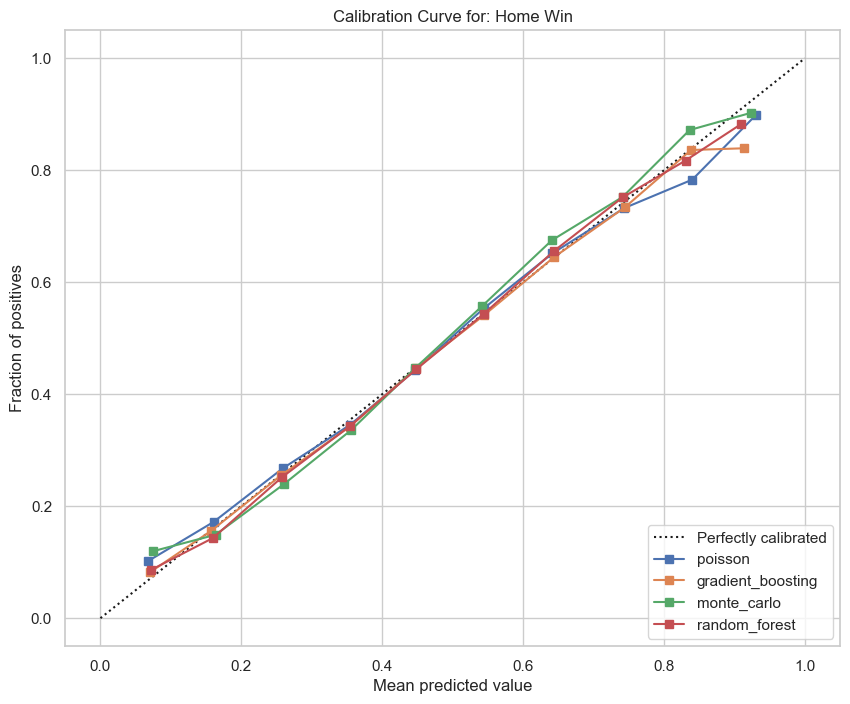

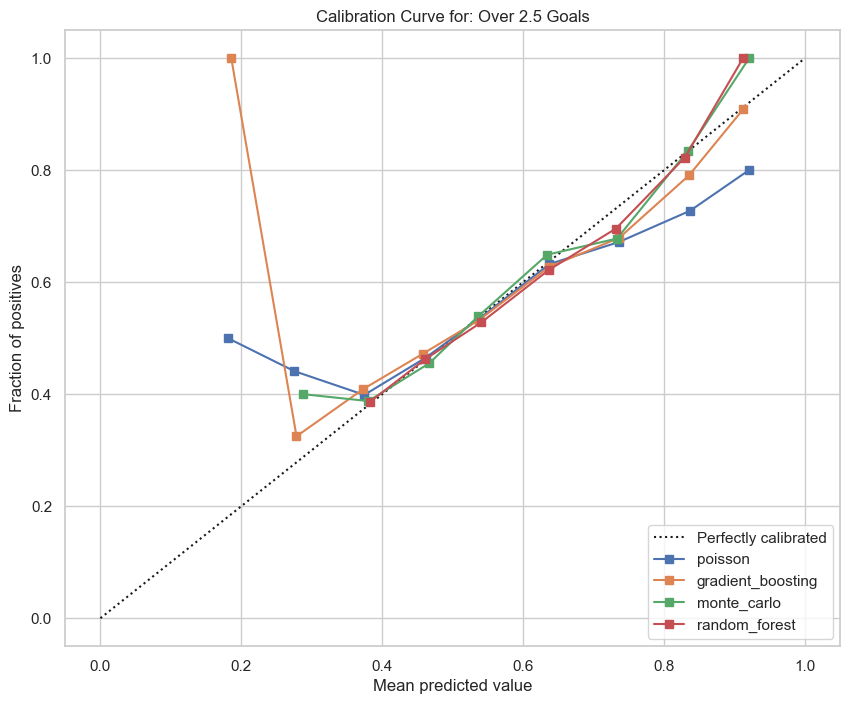

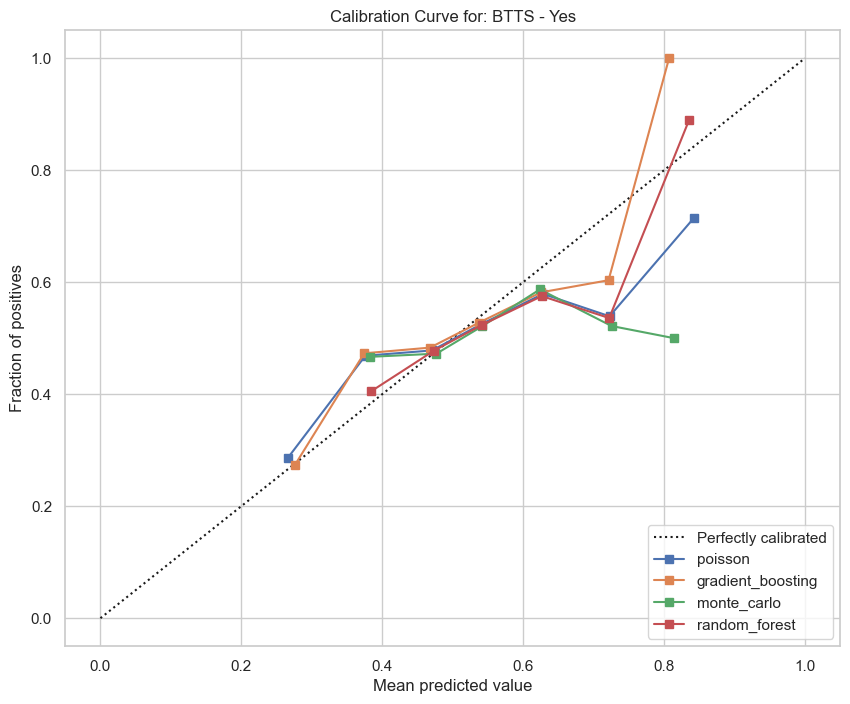

Individual Model Performance Evaluation section complete.


In [4]:
# --- 3. Individual Model Performance Evaluation ---
# ==============================================================================
print("\n--- 3. Individual Model Performance Evaluation ---")
print("Purpose: Quantify standalone predictive accuracy and calibration of each model.")

def calculate_probabilistic_metrics(
    y_true: pd.Series,
    y_prob: pd.Series,
    model_name: str,
    market_name: str
) -> Optional[Dict[str, Any]]:
    """Calculates Log-Loss, Brier Score, ROC AUC, and Accuracy."""
    combined = pd.DataFrame({'true': y_true, 'prob': y_prob}).dropna()
    if combined.empty:
        warnings.warn(f"No valid (non-NaN) predictions for {model_name} - {market_name}. Skipping metrics.", RuntimeWarning)
        return None
    if len(combined['true'].unique()) < 2:
         warnings.warn(f"Target for {model_name} - {market_name} has only one class after NaN drop ({len(combined['true'])} samples). ROC AUC/LogLoss may fail. Skipping metrics.", RuntimeWarning)
         return None

    y_true_clean = combined['true']
    y_prob_clean = combined['prob']
    epsilon = 1e-15
    y_prob_clipped = np.clip(y_prob_clean, epsilon, 1 - epsilon)

    try:
        metrics = {
            'Model': model_name,
            'Market': market_name,
            'NumSamples': len(y_true_clean)
        }
        metrics['LogLoss'] = log_loss(y_true_clean, y_prob_clipped)
        metrics['BrierScore'] = brier_score_loss(y_true_clean, y_prob_clean) # Brier does not strictly need clipping
        metrics['ROC_AUC'] = roc_auc_score(y_true_clean, y_prob_clean)
        y_pred_binary = (y_prob_clean > 0.5).astype(int)
        metrics['Accuracy_at_0.5'] = accuracy_score(y_true_clean, y_pred_binary)
        return metrics
    except ValueError as e:
        warnings.warn(f"Could not compute metrics for {model_name} - {market_name} (Samples: {len(y_true_clean)}, Unique True: {y_true_clean.unique()}): {e}", RuntimeWarning)
        return None

all_model_metrics: List[Dict[str, Any]] = []
print("\nEvaluating probabilistic predictions...")
for model_name in model_keys:
    print(f"  Processing model: {model_name}")
    for prob_key_full in CORE_PROBABILITY_KEYS:
        market_suffix = prob_key_full.replace('prob_', '')
        pred_col_name = f"{model_name}_{prob_key_full}"
        actual_col_name = f"Actual_{market_suffix}"

        assert pred_col_name in df_oof.columns, f"Pred col {pred_col_name} missing."
        assert actual_col_name in df_oof.columns, f"Actual col {actual_col_name} missing."

        metrics_results = calculate_probabilistic_metrics(
            y_true=df_oof[actual_col_name],
            y_prob=df_oof[pred_col_name],
            model_name=model_name,
            market_name=market_suffix
        )
        if metrics_results:
            all_model_metrics.append(metrics_results)

df_metrics = pd.DataFrame(all_model_metrics)
if not df_metrics.empty:
    print("Probabilistic metrics calculation complete.")
    print(f"Probabilistic Metrics Summary (first 5 rows):\n{df_metrics.head()}")
else:
    print("WARNING: No probabilistic metrics were calculated.")


expected_goals_metrics_list: List[Dict[str, Any]] = []
print("\nEvaluating expected goals predictions (MAE, RMSE)...")
for model_name in model_keys:
    print(f"  Processing model for expected goals: {model_name}")
    for exp_goal_key_suffix in EXPECTED_GOALS_KEYS: # 'expected_HG', 'expected_AG'
        pred_col_name = f"{model_name}_{exp_goal_key_suffix}"
        actual_col_name = 'FTHG' if exp_goal_key_suffix == 'expected_HG' else 'FTAG'

        assert pred_col_name in df_oof.columns, f"Pred col {pred_col_name} missing."
        assert actual_col_name in df_oof.columns, f"Actual col {actual_col_name} missing."

        combined_exp = pd.DataFrame({
            'true': df_oof[actual_col_name],
            'pred': df_oof[pred_col_name]
        }).dropna()

        if combined_exp.empty:
            warnings.warn(f"No valid (non-NaN) exp. goal predictions for {pred_col_name}. Skipping MAE/RMSE.", RuntimeWarning)
            continue
            
        y_true_exp = combined_exp['true'].astype(float)
        y_pred_exp = combined_exp['pred'].astype(float)

        expected_goals_metrics_list.append({
            'Model': model_name,
            'Market': exp_goal_key_suffix,
            'MAE': mean_absolute_error(y_true_exp, y_pred_exp),
            'RMSE': mean_squared_error(y_true_exp, y_pred_exp, squared=False),
            'NumSamples': len(y_true_exp)
        })

df_exp_goals_metrics = pd.DataFrame(expected_goals_metrics_list)
if not df_exp_goals_metrics.empty:
    print("Expected goals metrics calculation complete.")
    print(f"Expected Goals Metrics Summary (first 5 rows):\n{df_exp_goals_metrics.head()}")
else:
    print("WARNING: No expected goals metrics were calculated.")


def display_top_performers(df_metrics_summary: pd.DataFrame, metric_col: str, markets_list: List[str], ascending_order: bool = True):
    print(f"\n--- Top Performers by {metric_col} (Lower is better if ascending_order={ascending_order}) ---")
    for market_item in markets_list:
        market_data = df_metrics_summary[df_metrics_summary['Market'] == market_item].sort_values(by=metric_col, ascending=ascending_order)
        print(f"\nMarket: {market_item}")
        if not market_data.empty:
            print(market_data[['Model', metric_col, 'NumSamples']].to_string(index=False))
        else:
            print("  No data for this market in summary.")

key_display_markets_prob = ['H', 'A', 'O25', 'U25', 'BTTS_Y', 'BTTS_N']
if not df_metrics.empty:
    display_top_performers(df_metrics, 'LogLoss', key_display_markets_prob, ascending_order=True)
    display_top_performers(df_metrics, 'BrierScore', key_display_markets_prob, ascending_order=True)
    display_top_performers(df_metrics, 'ROC_AUC', key_display_markets_prob, ascending_order=False) # Higher is better

if not df_exp_goals_metrics.empty:
    display_top_performers(df_exp_goals_metrics, 'MAE', EXPECTED_GOALS_KEYS, ascending_order=True)


print("\n--- Calibration Analysis (Selected Markets) ---")
def plot_calibration_curve_for_market(
    df_data: pd.DataFrame,
    actual_col_name_calib: str,
    models_to_plot_calib: List[str],
    prob_key_market_suffix: str, # e.g., 'H', 'O25'. 'prob_' will be prepended.
    market_display_name_calib: str,
    n_bins_calib: int = 10
):
    plt.figure(figsize=(10, 8))
    plt.plot([0, 1], [0, 1], "k:", label="Perfectly calibrated")
    
    full_prob_key_prefix = "prob_" # The actual prefix in column names

    for model_name_calib in models_to_plot_calib:
        pred_col_calib = f"{model_name_calib}_{full_prob_key_prefix}{prob_key_market_suffix}"
        if pred_col_calib not in df_data.columns:
            warnings.warn(f"Pred col {pred_col_calib} not found for calibration. Skipping.", RuntimeWarning)
            continue

        temp_df = df_data[[actual_col_name_calib, pred_col_calib]].copy().dropna()
        if temp_df.empty or len(temp_df[actual_col_name_calib].unique()) < 2:
            warnings.warn(f"Not enough data or only one class for {pred_col_calib} in {market_display_name_calib} after NaN drop. Skipping calibration.", RuntimeWarning)
            continue

        y_true_calib = temp_df[actual_col_name_calib]
        y_prob_calib = temp_df[pred_col_calib]

        fraction_of_positives, mean_predicted_value = calibration_curve(y_true_calib, y_prob_calib, n_bins=n_bins_calib, strategy='uniform')
        plt.plot(mean_predicted_value, fraction_of_positives, "s-", label=f"{model_name_calib}")

    plt.ylabel("Fraction of positives")
    plt.xlabel("Mean predicted value")
    plt.ylim([-0.05, 1.05])
    plt.legend(loc="lower right")
    plt.title(f"Calibration Curve for: {market_display_name_calib}")
    plt.grid(True)
    plt.show()

calibration_markets_map = {
    'H': 'Home Win',
    'O25': 'Over 2.5 Goals',
    'BTTS_Y': 'BTTS - Yes'
} # Market suffix : Display Name

for market_suffix_calib, display_name_calib in calibration_markets_map.items():
    actual_target_col_calib = f"Actual_{market_suffix_calib}"
    if actual_target_col_calib in df_oof.columns:
        plot_calibration_curve_for_market(
            df_data=df_oof,
            actual_col_name_calib=actual_target_col_calib,
            models_to_plot_calib=model_keys,
            prob_key_market_suffix=market_suffix_calib, # This is just 'H', 'O25', etc.
            market_display_name_calib=display_name_calib
        )
    else:
        warnings.warn(f"Actual col {actual_target_col_calib} not found for calibration. Skipping {display_name_calib}", RuntimeWarning)

print("Individual Model Performance Evaluation section complete.")


--- 4. Prediction Distribution Analysis ---
Purpose: Understand the characteristics of probability distributions from each model.

Analyzing distributions for market: Home Win Probability (prob_H)
  poisson: Mean=0.441, Std=0.135, Min=0.003, Max=0.989, Count=110373
  gradient_boosting: Mean=0.445, Std=0.148, Min=0.005, Max=0.959, Count=110373
  monte_carlo: Mean=0.442, Std=0.118, Min=0.010, Max=0.976, Count=110373
  random_forest: Mean=0.444, Std=0.139, Min=0.018, Max=0.924, Count=110373


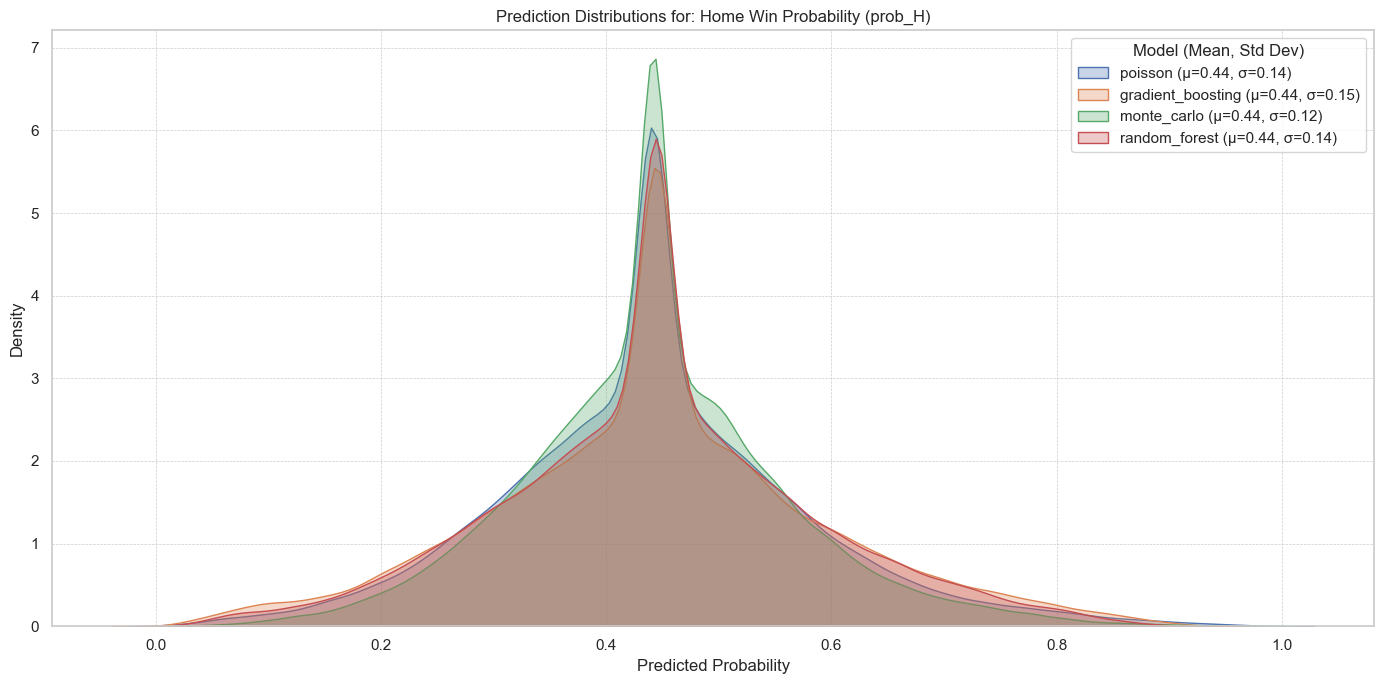


Analyzing distributions for market: Over 2.5 Goals Probability (prob_O25)
  poisson: Mean=0.520, Std=0.074, Min=0.164, Max=0.955, Count=110373
  gradient_boosting: Mean=0.517, Std=0.079, Min=0.186, Max=0.925, Count=110373
  monte_carlo: Mean=0.521, Std=0.060, Min=0.263, Max=0.944, Count=110373
  random_forest: Mean=0.527, Std=0.071, Min=0.302, Max=0.913, Count=110373


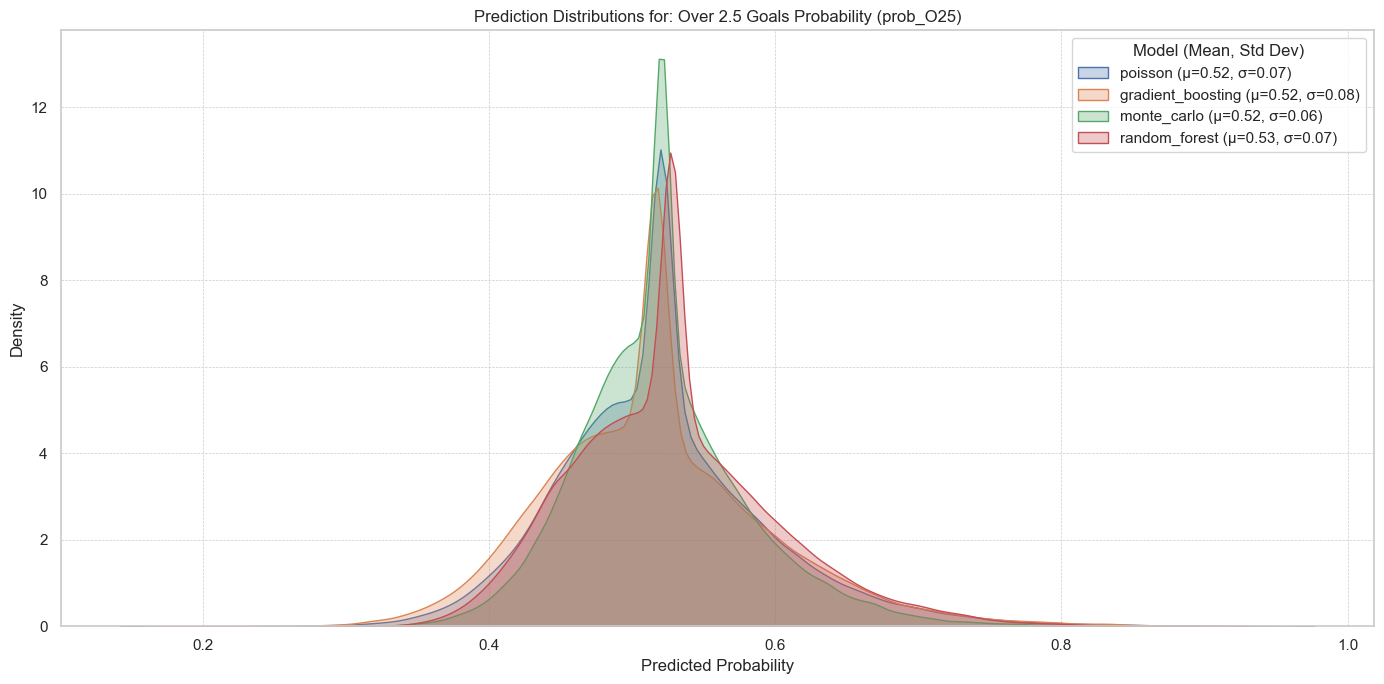


Analyzing distributions for market: BTTS - Yes Probability (prob_BTTS_Y)
  poisson: Mean=0.529, Std=0.050, Min=0.205, Max=0.886, Count=110373
  gradient_boosting: Mean=0.520, Std=0.052, Min=0.218, Max=0.807, Count=110373
  monte_carlo: Mean=0.536, Std=0.041, Min=0.322, Max=0.818, Count=110373
  random_forest: Mean=0.532, Std=0.048, Min=0.321, Max=0.877, Count=110373


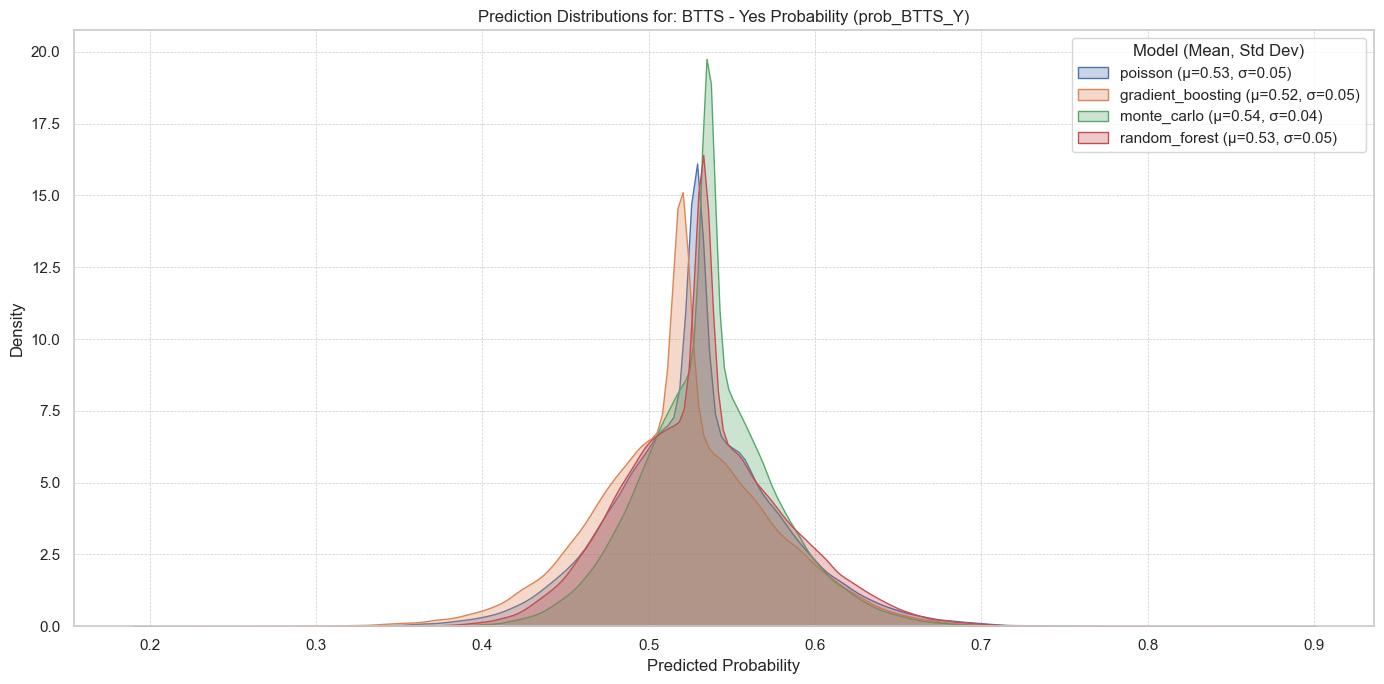


Analyzing distributions for market: Away Win Probability (prob_A)
  poisson: Mean=0.319, Std=0.125, Min=0.002, Max=0.990, Count=110373
  gradient_boosting: Mean=0.318, Std=0.139, Min=0.011, Max=0.982, Count=110373
  monte_carlo: Mean=0.315, Std=0.108, Min=0.006, Max=0.957, Count=110373
  random_forest: Mean=0.318, Std=0.130, Min=0.022, Max=0.938, Count=110373


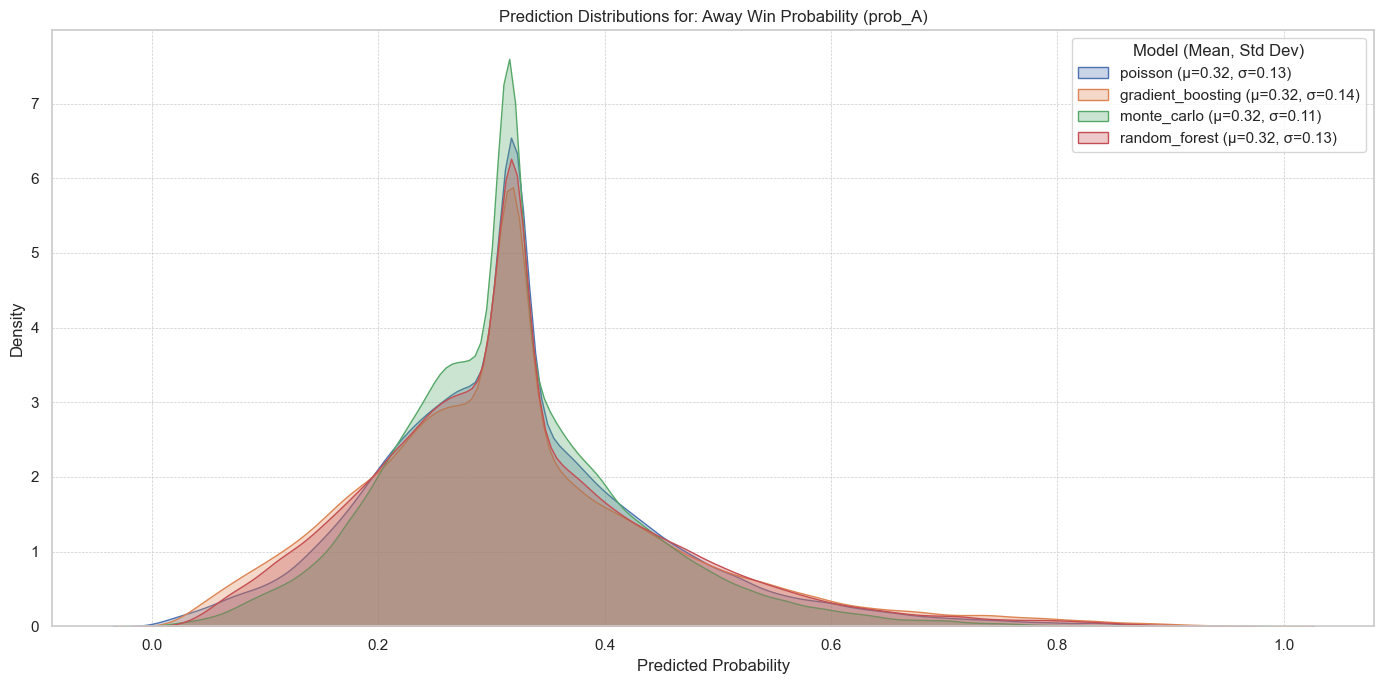


--- Key Observations for Prediction Distribution Analysis (Guide) ---

- Range: Do models use the full probability range (0-1)?
- Central Tendency: Where do predictions cluster?
- Spread (Variance/Std Dev): How confident/variable are the models?
- Shape: Unimodal, bimodal, skewed? Outliers?
- Comparison: Similar shapes suggest redundancy; different shapes suggest complementarity.

Prediction Distribution Analysis section complete.


=== OOF Analysis Script Sections 0-4 Run Complete ===


In [5]:
# --- 4. Prediction Distribution Analysis ---
# ==============================================================================
print("\n--- 4. Prediction Distribution Analysis ---")
print("Purpose: Understand the characteristics of probability distributions from each model.")

distribution_analysis_markets_map: Dict[str, str] = { # market_suffix : display_name
    'H': 'Home Win Probability (prob_H)',
    'O25': 'Over 2.5 Goals Probability (prob_O25)',
    'BTTS_Y': 'BTTS - Yes Probability (prob_BTTS_Y)',
    'A': 'Away Win Probability (prob_A)'
}

def plot_prediction_distributions(
    df_dist: pd.DataFrame,
    models_dist: List[str],
    market_suffix_dist: str, # e.g., 'H', 'O25'. 'prob_' will be prepended.
    market_display_name_dist: str,
    bins_dist: int = 50,
    use_kde_dist: bool = True
):
    plt.figure(figsize=(14, 7))
    full_prob_key_prefix_dist = "prob_" # The actual prefix
    
    print(f"\nAnalyzing distributions for market: {market_display_name_dist}")
    plot_data_exists_dist = False
    for model_name_dist in models_dist:
        pred_col_dist = f"{model_name_dist}_{full_prob_key_prefix_dist}{market_suffix_dist}"
        
        if pred_col_dist not in df_dist.columns:
            warnings.warn(f"Pred col {pred_col_dist} not found for distribution. Skipping.", RuntimeWarning)
            continue

        predictions_dist = df_dist[pred_col_dist].dropna()
        if predictions_dist.empty:
            warnings.warn(f"No valid (non-NaN) predictions for {pred_col_dist}. Skipping.", RuntimeWarning)
            continue
        
        plot_data_exists_dist = True
        label_dist = f"{model_name_dist} (μ={predictions_dist.mean():.2f}, σ={predictions_dist.std():.2f})"
        if use_kde_dist:
            sns.kdeplot(predictions_dist, label=label_dist, fill=True, alpha=0.3)
        else:
            plt.hist(predictions_dist, bins=bins_dist, alpha=0.6, label=label_dist, density=True)
        
        print(f"  {model_name_dist}: Mean={predictions_dist.mean():.3f}, Std={predictions_dist.std():.3f}, Min={predictions_dist.min():.3f}, Max={predictions_dist.max():.3f}, Count={len(predictions_dist)}")

    if not plot_data_exists_dist:
        print(f"No data to plot for market: {market_display_name_dist}")
        plt.close()
        return

    plt.title(f"Prediction Distributions for: {market_display_name_dist}")
    plt.xlabel("Predicted Probability")
    plt.ylabel("Density" if use_kde_dist else "Frequency (Normalized)")
    plt.legend(title="Model (Mean, Std Dev)")
    plt.grid(True, which='both', linestyle='--', linewidth=0.5)
    plt.tight_layout()
    plt.show()

for market_suffix_dist_plot, display_name_dist_plot in distribution_analysis_markets_map.items():
    example_pred_col_check = f"{model_keys[0]}_prob_{market_suffix_dist_plot}" # check one example
    if example_pred_col_check not in df_oof.columns:
        warnings.warn(f"Market suffix '{market_suffix_dist_plot}' (e.g., {example_pred_col_check}) seems missing. Skipping distribution plot.", RuntimeWarning)
        continue
        
    plot_prediction_distributions(
        df_dist=df_oof,
        models_dist=model_keys,
        market_suffix_dist=market_suffix_dist_plot, # This is 'H', 'O25', etc.
        market_display_name_dist=display_name_dist_plot,
        use_kde_dist=True
    )

print("\n--- Key Observations for Prediction Distribution Analysis (Guide) ---")
print("""
- Range: Do models use the full probability range (0-1)?
- Central Tendency: Where do predictions cluster?
- Spread (Variance/Std Dev): How confident/variable are the models?
- Shape: Unimodal, bimodal, skewed? Outliers?
- Comparison: Similar shapes suggest redundancy; different shapes suggest complementarity.
""")
print("Prediction Distribution Analysis section complete.")

print("\n\n==========================================")
print("=== OOF Analysis Script Sections 0-4 Run Complete ===")
print("==========================================")


--- 5. Inter-Model Prediction Correlation (ALL PROBABILITY MARKETS) ---
Purpose: Identify how similar or different the predictions from various models are FOR ALL PROBABILITY MARKETS.

Generating prediction correlation heatmaps for ALL probability markets...

--- Processing correlations for market: H ---


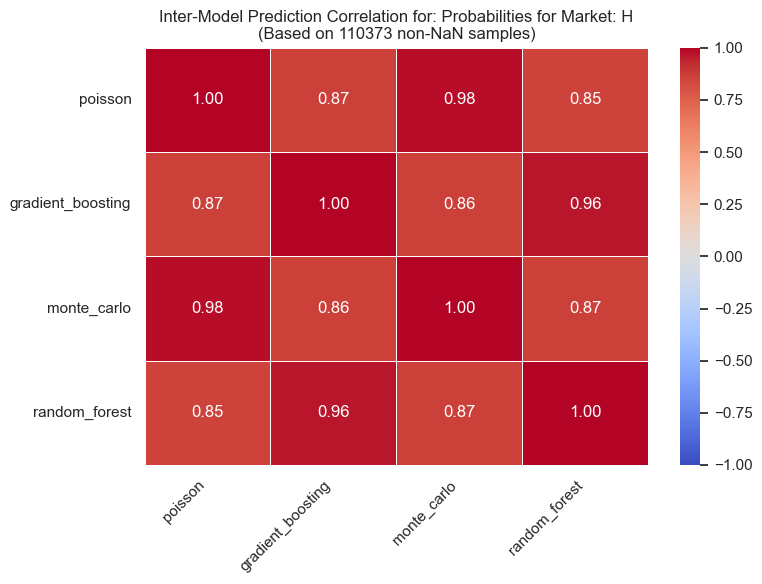


--- Processing correlations for market: D ---


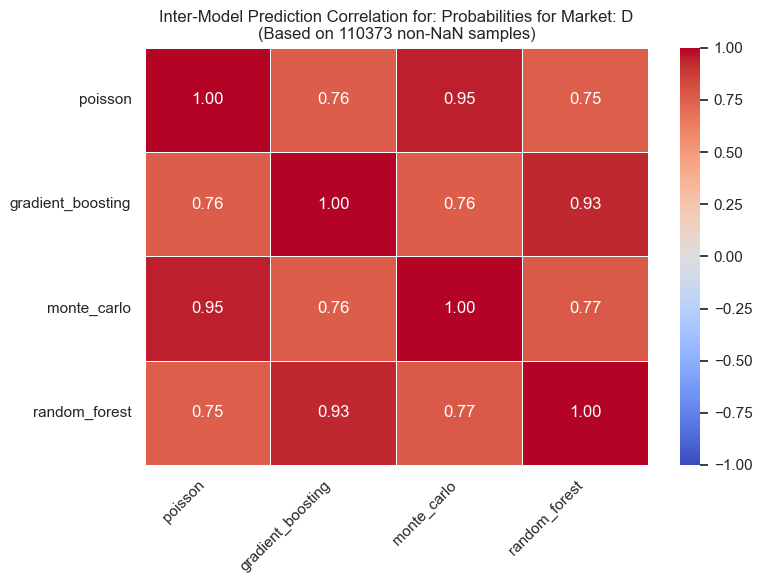


--- Processing correlations for market: A ---


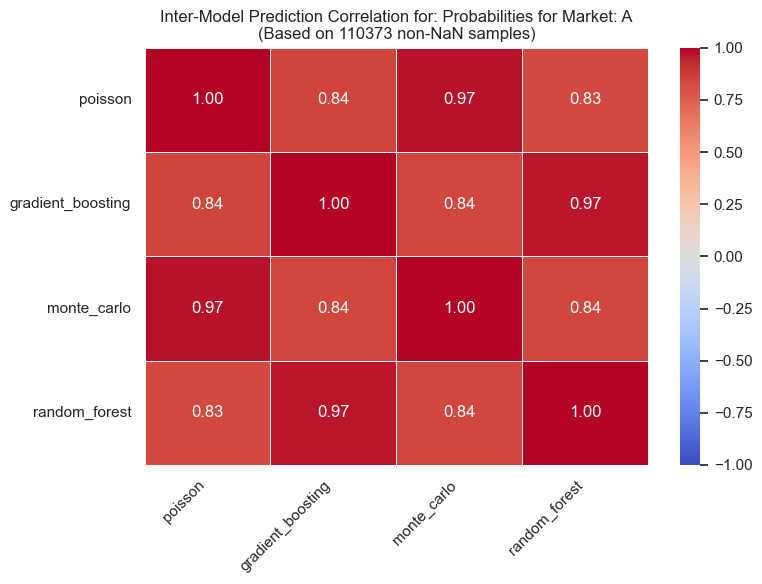


--- Processing correlations for market: O05 ---


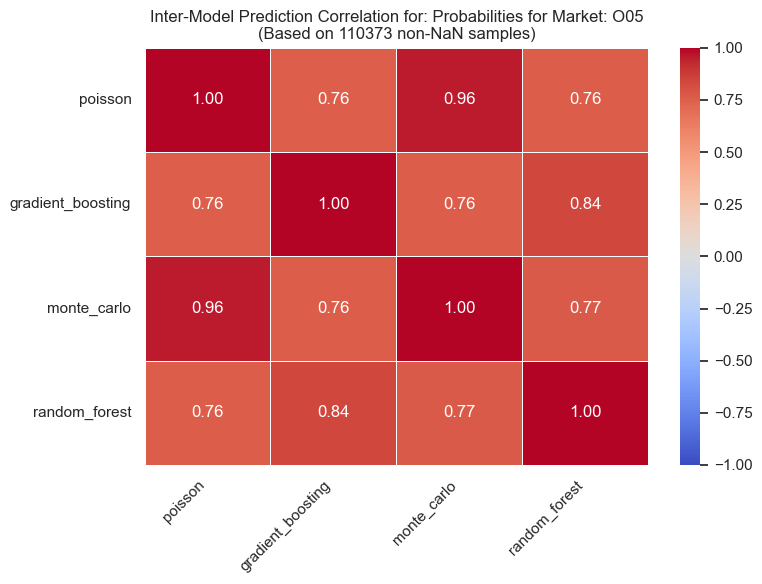


--- Processing correlations for market: U05 ---


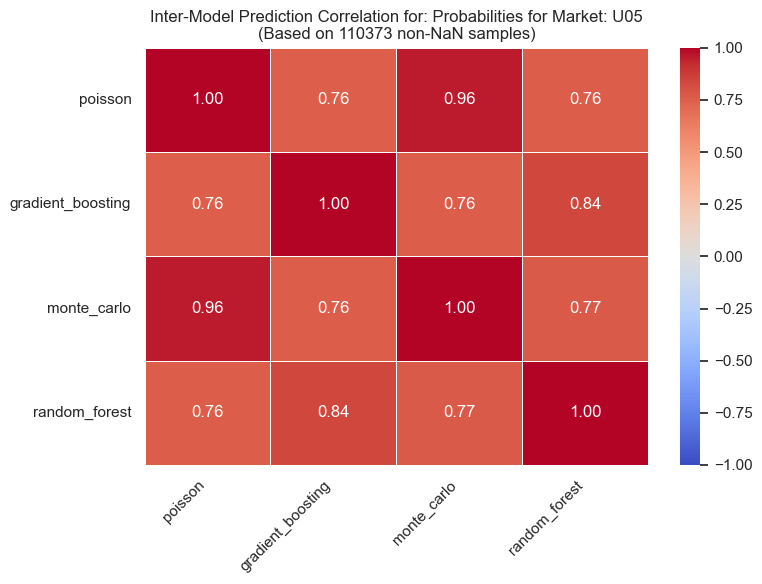


--- Processing correlations for market: O15 ---


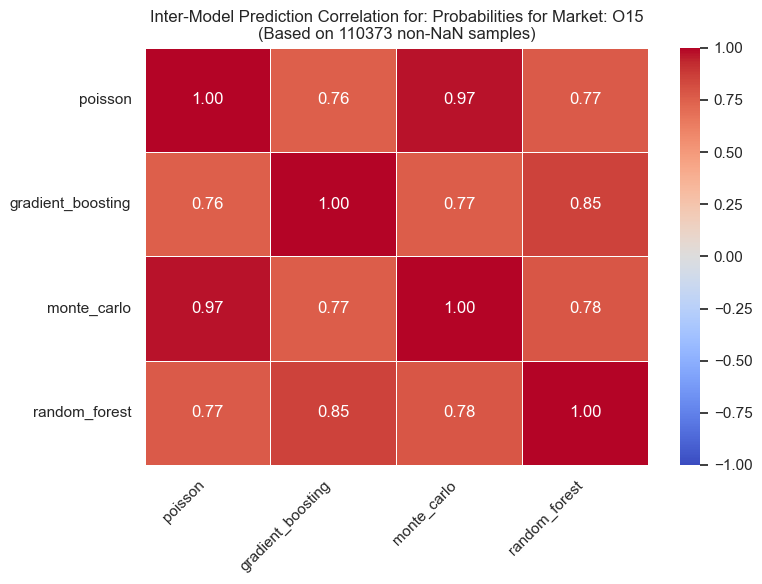


--- Processing correlations for market: U15 ---


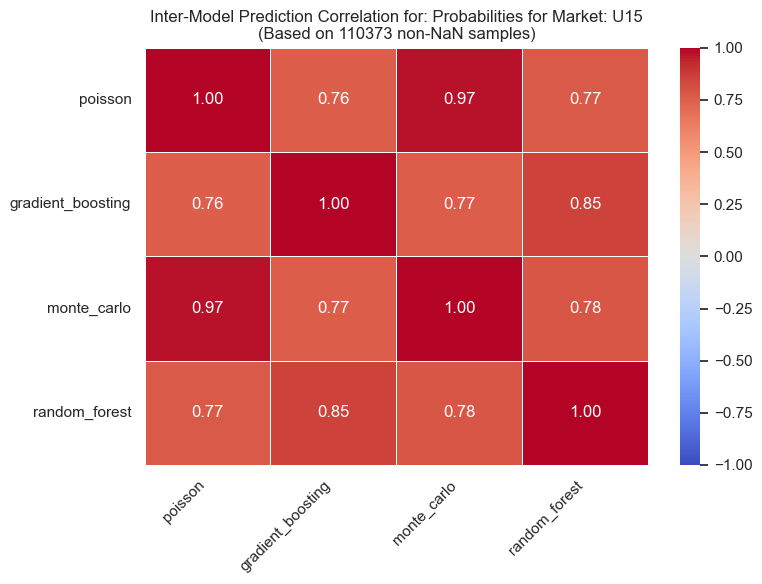


--- Processing correlations for market: O25 ---


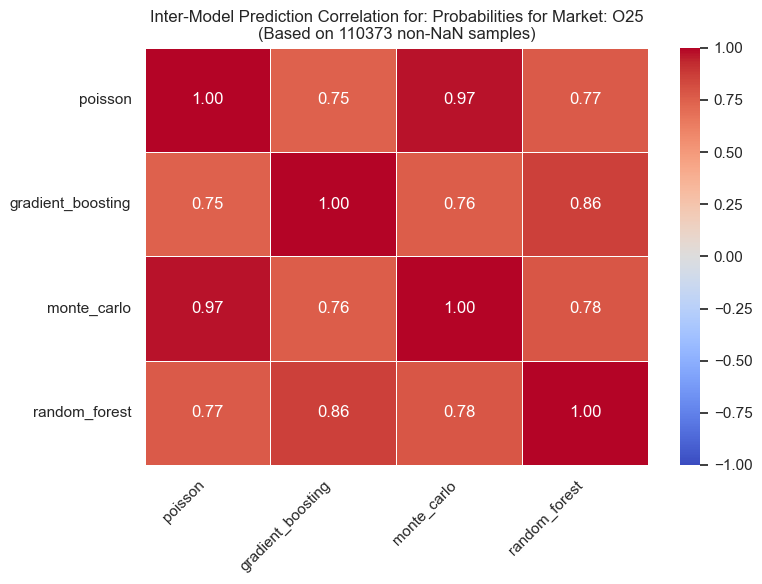


--- Processing correlations for market: U25 ---


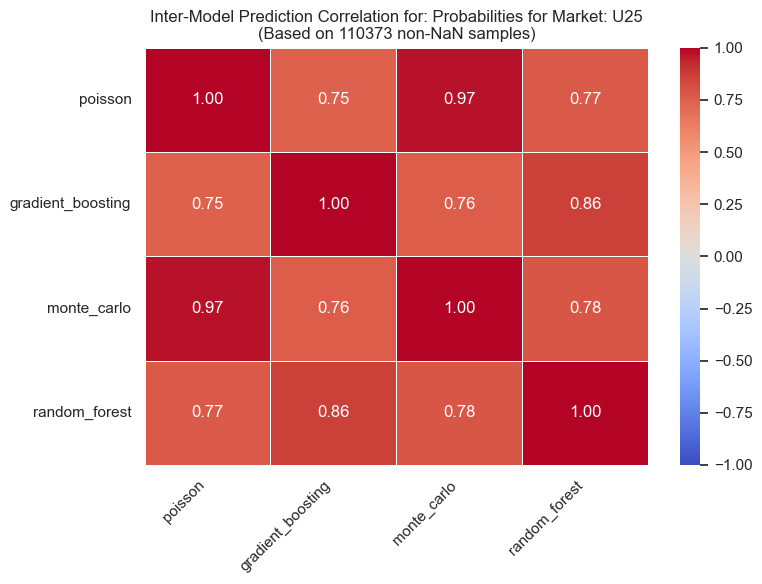


--- Processing correlations for market: O35 ---


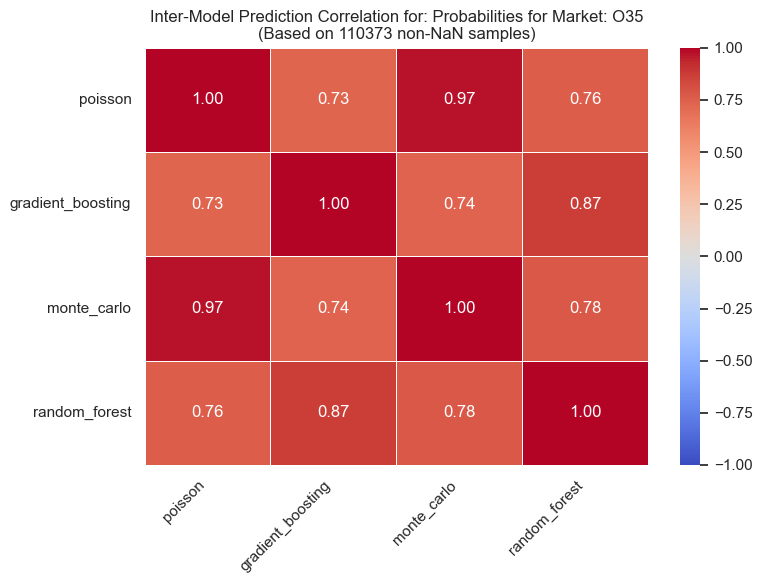


--- Processing correlations for market: U35 ---


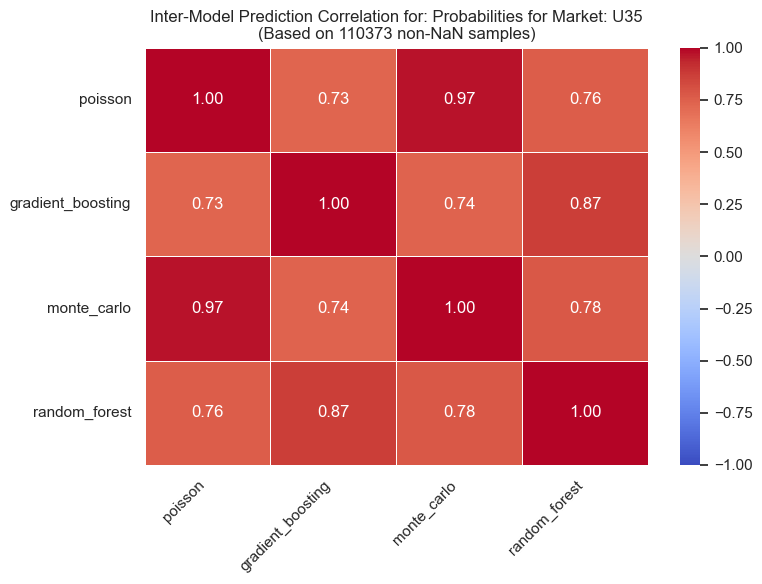


--- Processing correlations for market: O45 ---


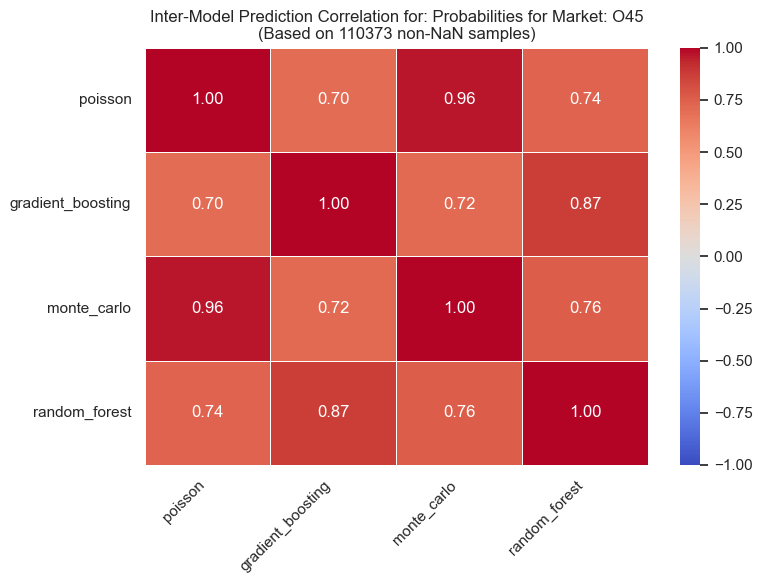


--- Processing correlations for market: U45 ---


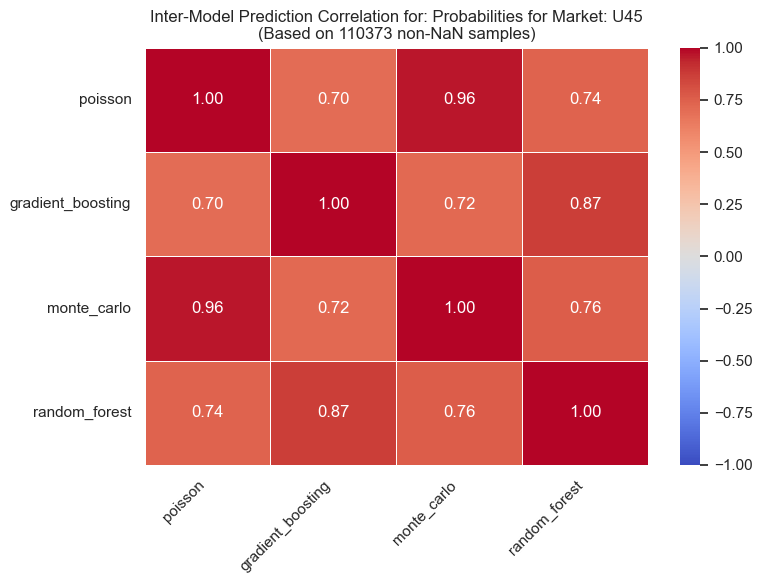


--- Processing correlations for market: BTTS_Y ---


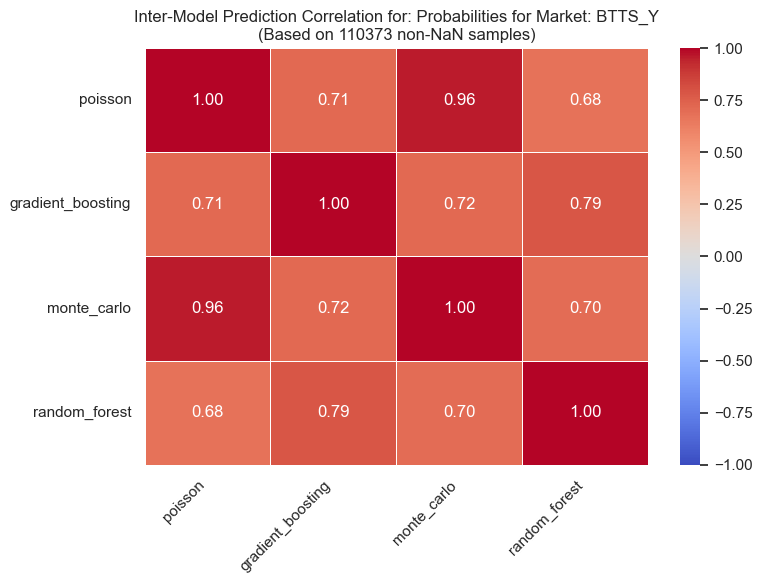


--- Processing correlations for market: BTTS_N ---


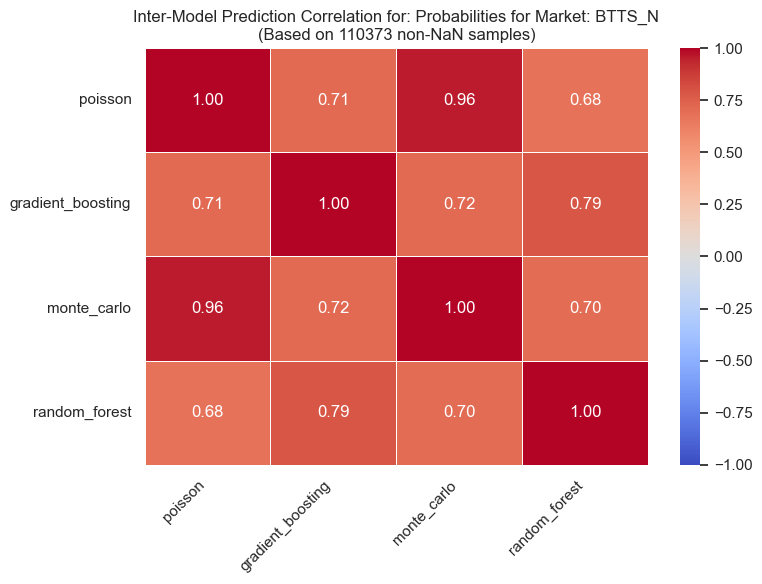


--- Processing correlations for market: 1X ---


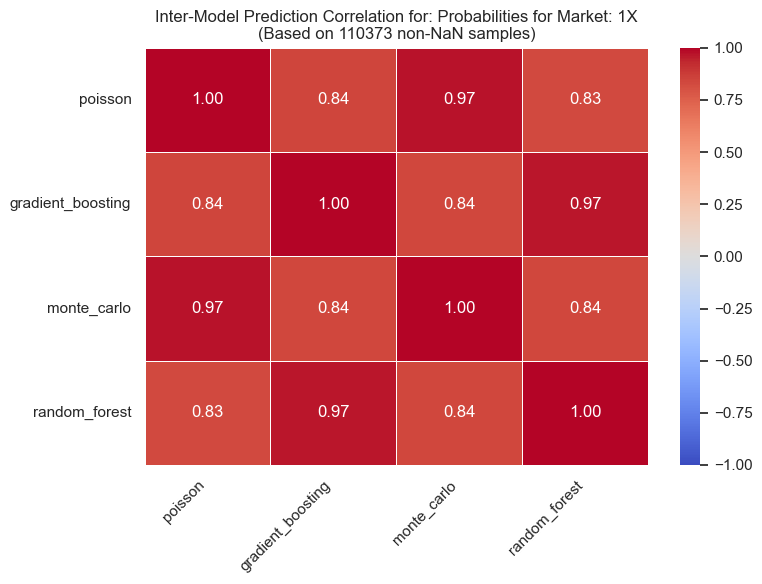


--- Processing correlations for market: 12 ---


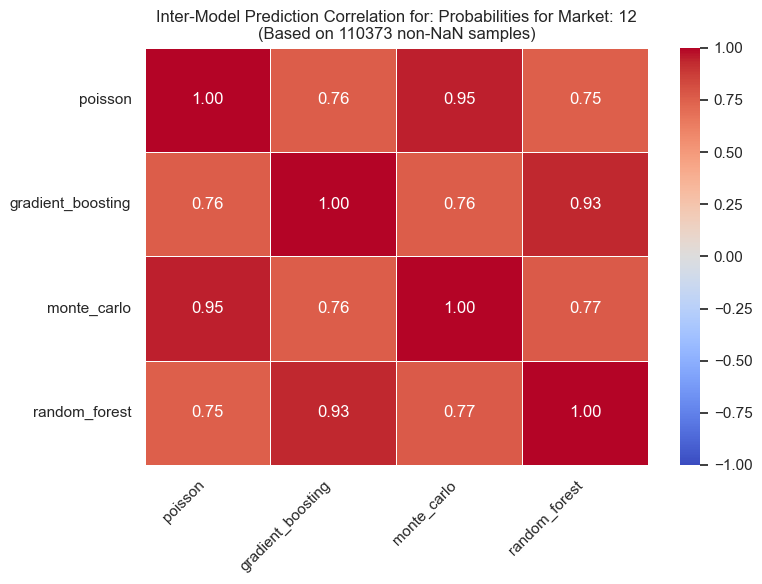


--- Processing correlations for market: X2 ---


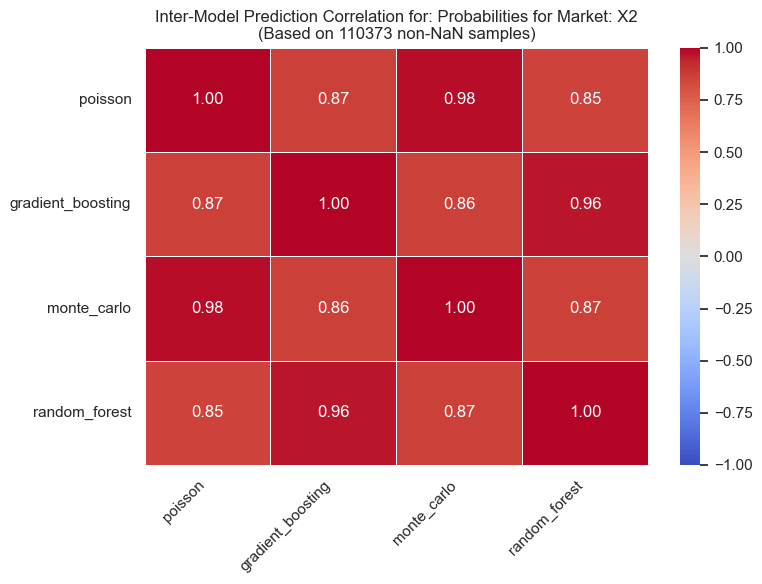


--- Processing correlations for market: GOALS_0_1 ---


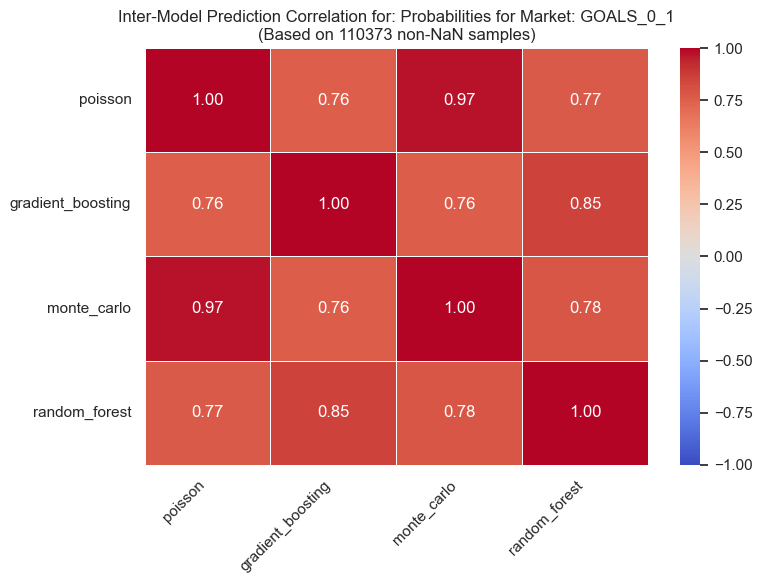


--- Processing correlations for market: GOALS_2_3 ---


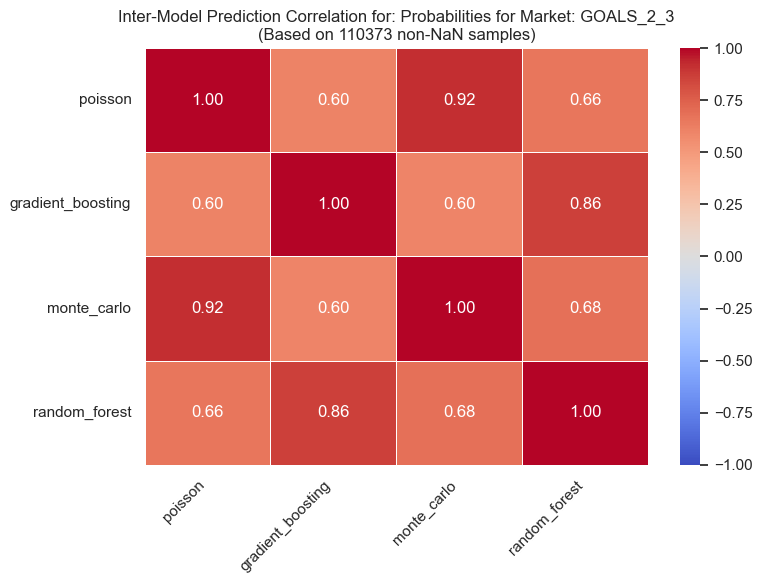


--- Processing correlations for market: GOALS_2_4 ---


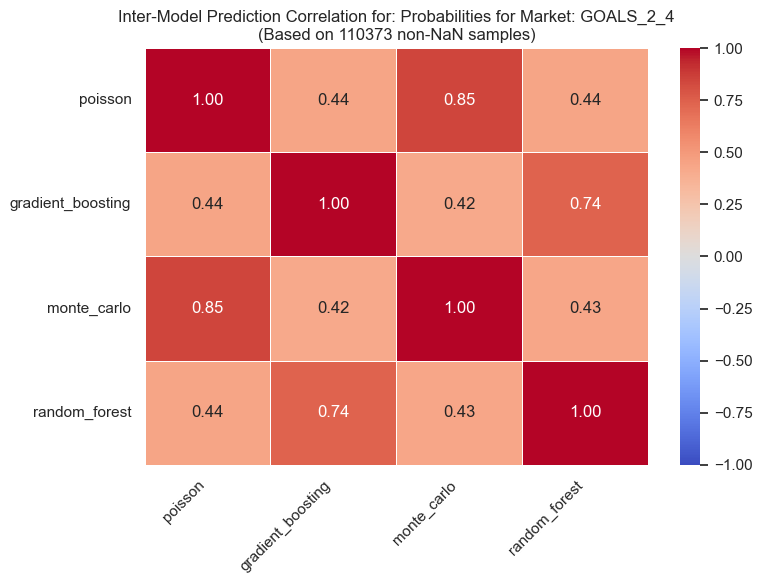


--- Processing correlations for market: GOALS_3_PLUS ---


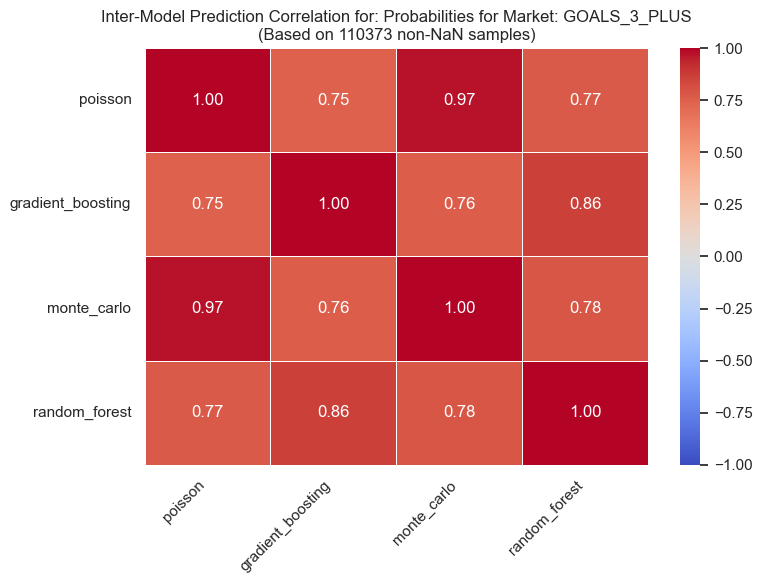


--- Processing correlations for market: H_AND_O25 ---


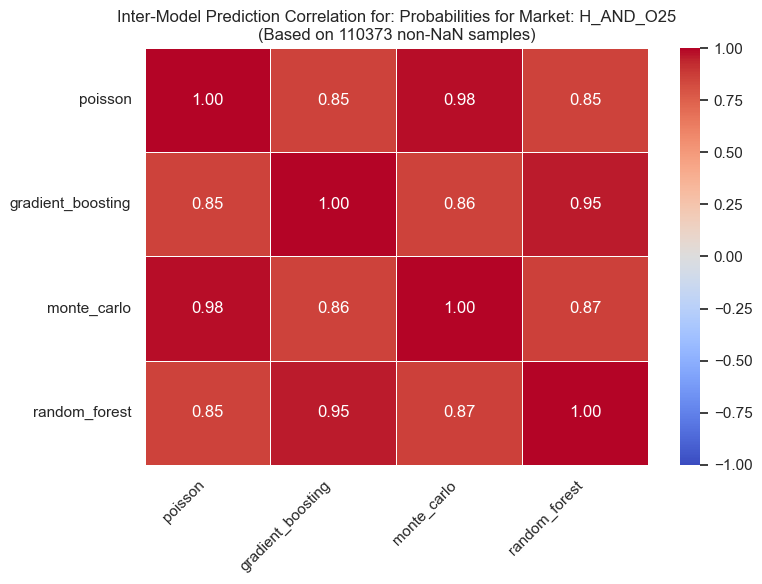


--- Processing correlations for market: D_AND_O25 ---


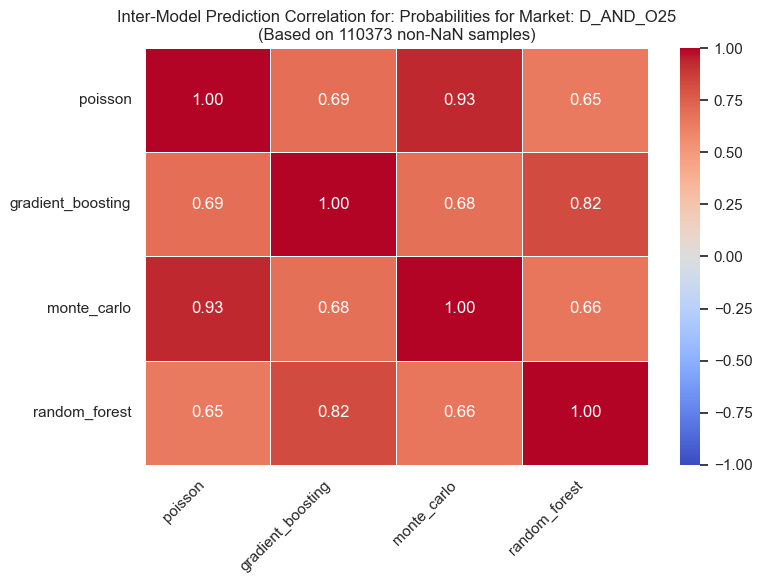


--- Processing correlations for market: A_AND_O25 ---


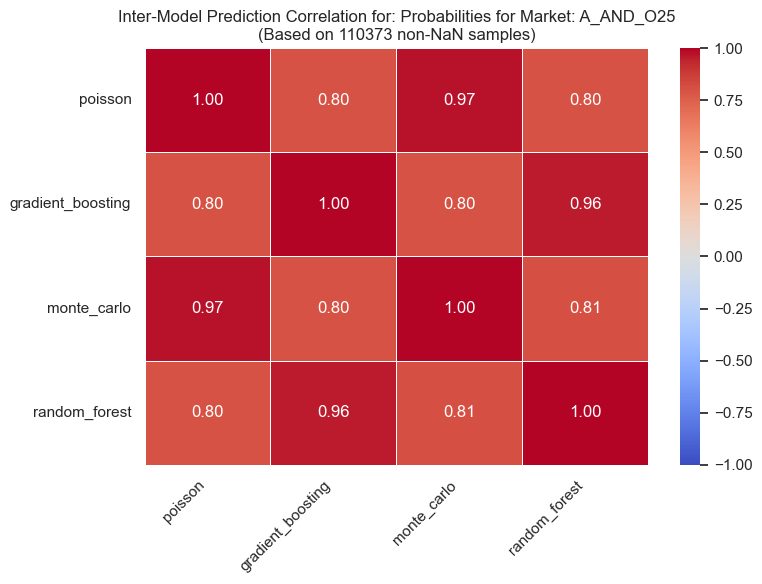


--- Processing correlations for market: H_AND_U25 ---


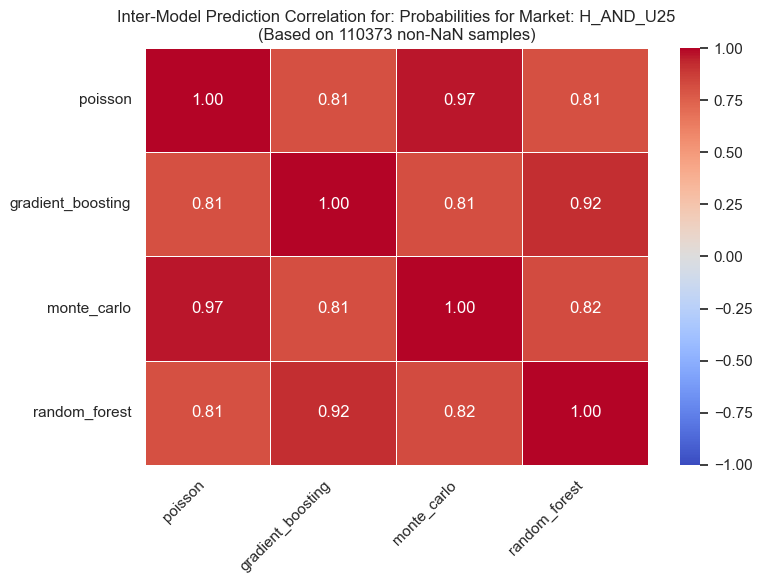


--- Processing correlations for market: D_AND_U25 ---


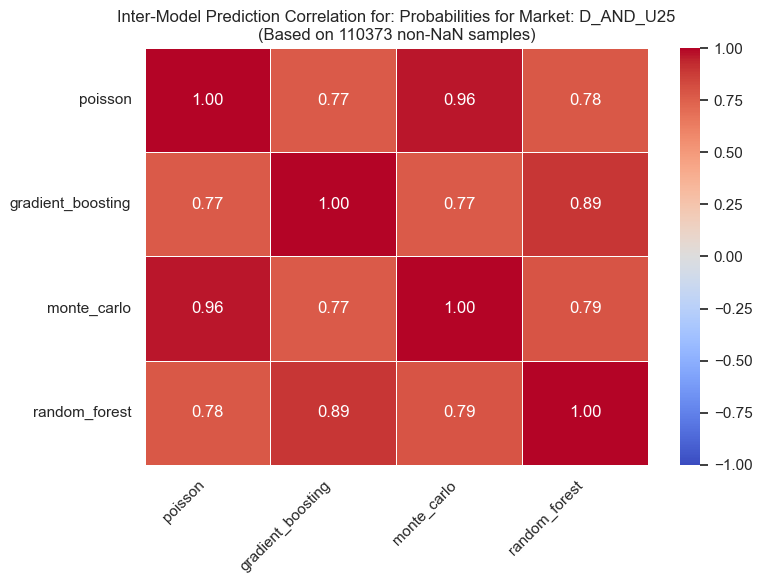


--- Processing correlations for market: A_AND_U25 ---


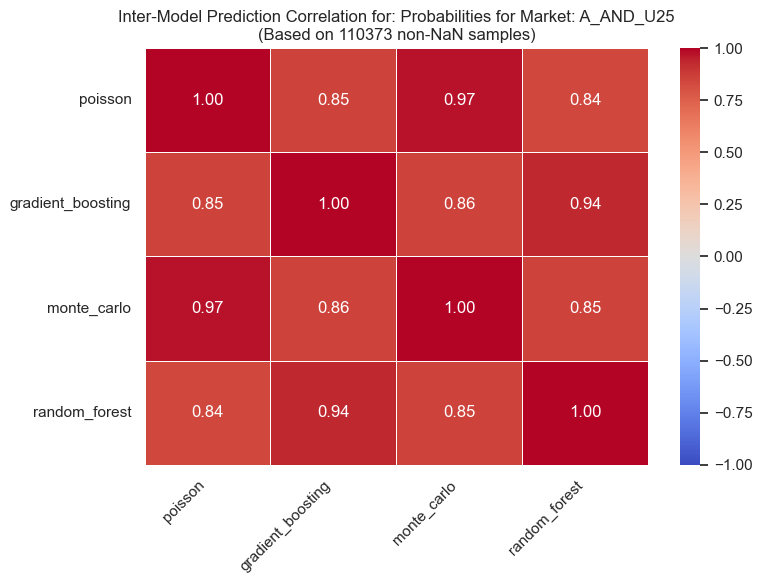


--- Processing correlations for market: 1X_AND_O25 ---


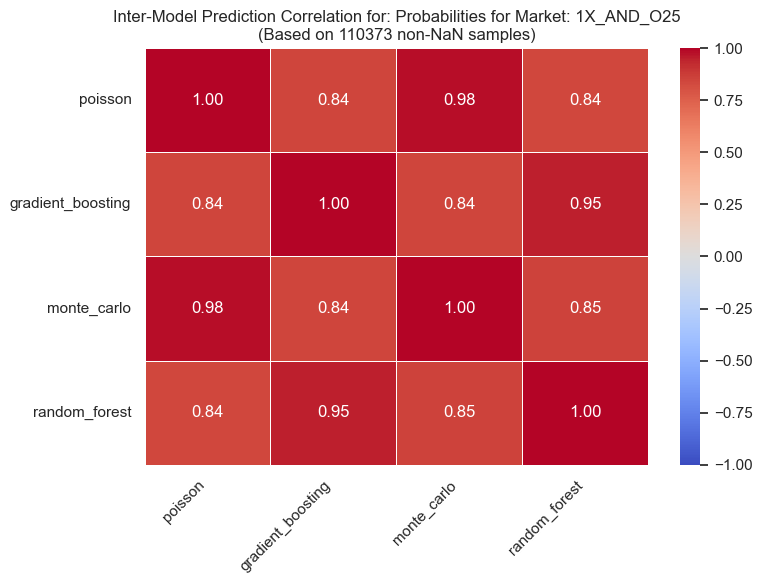


--- Processing correlations for market: 12_AND_O25 ---


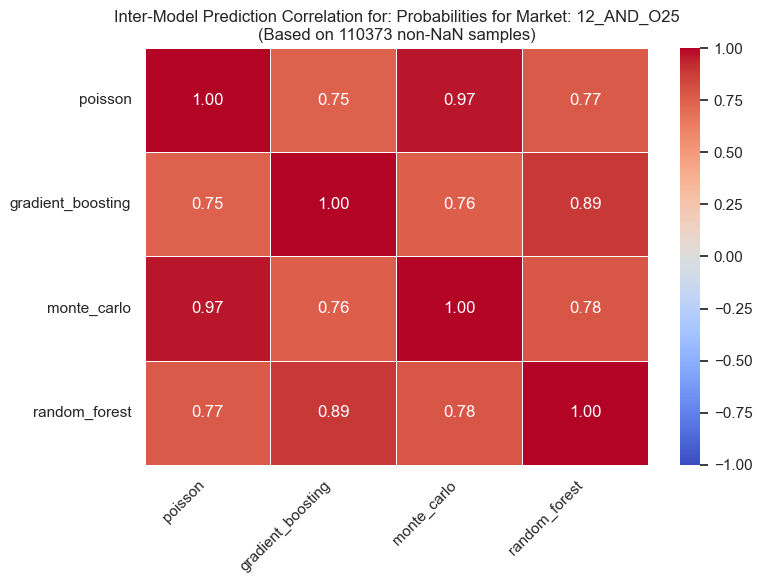


--- Processing correlations for market: X2_AND_O25 ---


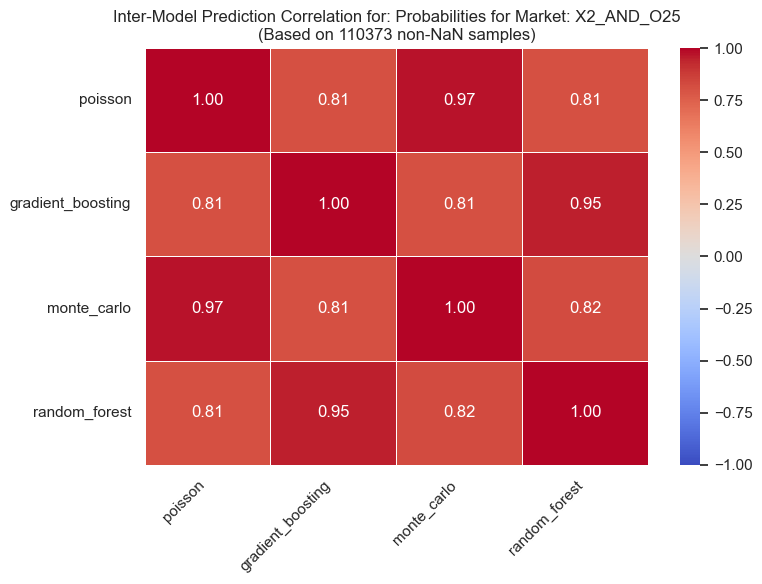


--- Processing correlations for market: 1X_AND_U25 ---


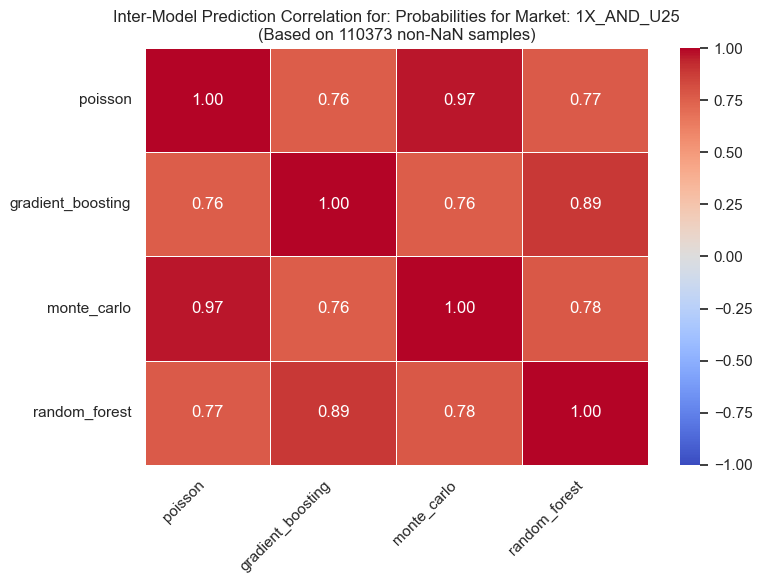


--- Processing correlations for market: 12_AND_U25 ---


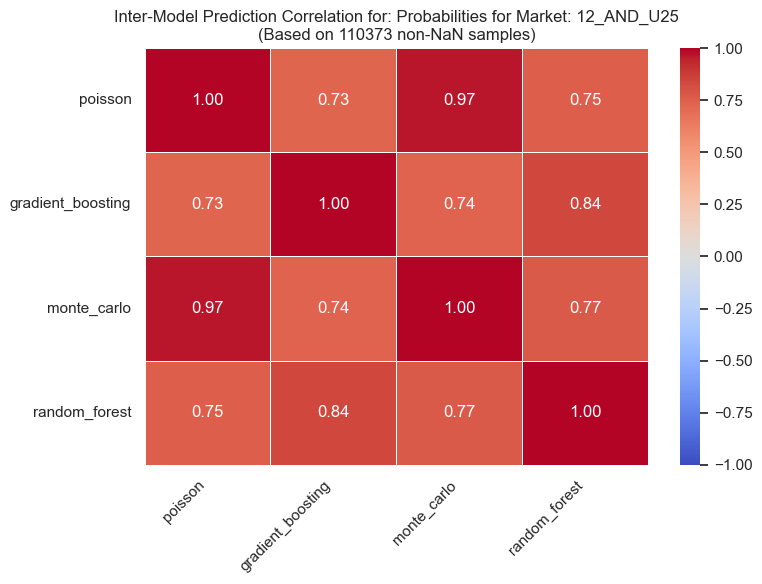


--- Processing correlations for market: X2_AND_U25 ---


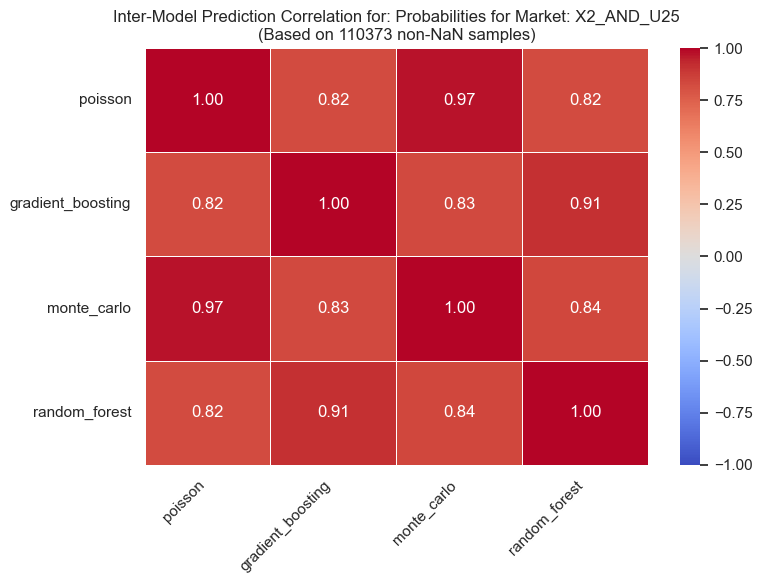


--- Processing correlations for market: H_AND_BTTS_Y ---


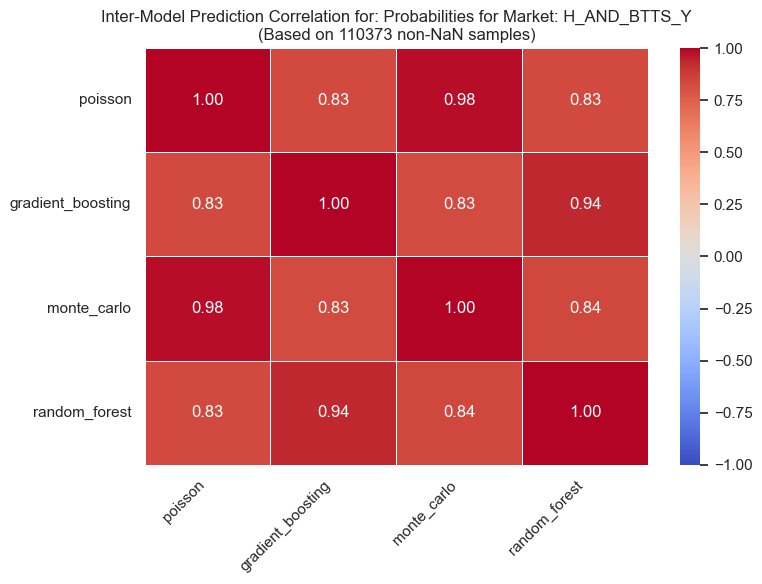


--- Processing correlations for market: D_AND_BTTS_Y ---


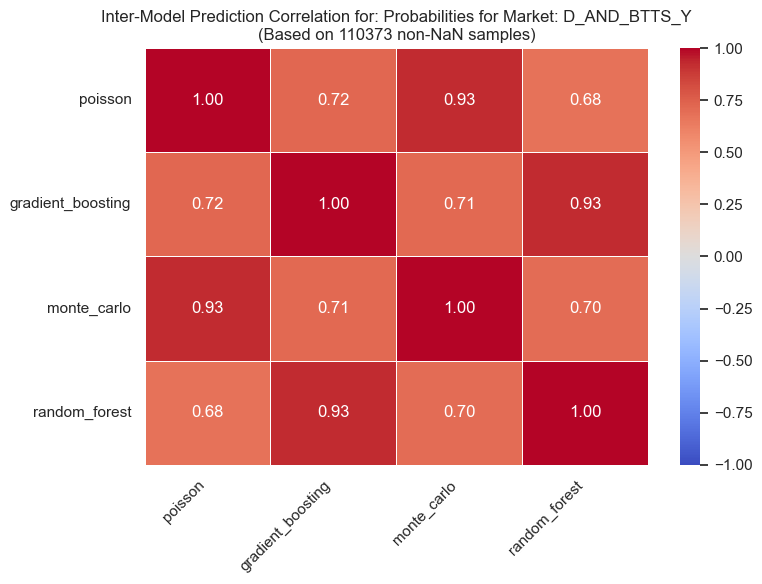


--- Processing correlations for market: A_AND_BTTS_Y ---


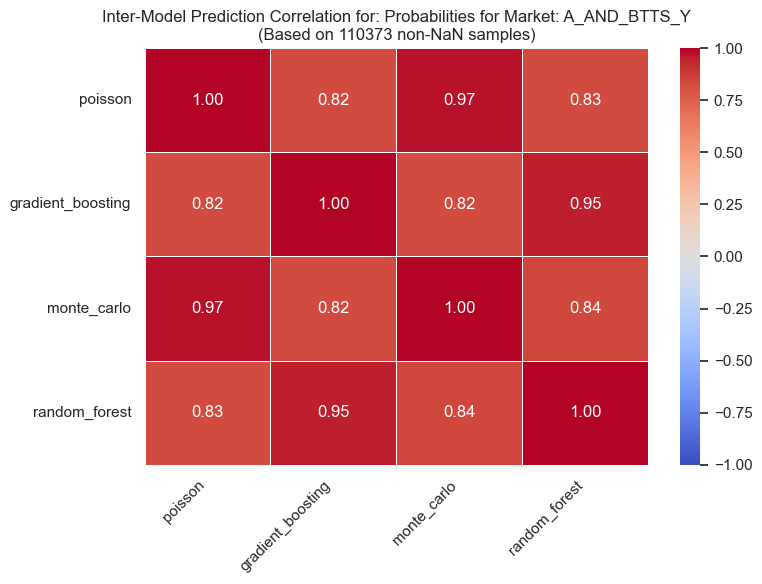


--- Processing correlations for market: H_AND_BTTS_N ---


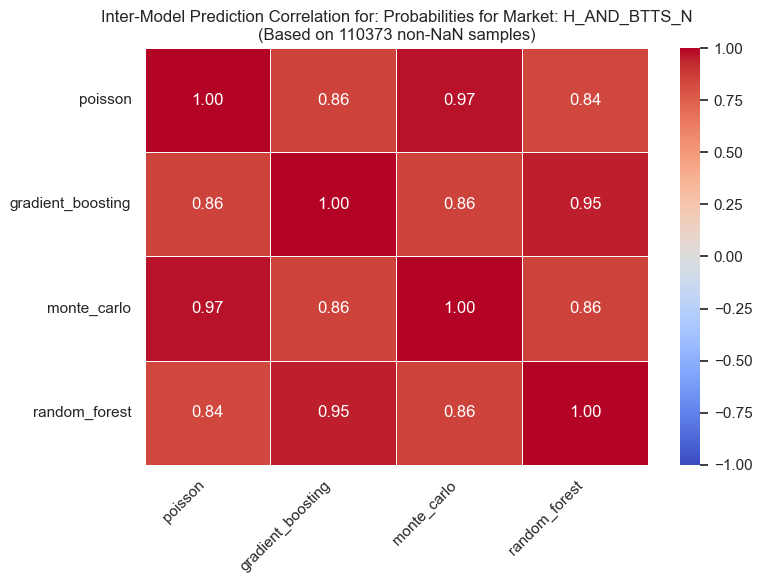


--- Processing correlations for market: D_AND_BTTS_N ---


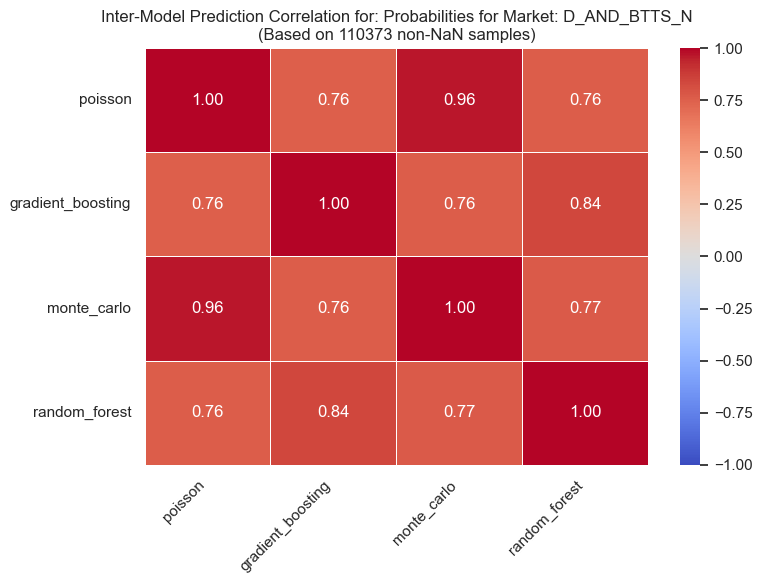


--- Processing correlations for market: A_AND_BTTS_N ---


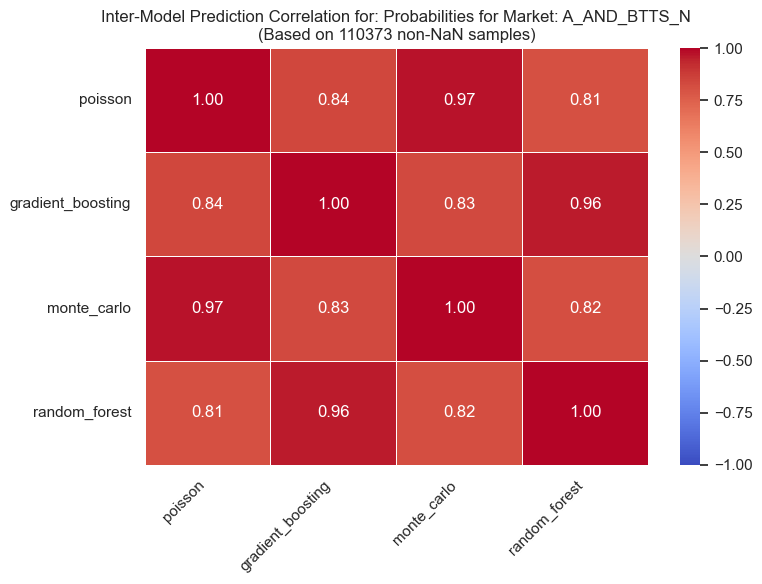


--- Processing correlations for market: 1X_AND_BTTS_Y ---


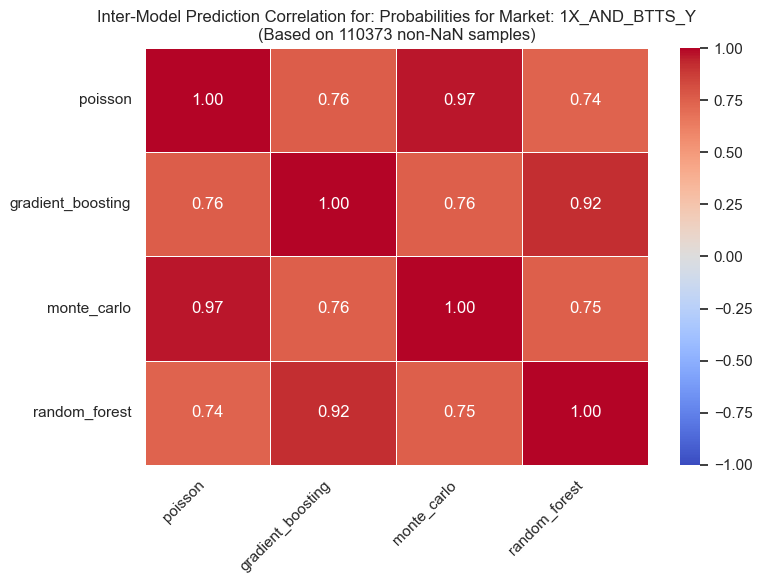


--- Processing correlations for market: 12_AND_BTTS_Y ---


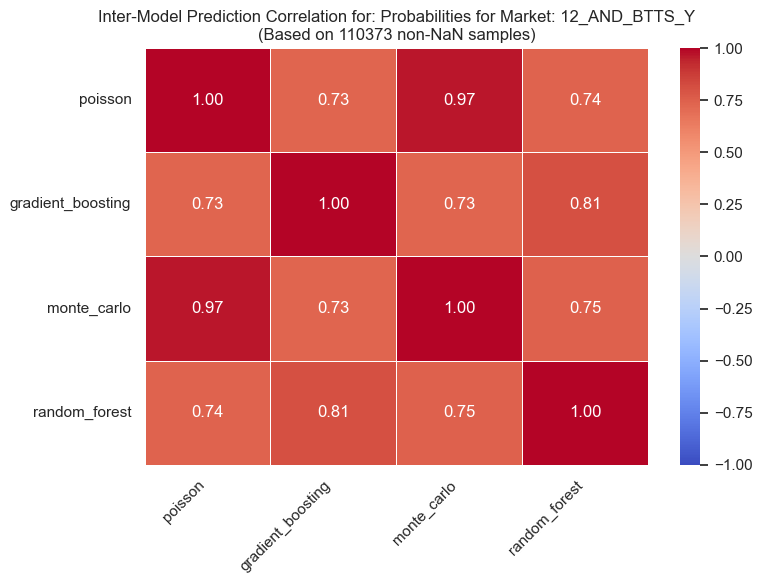


--- Processing correlations for market: X2_AND_BTTS_Y ---


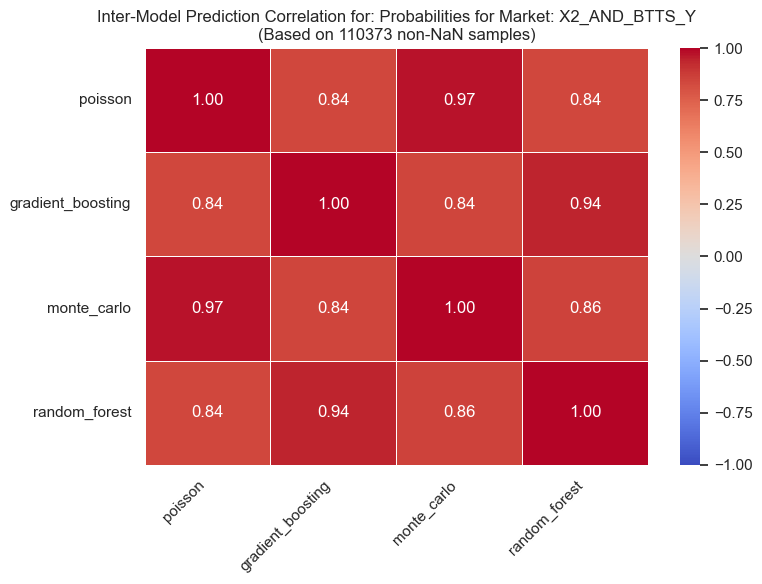


--- Processing correlations for market: 1X_AND_BTTS_N ---


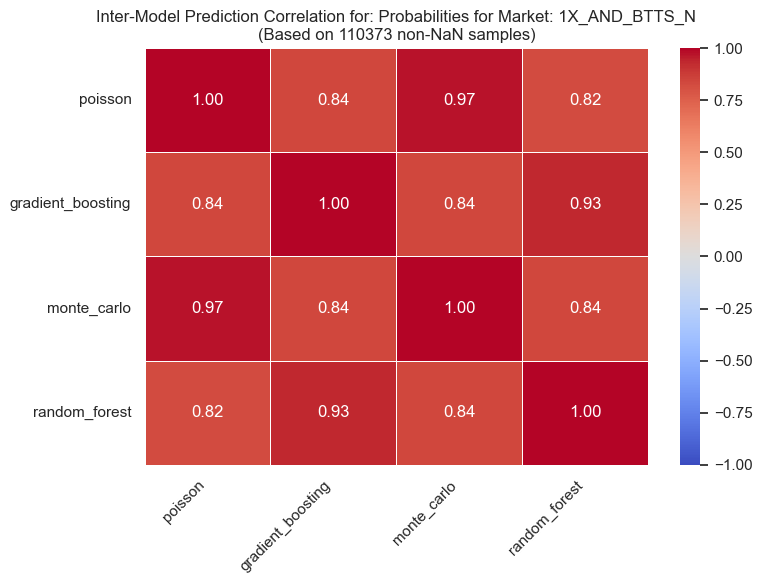


--- Processing correlations for market: 12_AND_BTTS_N ---


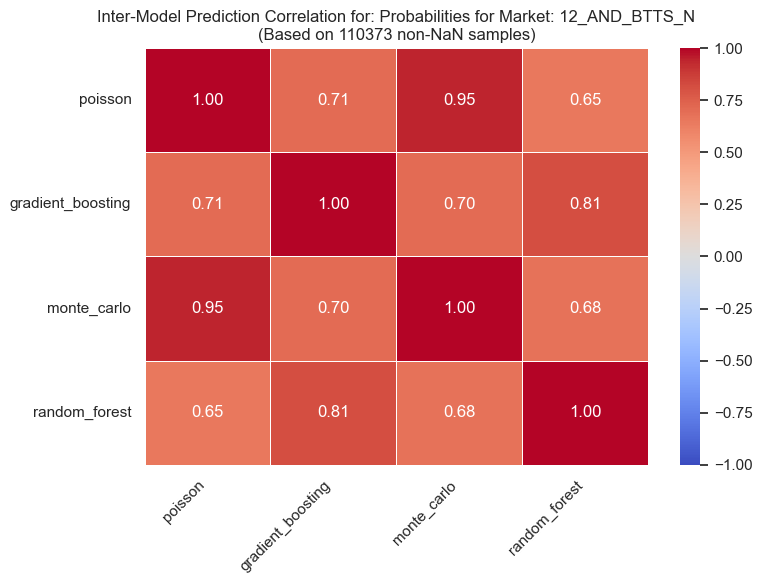


--- Processing correlations for market: X2_AND_BTTS_N ---


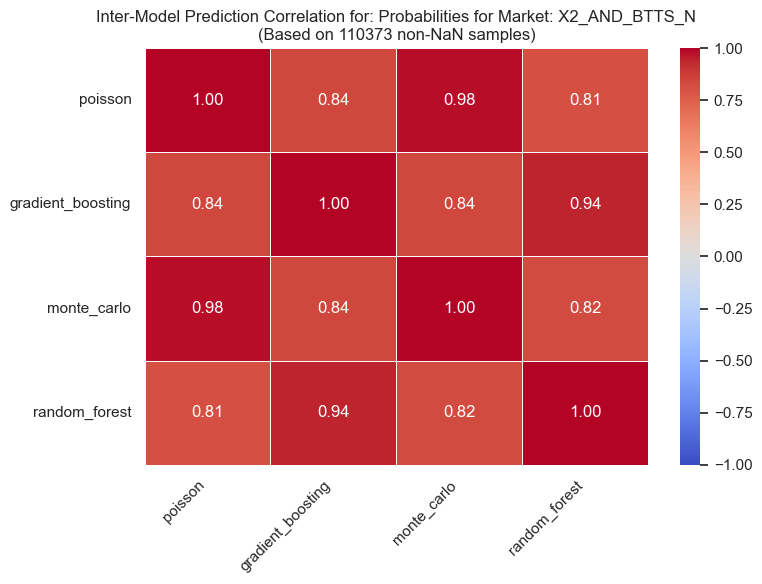


--- Processing correlations for market: O25_AND_BTTS_Y ---


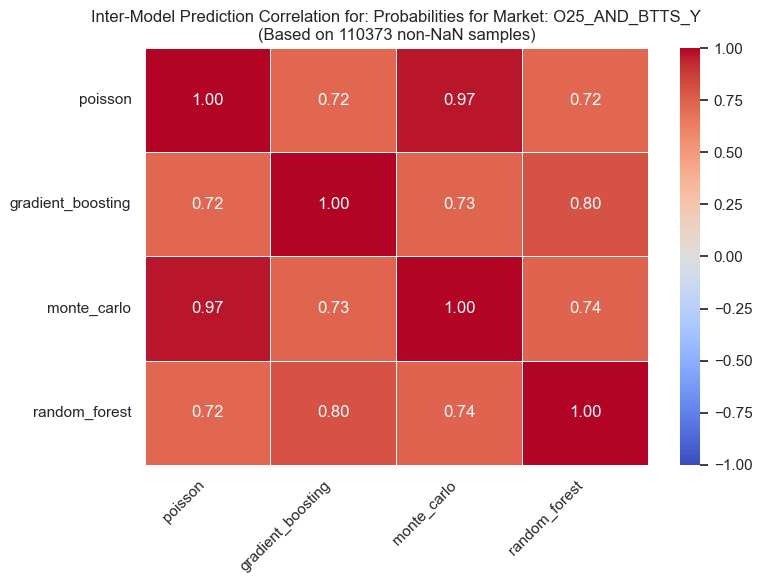


--- Processing correlations for market: O25_AND_BTTS_N ---


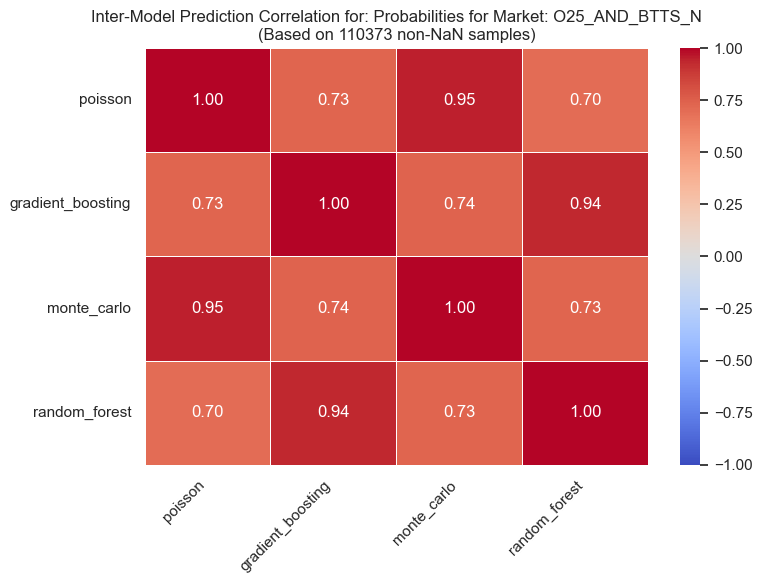


--- Processing correlations for market: U25_AND_BTTS_Y ---


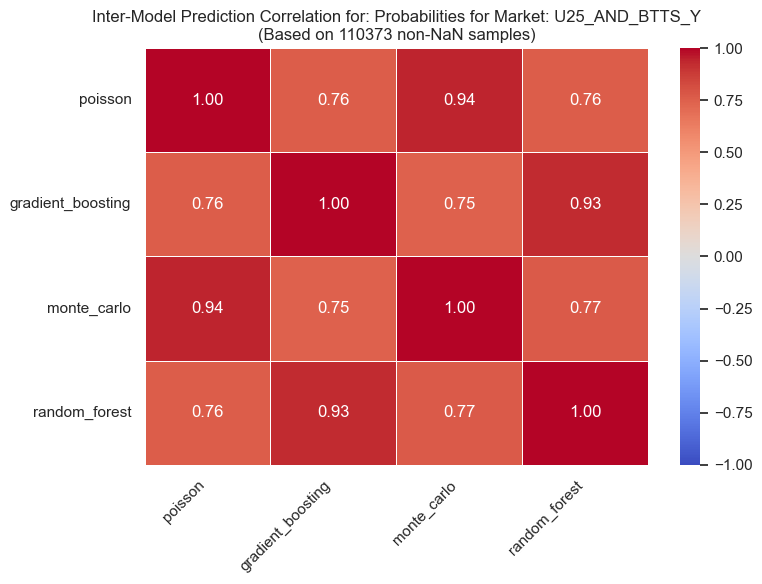


--- Processing correlations for market: U25_AND_BTTS_N ---


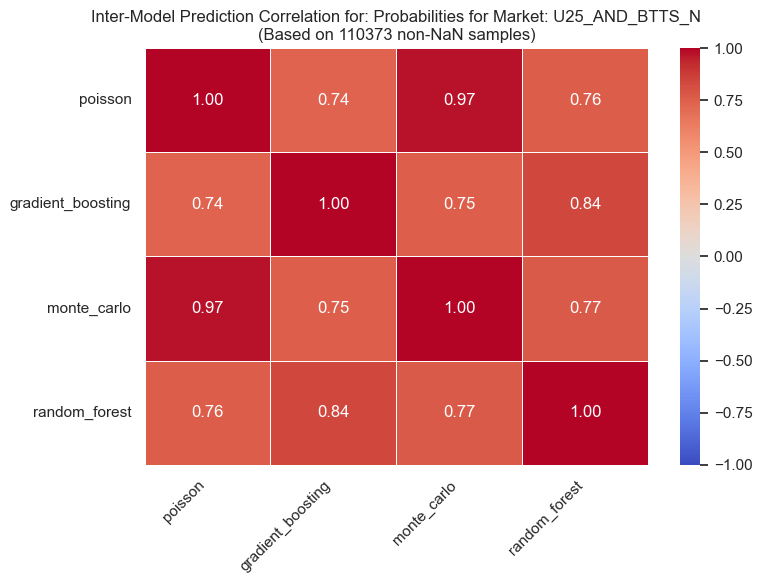


--- Interpreting Prediction Correlation Heatmaps ---

- Values close to 1.0: Indicate that two models' predictions for that market are highly positively correlated.
- Values close to 0.0: Indicate little to no linear correlation.
- High positive correlations suggest models capture similar information for that market.
- Lower correlations suggest models bring different perspectives, which is good for stacking.
- Remember this is correlation of *predictions*. Error correlation (Section 6) is often more insightful.

Inter-Model Prediction Correlation (ALL PROBABILITY MARKETS) section complete.


In [6]:
# ==============================================================================
# --- 5. Inter-Model Prediction Correlation (FOR ALL PROBABILITY MARKETS) ---
# ==============================================================================
print("\n--- 5. Inter-Model Prediction Correlation (ALL PROBABILITY MARKETS) ---")
print("Purpose: Identify how similar or different the predictions from various models are FOR ALL PROBABILITY MARKETS.")
print("WARNING: This will generate a heatmap for each of the " + str(len(CORE_PROBABILITY_KEYS)) + " probability markets. This can be a lot of plots!")

# --- Plotting Function for Correlation Heatmap (remains the same) ---
def plot_prediction_correlation_heatmap(
    df_corr: pd.DataFrame,
    models_corr: List[str],
    market_suffix_corr: str, # e.g., 'H', 'O25'. 'prob_' will be prepended
    market_display_name_corr: str
):
    """
    Calculates and plots a heatmap of the Pearson correlation matrix
    for predictions from different models for a single market.
    """
    prob_key_prefix_corr = "prob_" # The actual prefix in column names
    full_prob_key_corr = f"{prob_key_prefix_corr}{market_suffix_corr}"
    
    market_pred_cols: List[str] = []
    valid_models_for_market: List[str] = []

    for model_name_corr in models_corr:
        pred_col_name_corr = f"{model_name_corr}_{full_prob_key_corr}"
        if pred_col_name_corr in df_corr.columns:
            market_pred_cols.append(pred_col_name_corr)
            valid_models_for_market.append(model_name_corr)
        else:
            warnings.warn(f"Prediction column {pred_col_name_corr} not found. It will be excluded from correlation for this market.", RuntimeWarning)

    if len(market_pred_cols) < 2:
        print(f"Not enough models ({len(market_pred_cols)}) with predictions for market '{market_display_name_corr}' to calculate correlation. Skipping.")
        return

    predictions_df_for_market = df_corr[market_pred_cols].dropna()
    
    if predictions_df_for_market.shape[0] < 2:
        print(f"Not enough non-NaN samples ({predictions_df_for_market.shape[0]}) for market '{market_display_name_corr}' after dropping NaNs. Skipping correlation.")
        return

    column_rename_map = {old_col: new_name for old_col, new_name in zip(market_pred_cols, valid_models_for_market)}
    predictions_df_for_market_renamed = predictions_df_for_market.rename(columns=column_rename_map)

    correlation_matrix = predictions_df_for_market_renamed.corr(method='pearson')

    plt.figure(figsize=(8, 6))
    sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', fmt=".2f", vmin=-1, vmax=1, linewidths=.5)
    plt.title(f"Inter-Model Prediction Correlation for: {market_display_name_corr}\n(Based on {len(predictions_df_for_market)} non-NaN samples)")
    plt.xticks(rotation=45, ha="right")
    plt.yticks(rotation=0)
    plt.tight_layout()
    plt.show()

    # Optionally print the matrix to console if many plots are generated
    # print(f"Correlation matrix for {market_display_name_corr}:\n{correlation_matrix}\n")


# --- Generate Correlation Heatmaps for ALL Probability Markets ---
print("\nGenerating prediction correlation heatmaps for ALL probability markets...")

# Iterate through each core probability key
for prob_key_full_item in CORE_PROBABILITY_KEYS:
    # Extract the market suffix (e.g., 'H', 'O25', 'H_and_O25')
    market_suffix_item = prob_key_full_item.replace('prob_', '')
    
    # Create a display name for the plot title
    display_name_item = f"Probabilities for Market: {market_suffix_item.upper()}"
    
    print(f"\n--- Processing correlations for market: {market_suffix_item.upper()} ---")

    # Basic check if the market suffix generally exists for at least one model type
    # The full prediction column is model_prefix + _ + prob_key_full_item
    example_pred_col_check = f"{model_keys[0]}_{prob_key_full_item}"
    if example_pred_col_check not in df_oof.columns:
        warnings.warn(f"Prediction key '{prob_key_full_item}' (e.g., {example_pred_col_check}) appears to be missing for model {model_keys[0]}. Skipping correlation plot for this market.", RuntimeWarning)
        continue
        
    plot_prediction_correlation_heatmap(
        df_corr=df_oof,
        models_corr=model_keys,
        market_suffix_corr=market_suffix_item, # Pass the suffix like 'H', 'O25', 'H_and_BTTS_Y'
        market_display_name_corr=display_name_item
    )

print("\n--- Interpreting Prediction Correlation Heatmaps ---")
print("""
- Values close to 1.0: Indicate that two models' predictions for that market are highly positively correlated.
- Values close to 0.0: Indicate little to no linear correlation.
- High positive correlations suggest models capture similar information for that market.
- Lower correlations suggest models bring different perspectives, which is good for stacking.
- Remember this is correlation of *predictions*. Error correlation (Section 6) is often more insightful.
""")
print("Inter-Model Prediction Correlation (ALL PROBABILITY MARKETS) section complete.")


--- 6. Error Analysis & Correlation of Errors ---
Purpose: Understand if models make similar mistakes or if their errors are independent.
Low error correlation is highly desirable for stacking.

Calculating prediction errors for all probability markets (optimized approach)...
200 error columns calculated and concatenated.
df_errors shape: (110373, 463)

Generating error correlation heatmaps for ALL probability markets...

--- Processing ERROR correlations for market: H ---


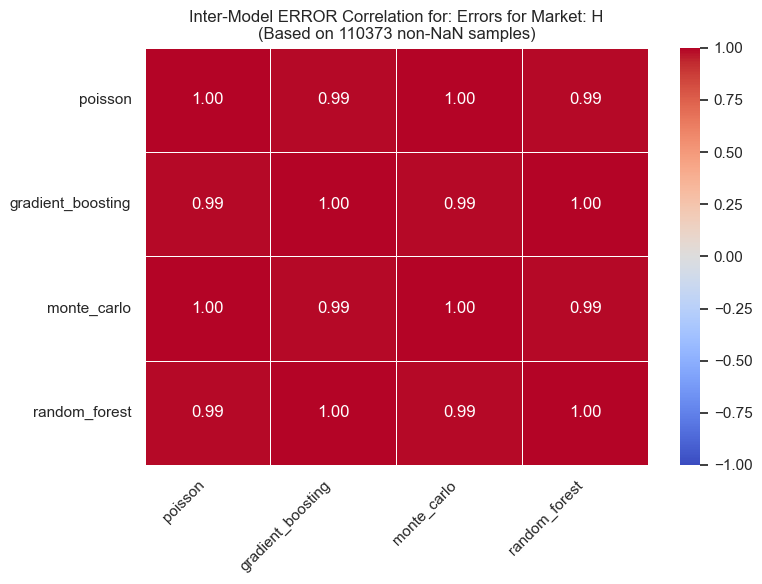


--- Processing ERROR correlations for market: D ---


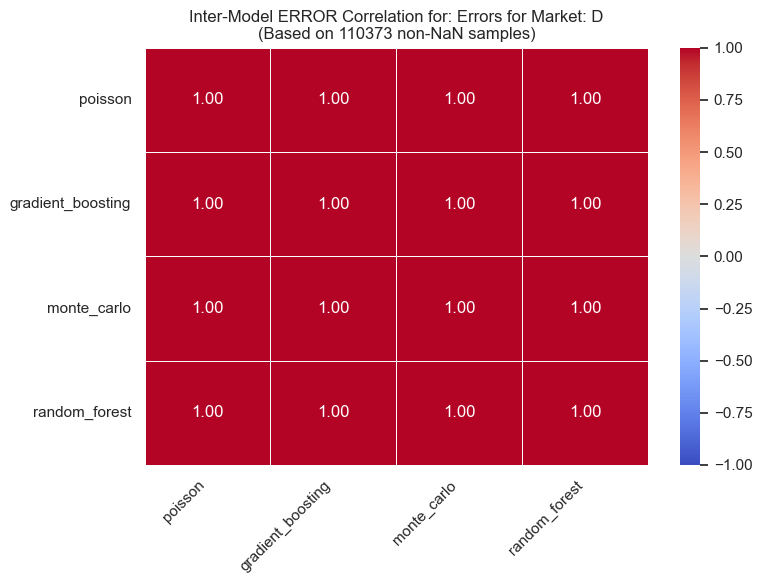


--- Processing ERROR correlations for market: A ---


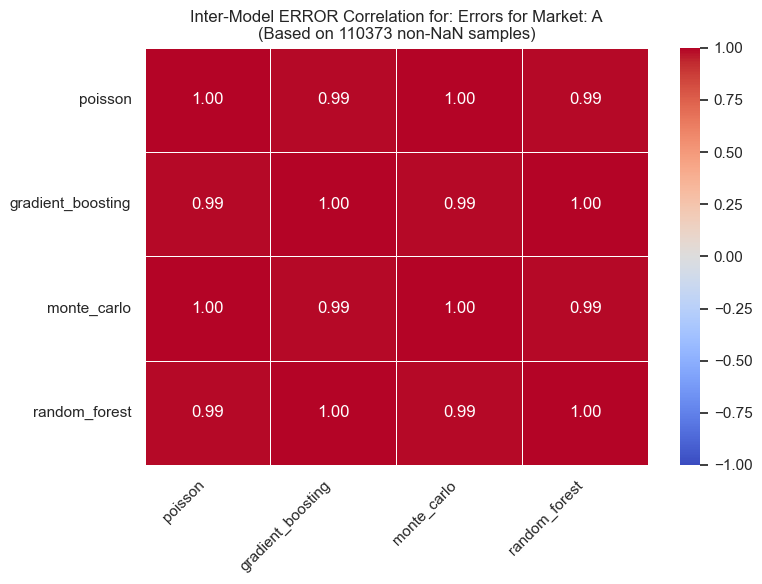


--- Processing ERROR correlations for market: O05 ---


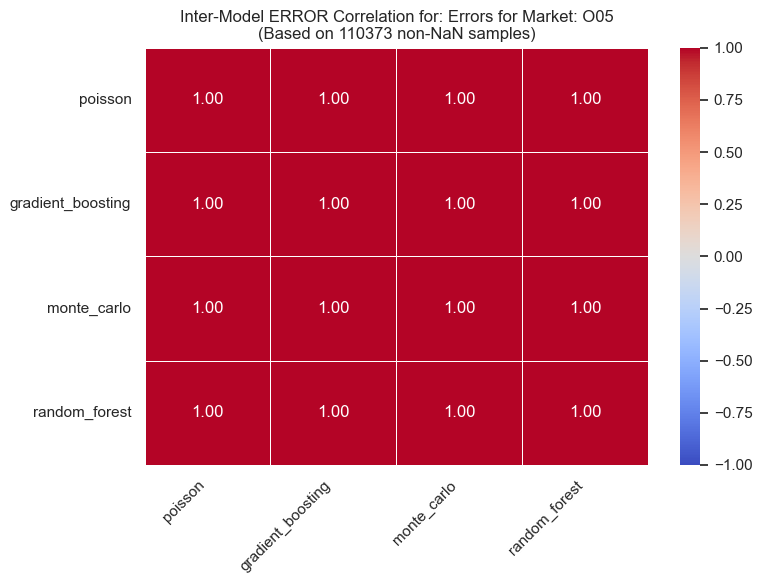


--- Processing ERROR correlations for market: U05 ---


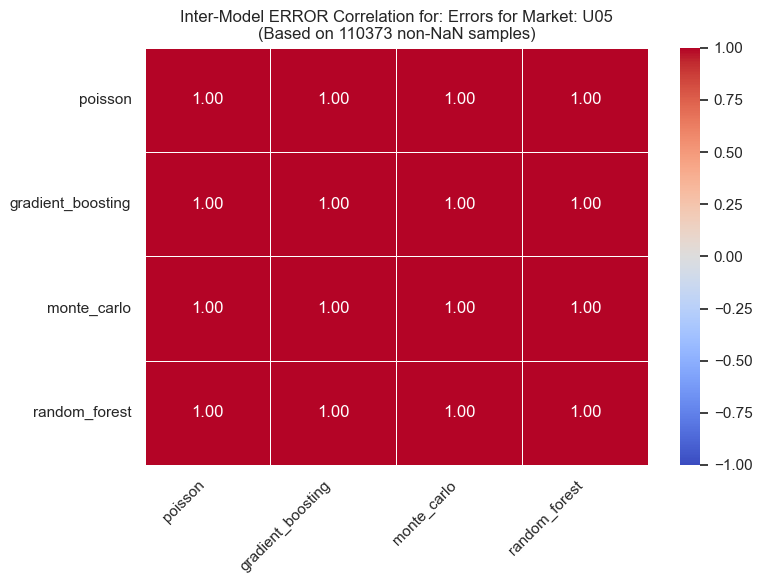


--- Processing ERROR correlations for market: O15 ---


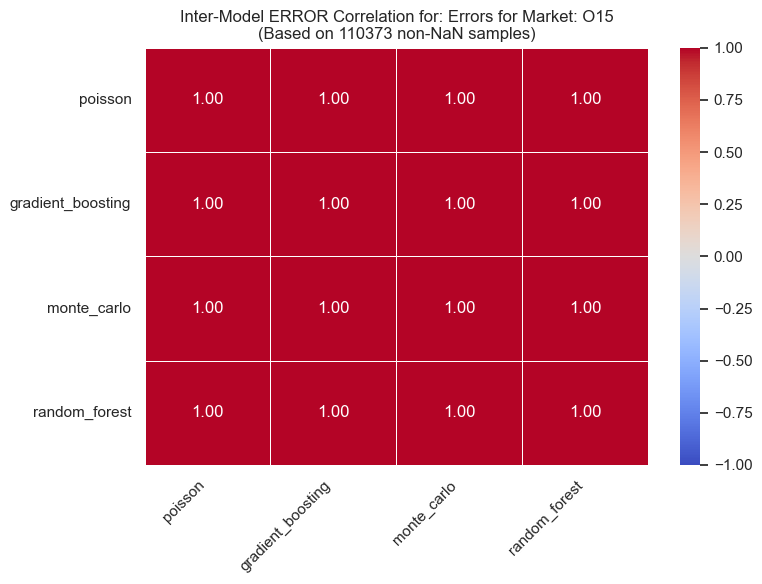


--- Processing ERROR correlations for market: U15 ---


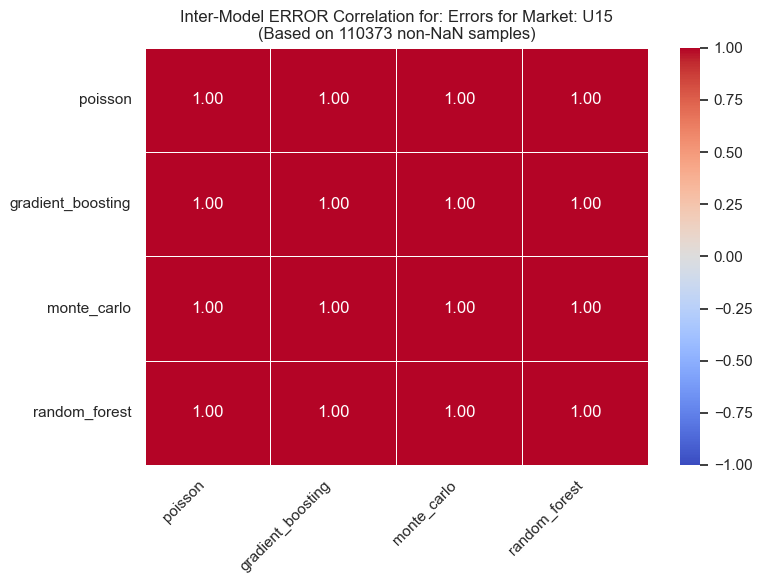


--- Processing ERROR correlations for market: O25 ---


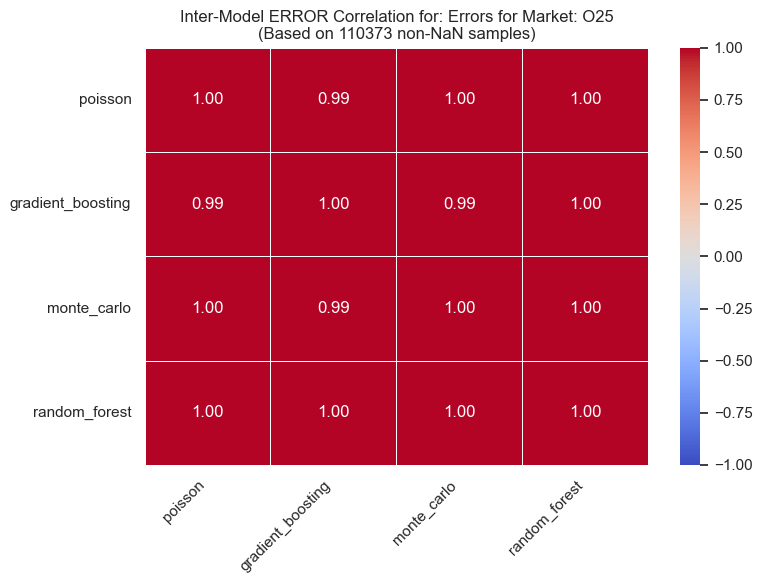


--- Processing ERROR correlations for market: U25 ---


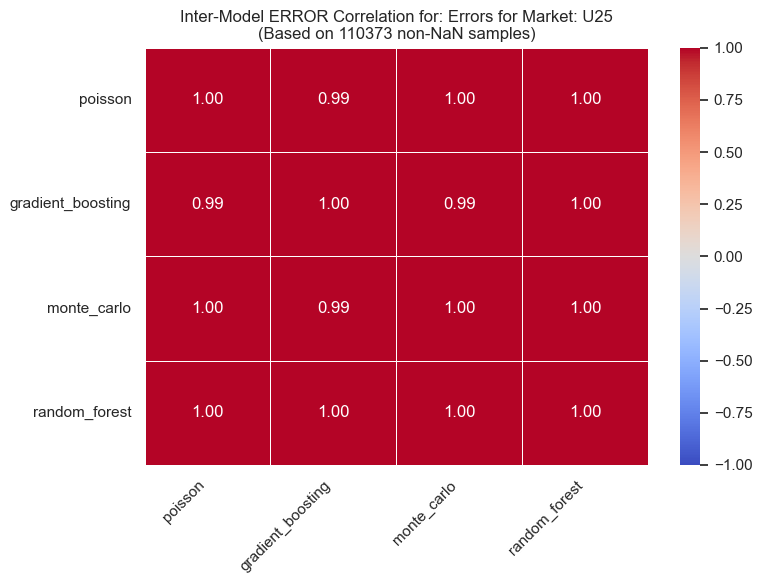


--- Processing ERROR correlations for market: O35 ---


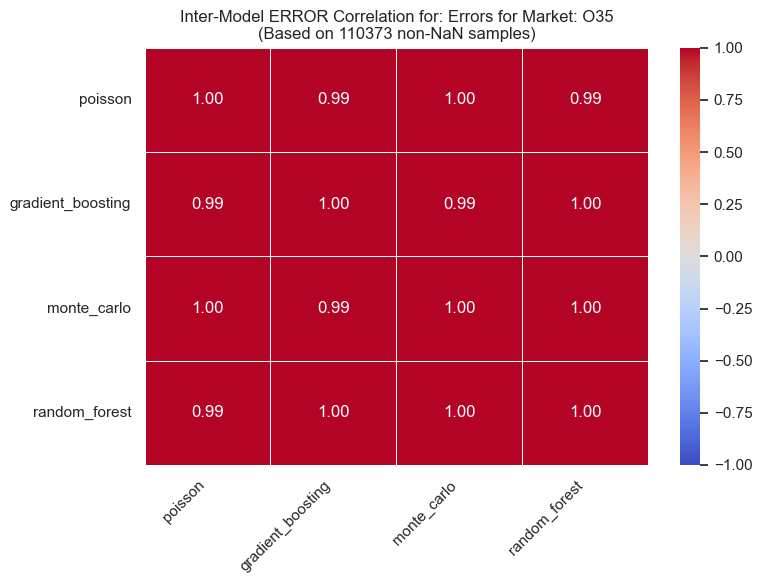


--- Processing ERROR correlations for market: U35 ---


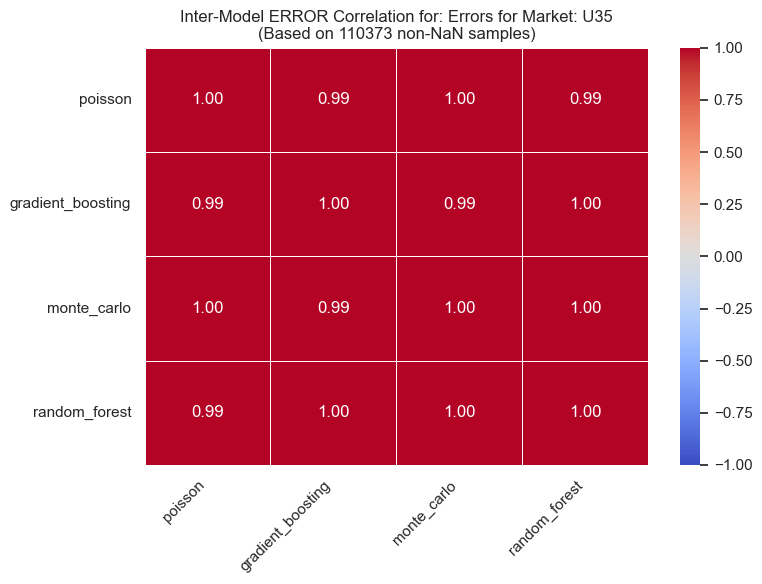


--- Processing ERROR correlations for market: O45 ---


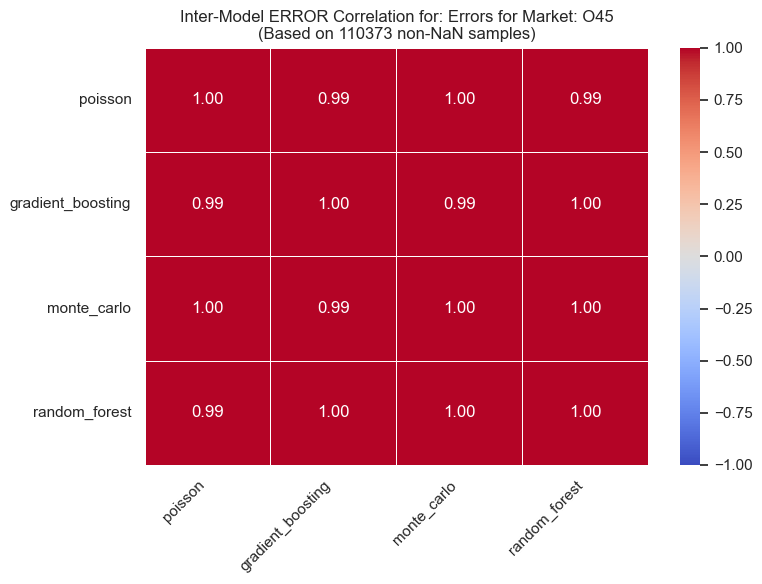


--- Processing ERROR correlations for market: U45 ---


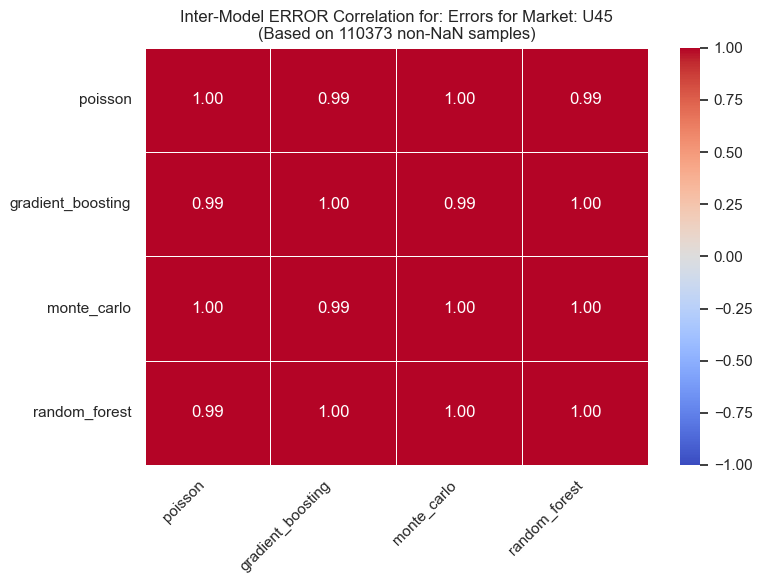


--- Processing ERROR correlations for market: BTTS_Y ---


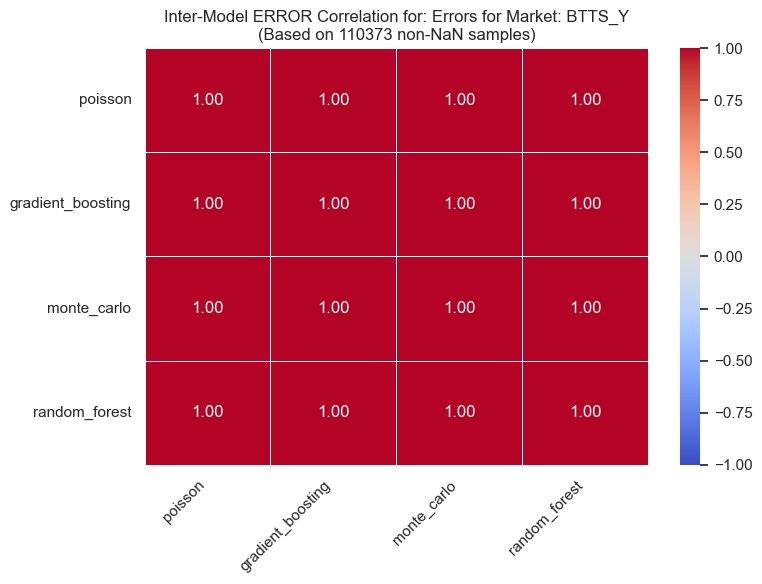


--- Processing ERROR correlations for market: BTTS_N ---


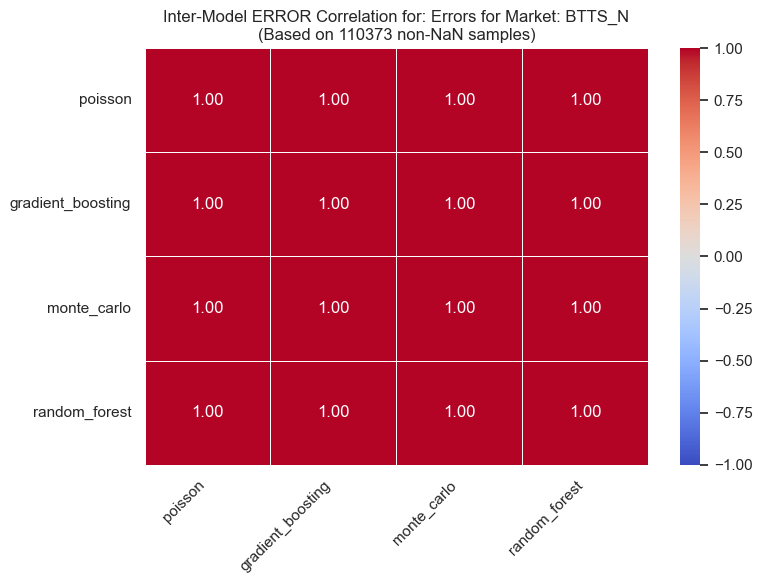


--- Processing ERROR correlations for market: 1X ---


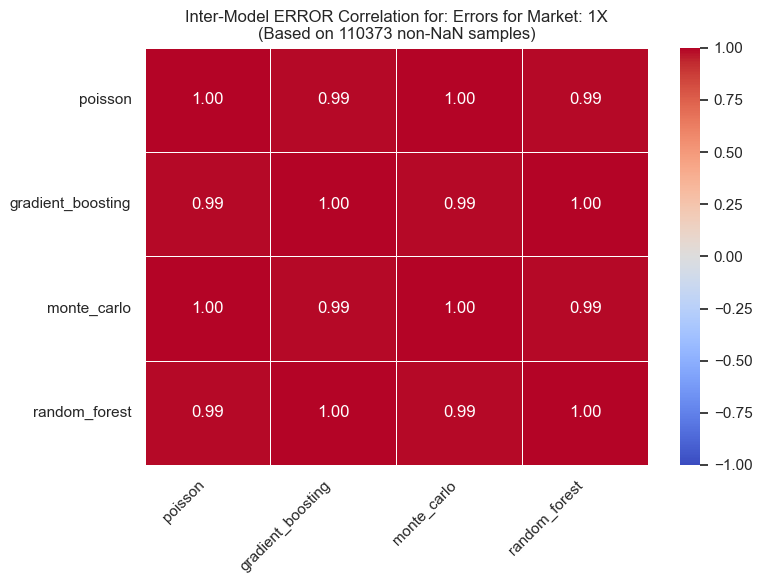


--- Processing ERROR correlations for market: 12 ---


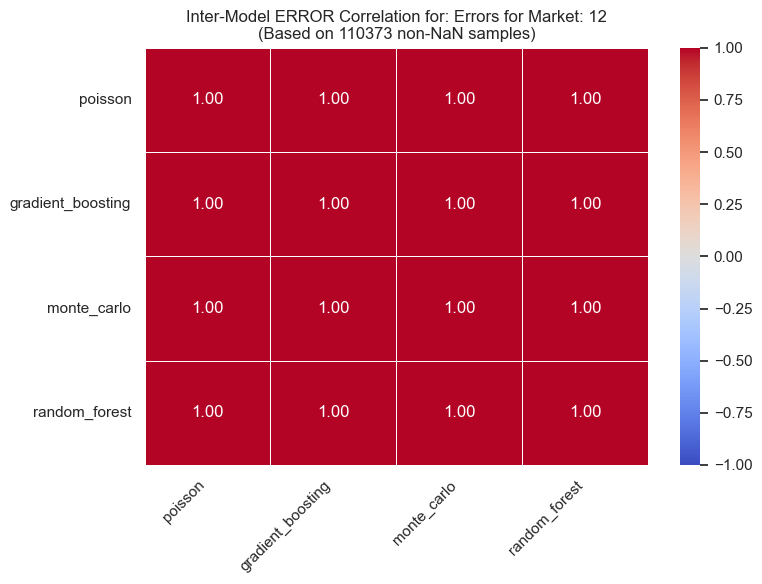


--- Processing ERROR correlations for market: X2 ---


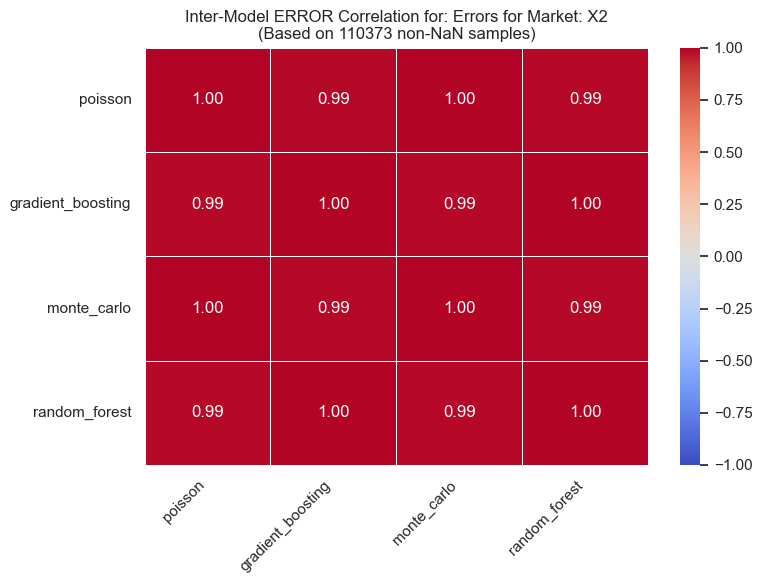


--- Processing ERROR correlations for market: GOALS_0_1 ---


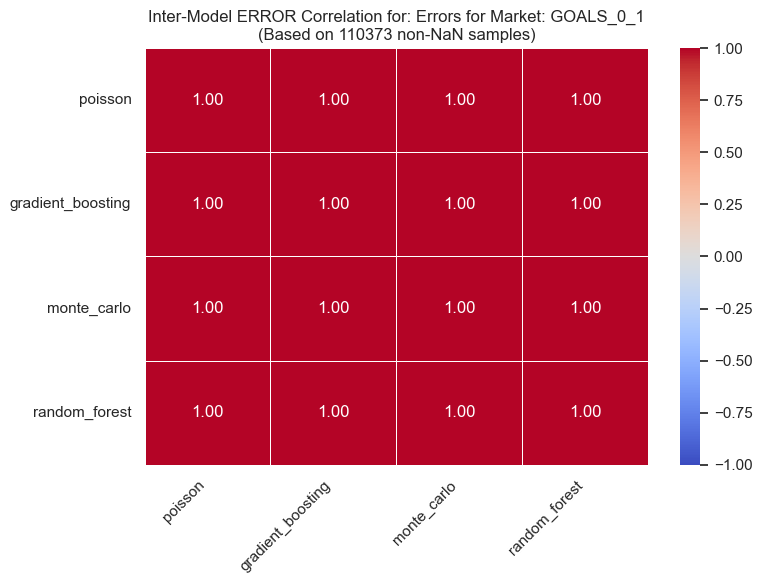


--- Processing ERROR correlations for market: GOALS_2_3 ---


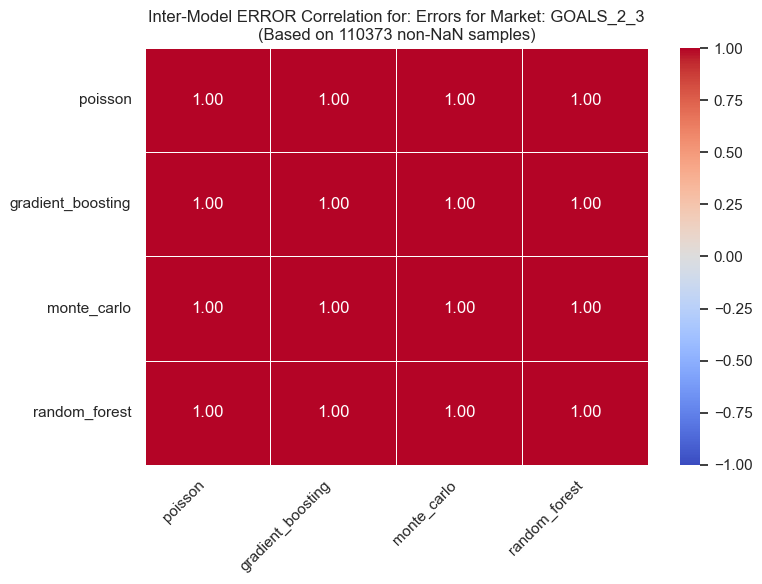


--- Processing ERROR correlations for market: GOALS_2_4 ---


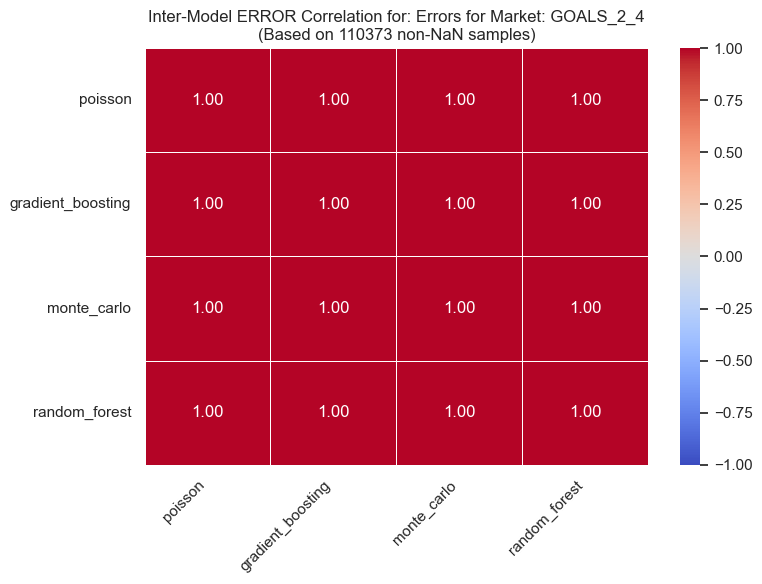


--- Processing ERROR correlations for market: GOALS_3_PLUS ---


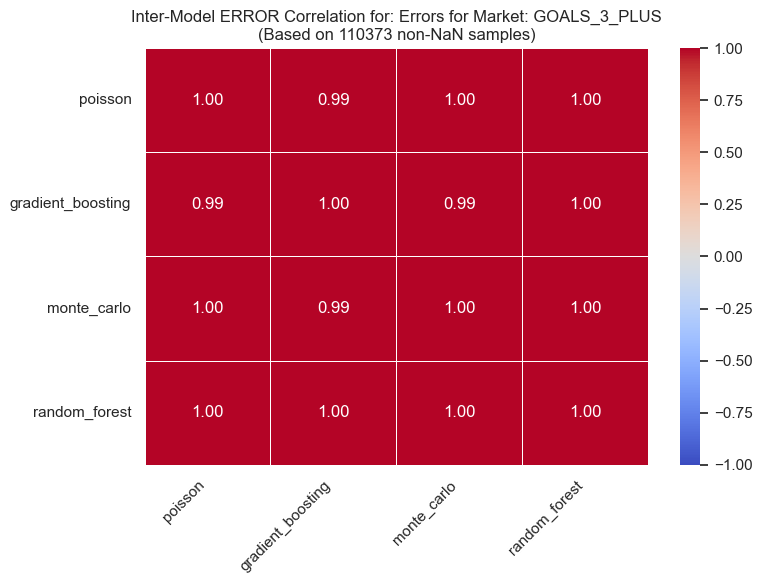


--- Processing ERROR correlations for market: H_AND_O25 ---


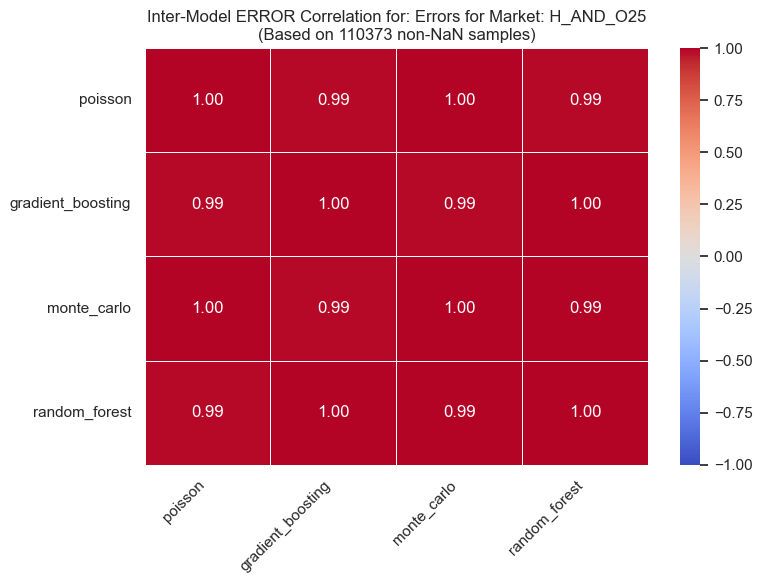


--- Processing ERROR correlations for market: D_AND_O25 ---


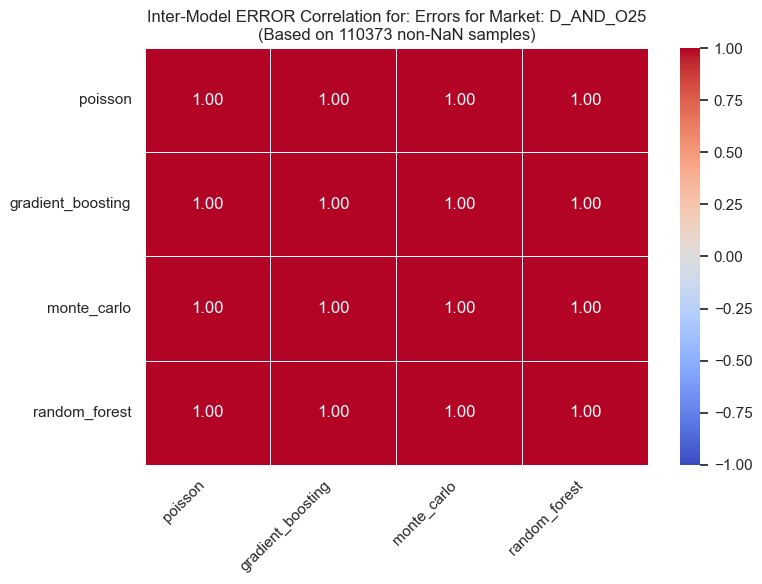


--- Processing ERROR correlations for market: A_AND_O25 ---


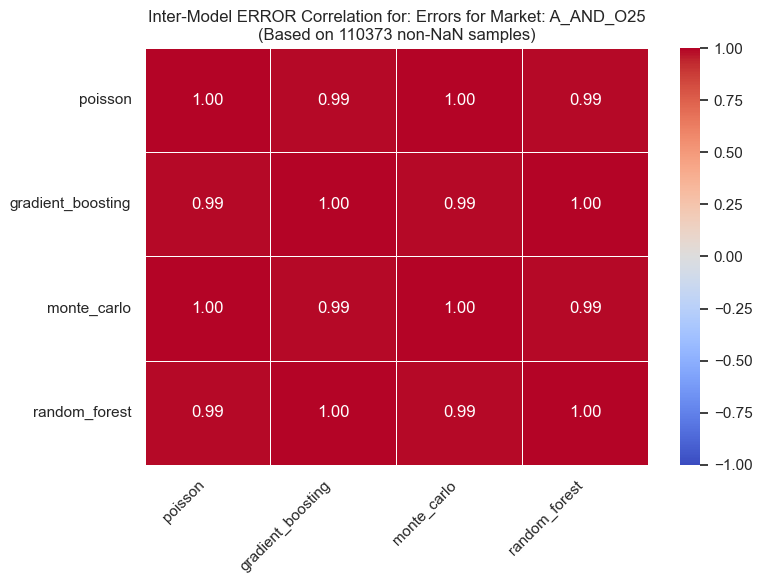


--- Processing ERROR correlations for market: H_AND_U25 ---


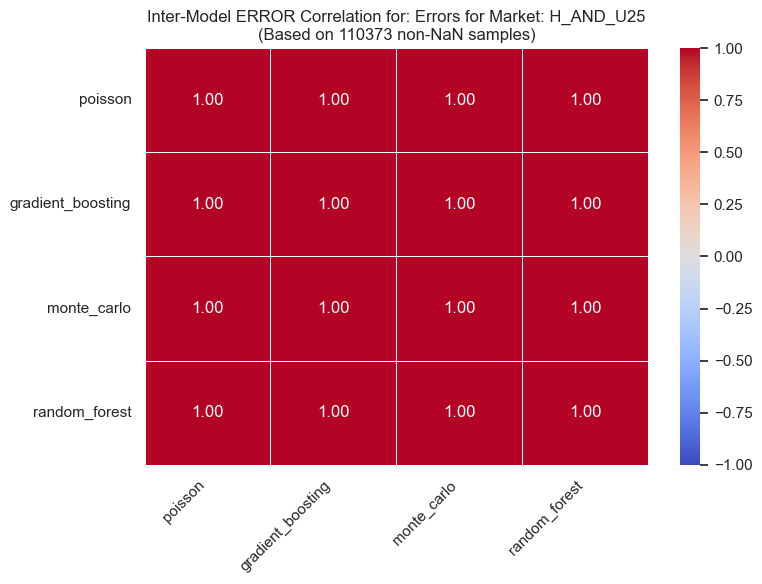


--- Processing ERROR correlations for market: D_AND_U25 ---


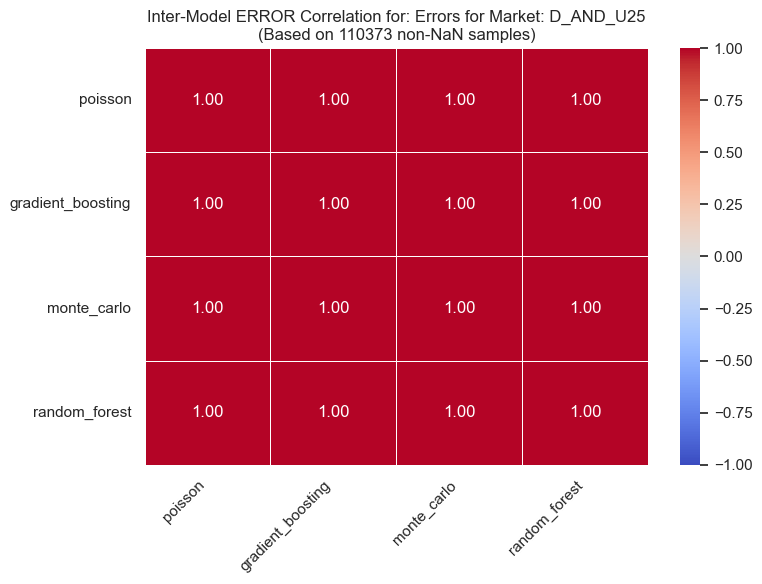


--- Processing ERROR correlations for market: A_AND_U25 ---


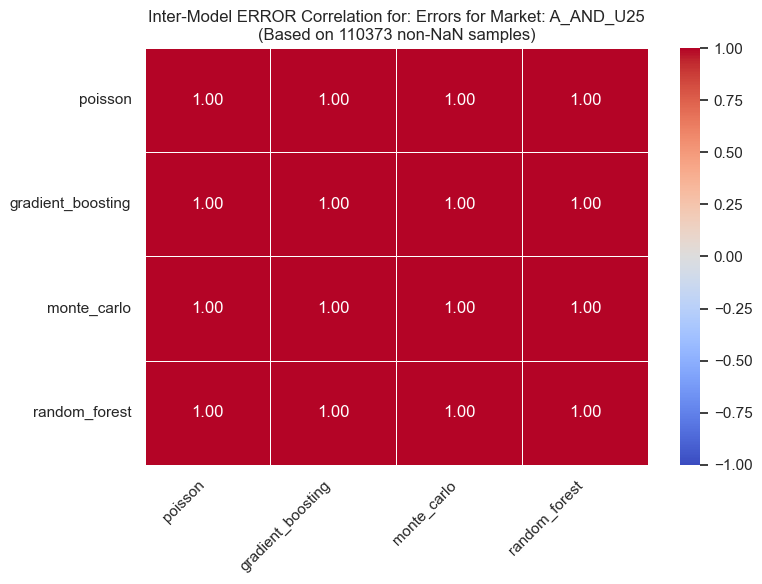


--- Processing ERROR correlations for market: 1X_AND_O25 ---


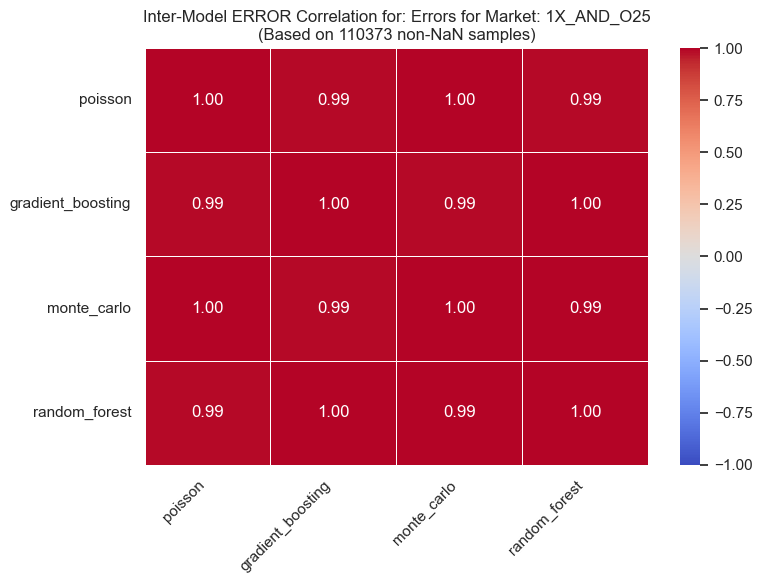


--- Processing ERROR correlations for market: 12_AND_O25 ---


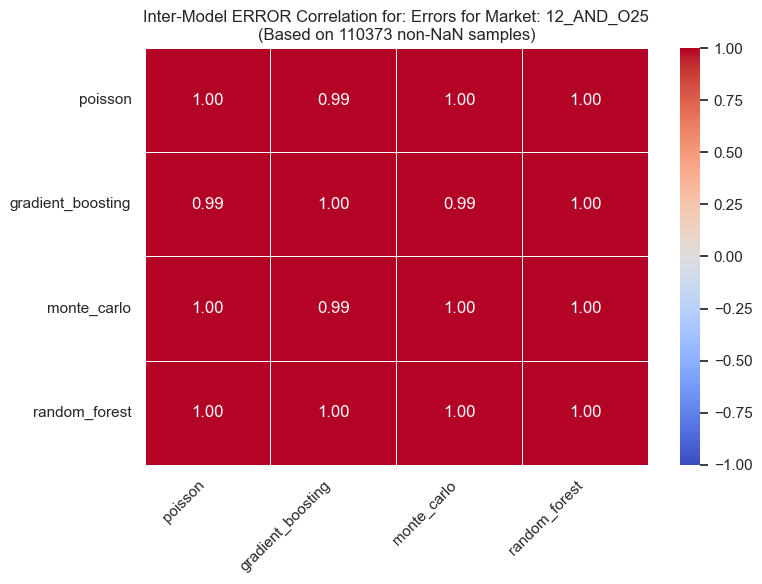


--- Processing ERROR correlations for market: X2_AND_O25 ---


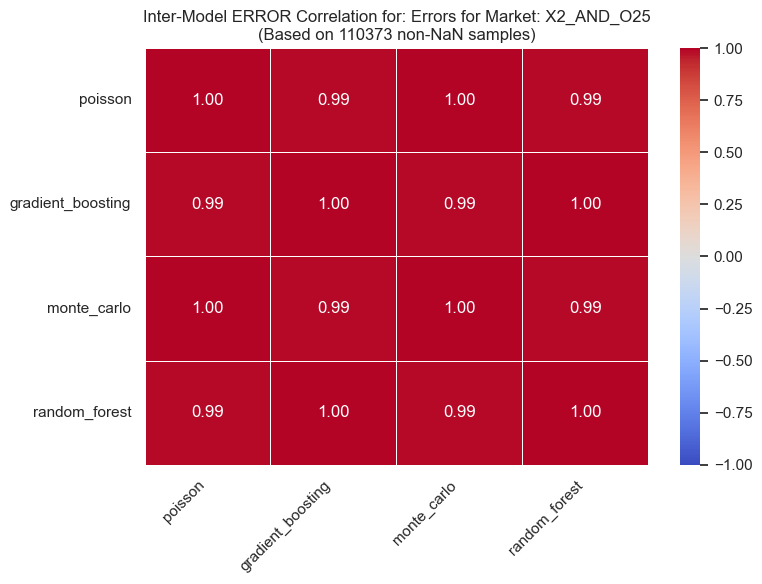


--- Processing ERROR correlations for market: 1X_AND_U25 ---


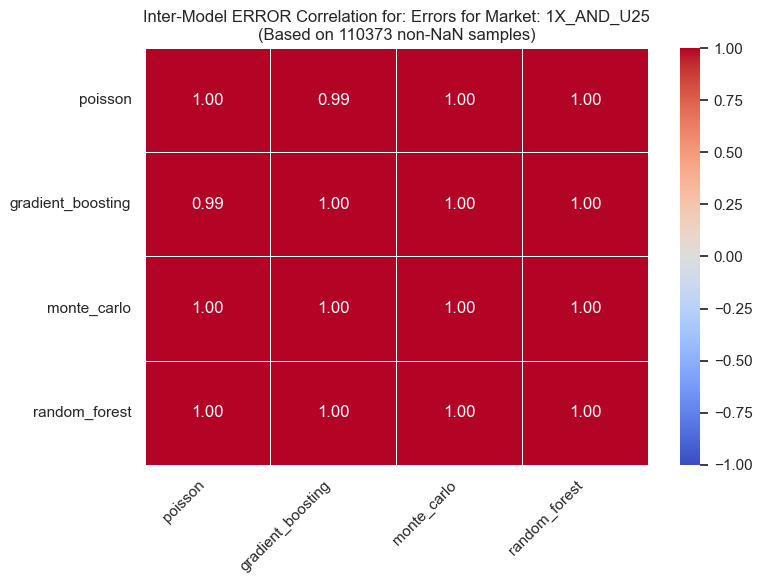


--- Processing ERROR correlations for market: 12_AND_U25 ---


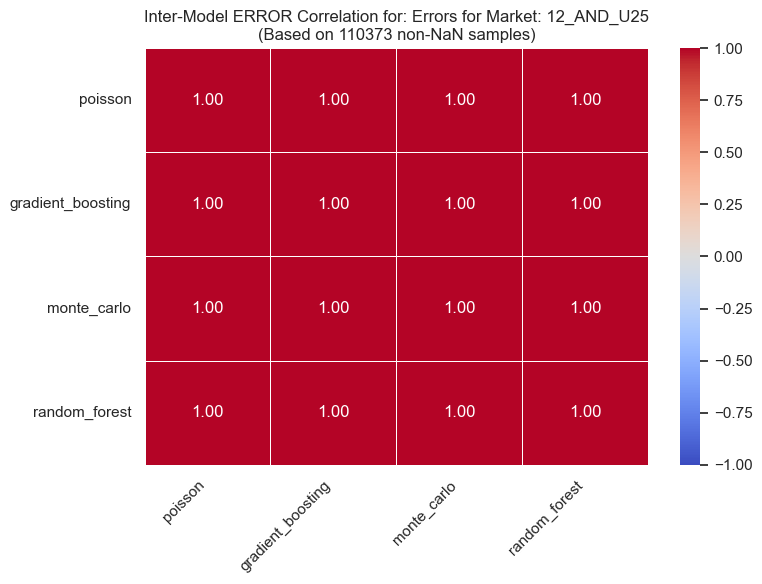


--- Processing ERROR correlations for market: X2_AND_U25 ---


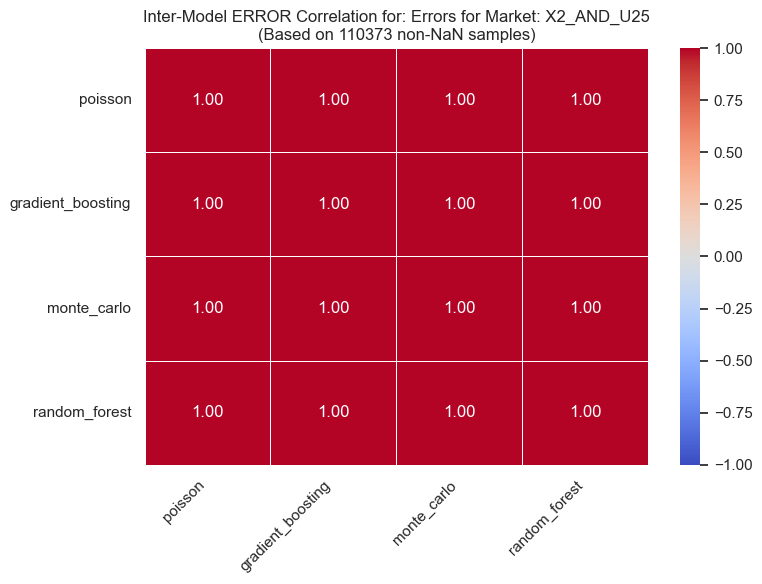


--- Processing ERROR correlations for market: H_AND_BTTS_Y ---


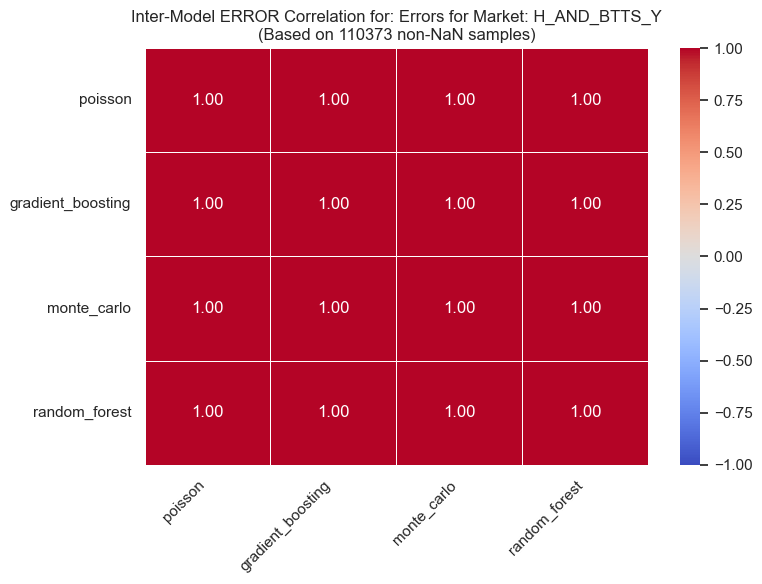


--- Processing ERROR correlations for market: D_AND_BTTS_Y ---


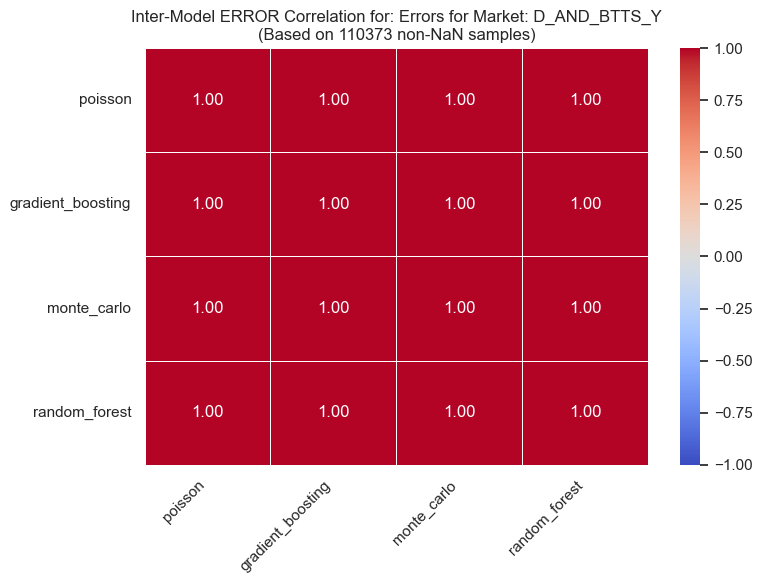


--- Processing ERROR correlations for market: A_AND_BTTS_Y ---


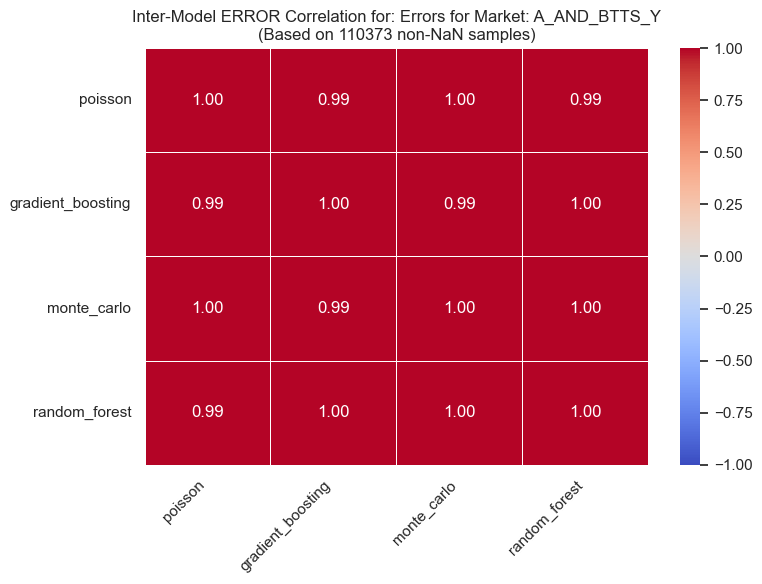


--- Processing ERROR correlations for market: H_AND_BTTS_N ---


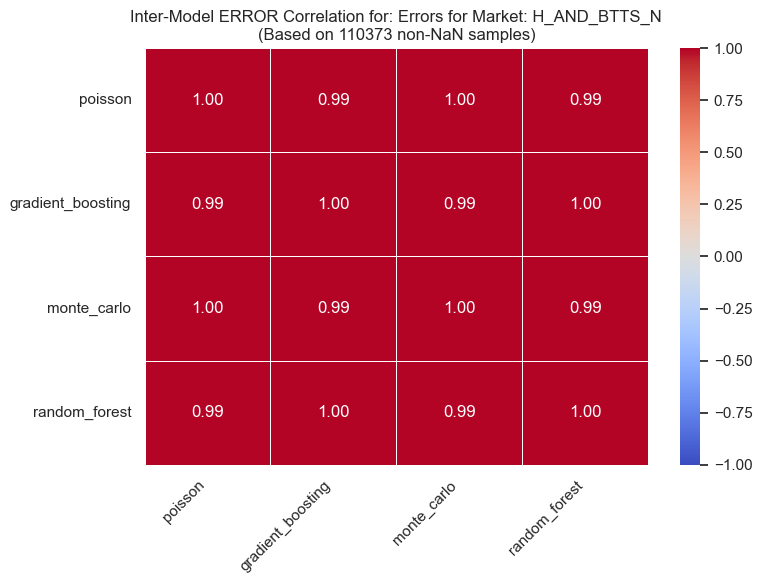


--- Processing ERROR correlations for market: D_AND_BTTS_N ---


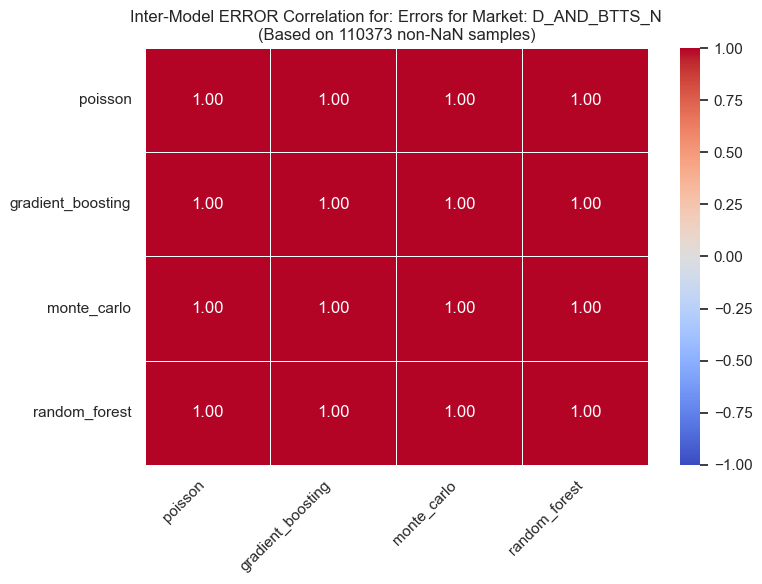


--- Processing ERROR correlations for market: A_AND_BTTS_N ---


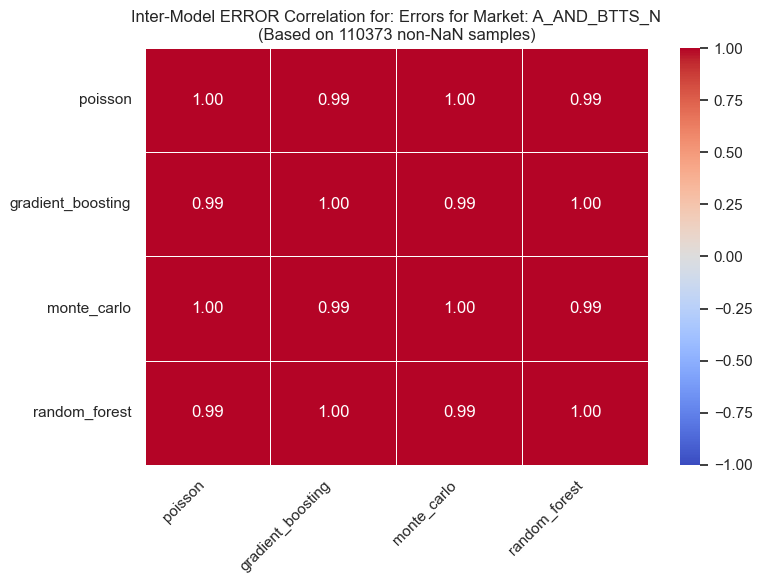


--- Processing ERROR correlations for market: 1X_AND_BTTS_Y ---


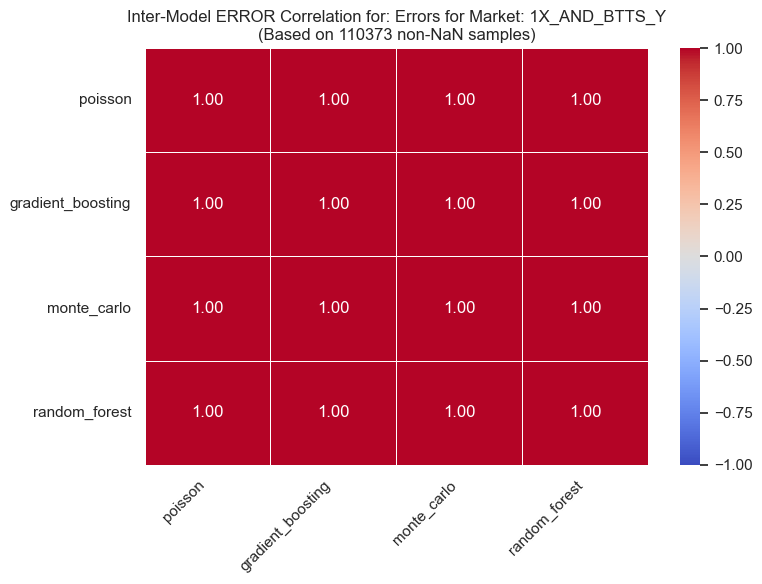


--- Processing ERROR correlations for market: 12_AND_BTTS_Y ---


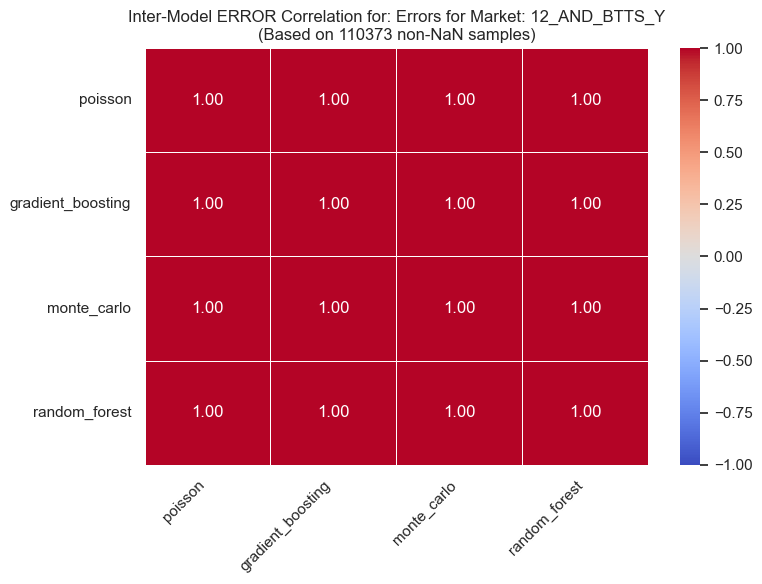


--- Processing ERROR correlations for market: X2_AND_BTTS_Y ---


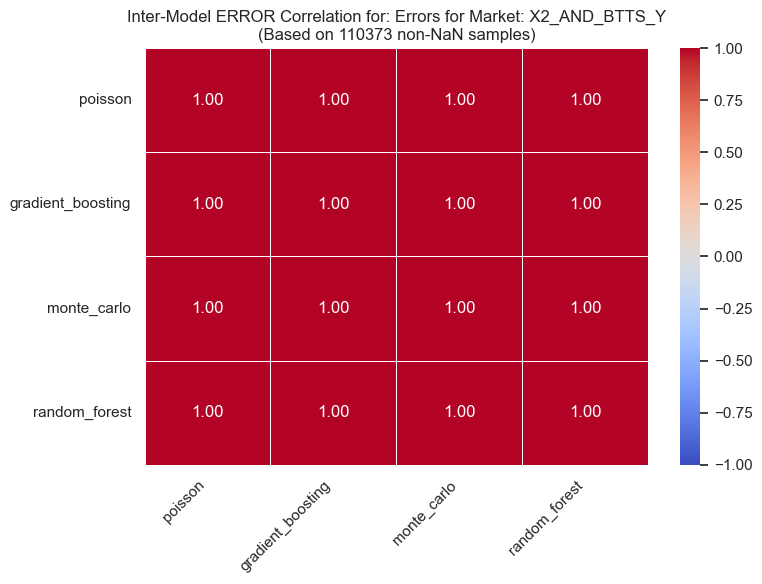


--- Processing ERROR correlations for market: 1X_AND_BTTS_N ---


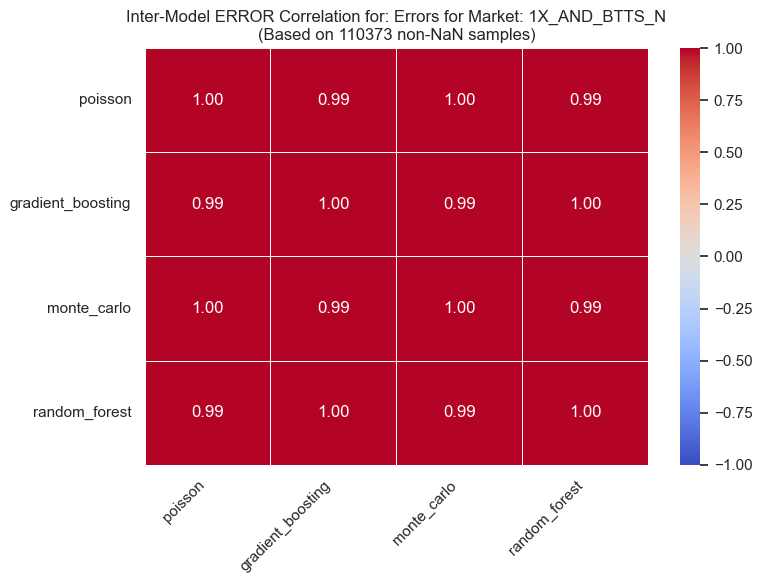


--- Processing ERROR correlations for market: 12_AND_BTTS_N ---


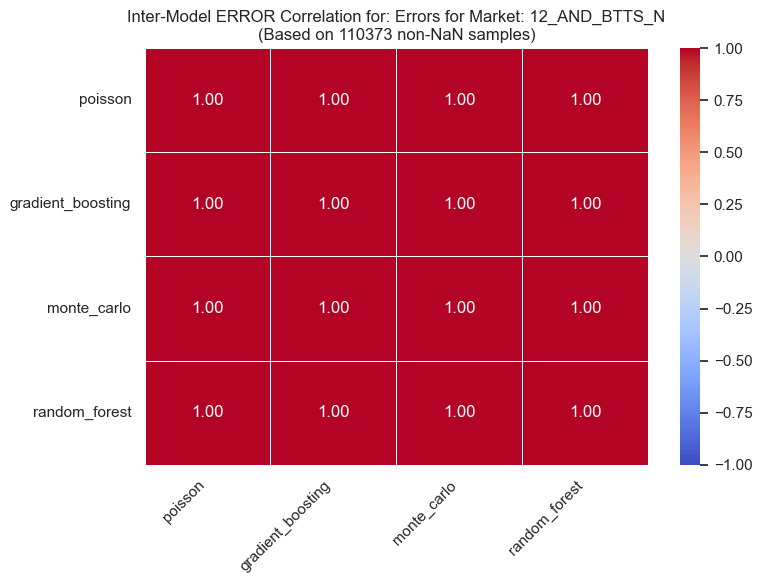


--- Processing ERROR correlations for market: X2_AND_BTTS_N ---


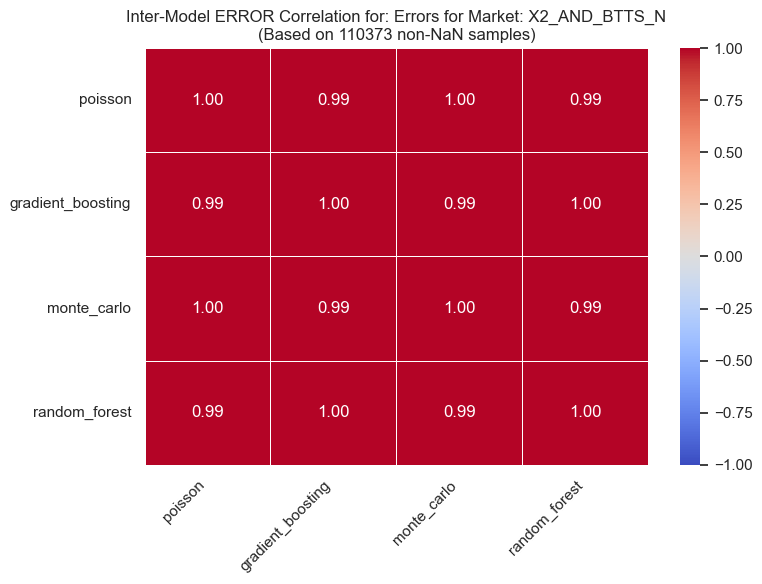


--- Processing ERROR correlations for market: O25_AND_BTTS_Y ---


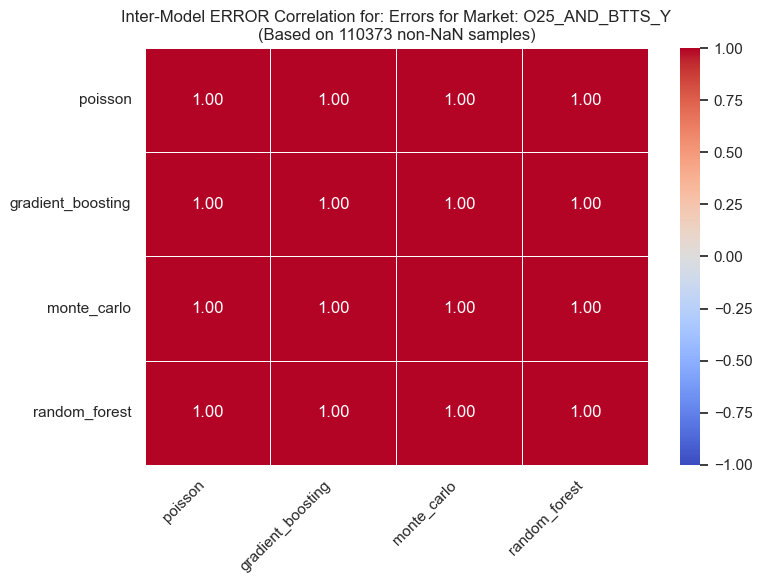


--- Processing ERROR correlations for market: O25_AND_BTTS_N ---


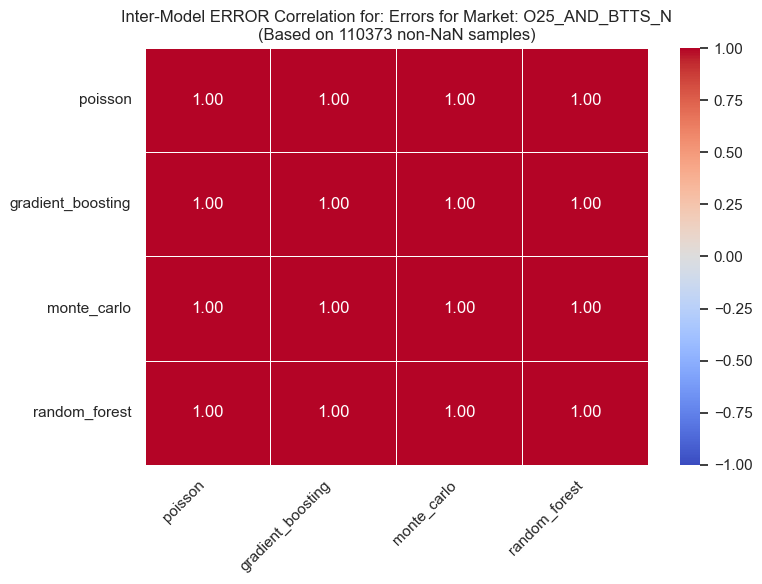


--- Processing ERROR correlations for market: U25_AND_BTTS_Y ---


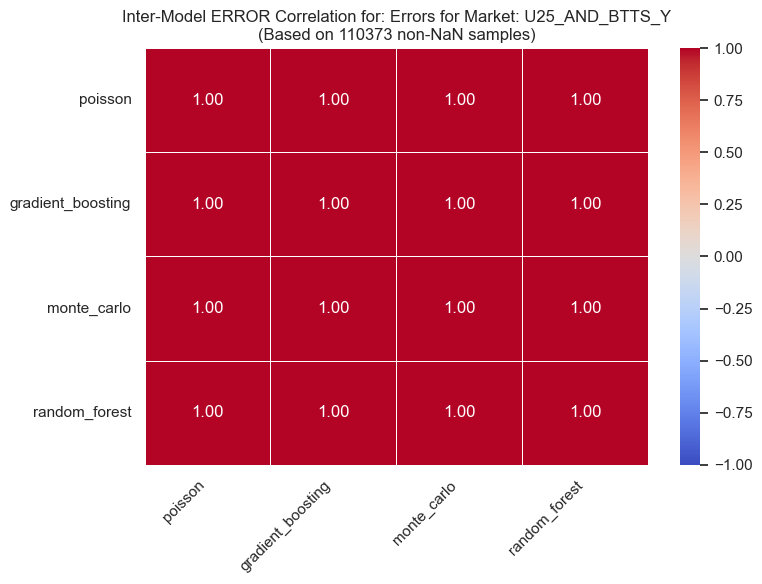


--- Processing ERROR correlations for market: U25_AND_BTTS_N ---


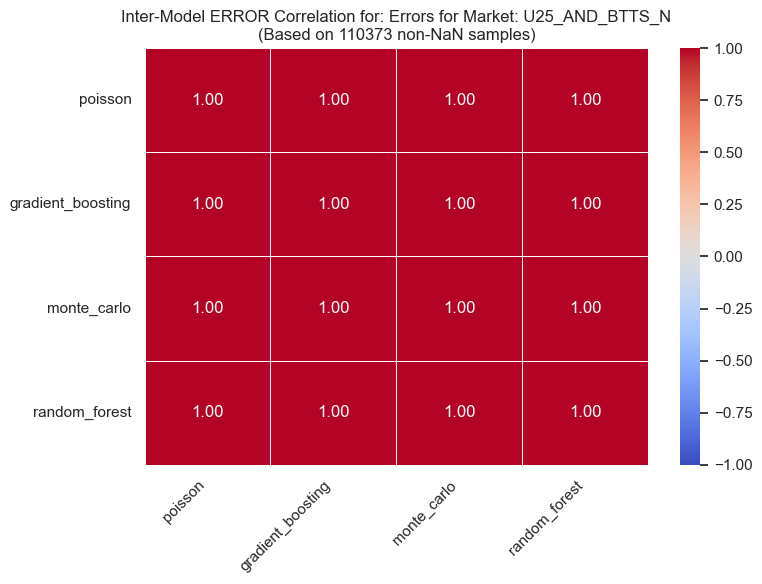


--- Interpreting ERROR Correlation Heatmaps ---

- Values close to 1.0: Models tend to make the *same kind* of mistake (both overpredict or both underpredict by similar relative amounts). THIS IS BAD for stacking.
- Values close to 0.0: Models' errors are largely independent. When one model is off, the other's error is not systematically related. THIS IS GOOD for stacking.
- Values close to -1.0: Models' errors are negatively correlated. When one model overpredicts, the other tends to underpredict. THIS IS EXCELLENT (but rare) for stacking.
- The goal is to find models with low (ideally near zero or negative) error correlations.
- Even if predictions were highly correlated, if errors are not, a stacker can still learn to improve overall performance.

Error Analysis & Correlation of Errors section complete.


In [32]:
# ==============================================================================
# --- 6. Error Analysis & Correlation of Errors (Optimized for DataFrame Creation) ---
# ==============================================================================
print("\n--- 6. Error Analysis & Correlation of Errors ---")
print("Purpose: Understand if models make similar mistakes or if their errors are independent.")
print("Low error correlation is highly desirable for stacking.")

# --- Calculate Prediction Errors (Optimized Approach) ---
# Error = Predicted Probability - Actual Outcome (0 or 1)

print("\nCalculating prediction errors for all probability markets (optimized approach)...")

# Start with a list to hold the new error Series
error_series_list: List[pd.Series] = []
calculated_error_cols_count = 0

for model_name_err in model_keys:
    for prob_key_full_err in CORE_PROBABILITY_KEYS:
        market_suffix_err = prob_key_full_err.replace('prob_', '')
        
        pred_col_name_err = f"{model_name_err}_{prob_key_full_err}"
        actual_col_name_err = f"Actual_{market_suffix_err}"
        error_col_name_err = f"{model_name_err}_error_{market_suffix_err}" # e.g., poisson_error_H
        
        # Check if necessary columns exist in the original df_oof
        if pred_col_name_err in df_oof.columns and actual_col_name_err in df_oof.columns:
            # Calculate the error series
            current_error_series = df_oof[pred_col_name_err] - df_oof[actual_col_name_err]
            current_error_series.name = error_col_name_err # Name the series for concatenation
            
            error_series_list.append(current_error_series)
            calculated_error_cols_count +=1
        else:
            if pred_col_name_err not in df_oof.columns:
                warnings.warn(f"Prediction column {pred_col_name_err} not found in df_oof. Cannot calculate errors for it.", RuntimeWarning)
            if actual_col_name_err not in df_oof.columns:
                warnings.warn(f"Actual column {actual_col_name_err} not found in df_oof. Cannot calculate errors for {pred_col_name_err}.", RuntimeWarning)

# Concatenate all newly created error series with the original df_oof
if error_series_list:
    # Ensure correct alignment by index; df_oof provides the base index.
    df_errors = pd.concat([df_oof] + error_series_list, axis=1)
    print(f"{calculated_error_cols_count} error columns calculated and concatenated.")
    print(f"df_errors shape: {df_errors.shape}")
    # Verify a few error columns exist
    # example_check_cols = [col for col in df_errors.columns if '_error_H' in col and col.startswith(model_keys[0])]
    # if example_check_cols:
    #     print(f"Head of example error columns for 'H' market (model: {model_keys[0]}):\n{df_errors[example_check_cols].head()}")
else:
    print("No error series were generated. df_errors will be a copy of df_oof.")
    df_errors = df_oof.copy() # Fallback if no errors were made (should not happen if data is valid)

assert calculated_error_cols_count == len(model_keys) * len(CORE_PROBABILITY_KEYS), \
    f"Expected {len(model_keys) * len(CORE_PROBABILITY_KEYS)} error columns, but generated {calculated_error_cols_count}"


# --- Plotting Function for Error Correlation Heatmap (remains the same as before) ---
def plot_error_correlation_heatmap(
    df_err_data: pd.DataFrame,
    models_err_plot: List[str],
    market_suffix_err_plot: str, # e.g., 'H', 'O25'. '_error_' will be inserted.
    market_display_name_err_plot: str
):
    error_key_infix_err_plot = "_error_"
    market_error_cols: List[str] = []
    valid_models_for_market_err: List[str] = []

    for model_name_err_item in models_err_plot:
        error_col_name_item = f"{model_name_err_item}{error_key_infix_err_plot}{market_suffix_err_plot}"
        if error_col_name_item in df_err_data.columns:
            market_error_cols.append(error_col_name_item)
            valid_models_for_market_err.append(model_name_err_item)
        else:
            warnings.warn(f"Error column {error_col_name_item} not found. It will be excluded from error correlation for this market: {market_display_name_err_plot}.", RuntimeWarning)

    if len(market_error_cols) < 2:
        print(f"Not enough models ({len(market_error_cols)}) with error data for market '{market_display_name_err_plot}' to calculate correlation. Skipping.")
        return

    errors_df_for_market = df_err_data[market_error_cols].dropna()
    
    if errors_df_for_market.shape[0] < 2:
        print(f"Not enough non-NaN error samples ({errors_df_for_market.shape[0]}) for market '{market_display_name_err_plot}' after dropping NaNs. Skipping error correlation.")
        return

    column_rename_map_err = {old_col: new_name for old_col, new_name in zip(market_error_cols, valid_models_for_market_err)}
    errors_df_for_market_renamed = errors_df_for_market.rename(columns=column_rename_map_err)
    error_correlation_matrix = errors_df_for_market_renamed.corr(method='pearson')

    plt.figure(figsize=(8, 6))
    sns.heatmap(error_correlation_matrix, annot=True, cmap='coolwarm', fmt=".2f", vmin=-1, vmax=1, linewidths=.5)
    plt.title(f"Inter-Model ERROR Correlation for: {market_display_name_err_plot}\n(Based on {len(errors_df_for_market)} non-NaN samples)")
    plt.xticks(rotation=45, ha="right")
    plt.yticks(rotation=0)
    plt.tight_layout()
    plt.show()


# --- Generate Error Correlation Heatmaps for ALL Probability Markets ---
print("\nGenerating error correlation heatmaps for ALL probability markets...")
print("WARNING: This will generate a heatmap for each of the " + str(len(CORE_PROBABILITY_KEYS)) + " probability markets.")

for prob_key_full_item_err in CORE_PROBABILITY_KEYS:
    market_suffix_item_err = prob_key_full_item_err.replace('prob_', '')
    display_name_item_err = f"Errors for Market: {market_suffix_item_err.upper()}"
    
    print(f"\n--- Processing ERROR correlations for market: {market_suffix_item_err.upper()} ---")

    example_error_col_check = f"{model_keys[0]}_error_{market_suffix_item_err}"
    if example_error_col_check not in df_errors.columns:
        warnings.warn(f"Example error column '{example_error_col_check}' for market suffix '{market_suffix_item_err}' appears to be missing from df_errors. Skipping error correlation plot for this market.", RuntimeWarning)
        continue
        
    plot_error_correlation_heatmap(
        df_err_data=df_errors,
        models_err_plot=model_keys,
        market_suffix_err_plot=market_suffix_item_err,
        market_display_name_err_plot=display_name_item_err
    )

print("\n--- Interpreting ERROR Correlation Heatmaps ---")
print("""
- Values close to 1.0: Models tend to make the *same kind* of mistake (both overpredict or both underpredict by similar relative amounts). THIS IS BAD for stacking.
- Values close to 0.0: Models' errors are largely independent. When one model is off, the other's error is not systematically related. THIS IS GOOD for stacking.
- Values close to -1.0: Models' errors are negatively correlated. When one model overpredicts, the other tends to underpredict. THIS IS EXCELLENT (but rare) for stacking.
- The goal is to find models with low (ideally near zero or negative) error correlations.
- Even if predictions were highly correlated, if errors are not, a stacker can still learn to improve overall performance.
""")
print("Error Analysis & Correlation of Errors section complete.")


--- Section X: Top N Prediction Performance Analysis ---
Purpose: Analyze the win rate of the Top N highest probability predictions per game, per model.
Analyzing across 50 unique market suffixes for Top-N predictions.
Using df_errors with shape: (110373, 463) for Top N analysis.

Processing Top-5 predictions for model: poisson

Processing Top-5 predictions for model: gradient_boosting

Processing Top-5 predictions for model: monte_carlo

Processing Top-5 predictions for model: random_forest

--- Top-5 Prediction Analysis Summary ---
Total Top-5 predictions considered: 2207460

Overall Win Rate (%) by Model (for their Top N predictions):
Model
gradient_boosting    81.397262
random_forest        81.346525
poisson              81.185616
monte_carlo          81.167133


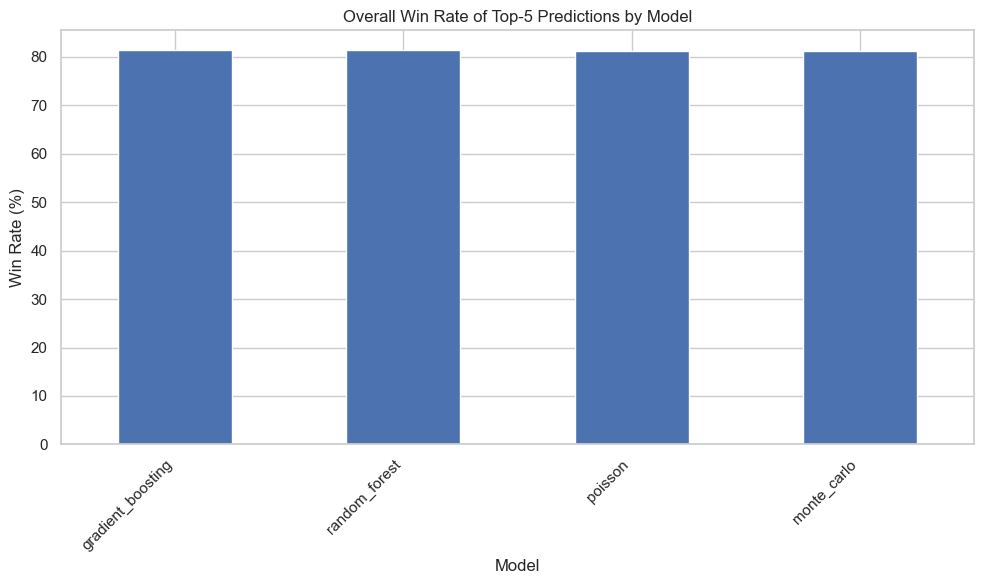


Win Rate (%) by Prediction Rank (within Top 5) by Model:
Rank                       1          2          3          4          5
Model                                                                   
gradient_boosting  92.995570  86.722296  78.193036  75.658902  73.416506
monte_carlo        93.078923  86.320024  78.138675  75.659808  72.638236
poisson            93.111540  86.298279  78.143205  75.845542  72.529514
random_forest      93.078923  86.549247  78.164044  75.459578  73.480833


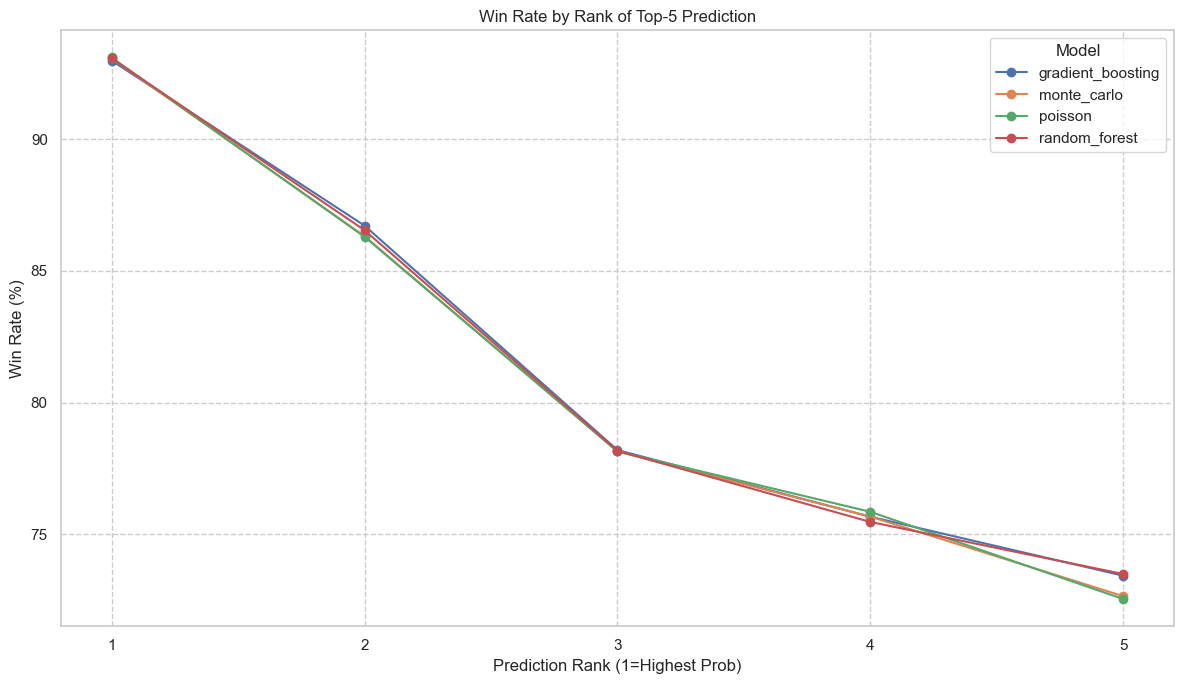


Top 15 Most Frequent *Winning* Markets in Top N Predictions (Overall):
PredictedMarket
O05             410560
U45             364992
12              333288
O15             285931
U35             178706
1X              155795
X2               50880
H                 7346
A                 2674
O25               1782
BTTS_Y            1489
goals_3_plus       361
U25                290


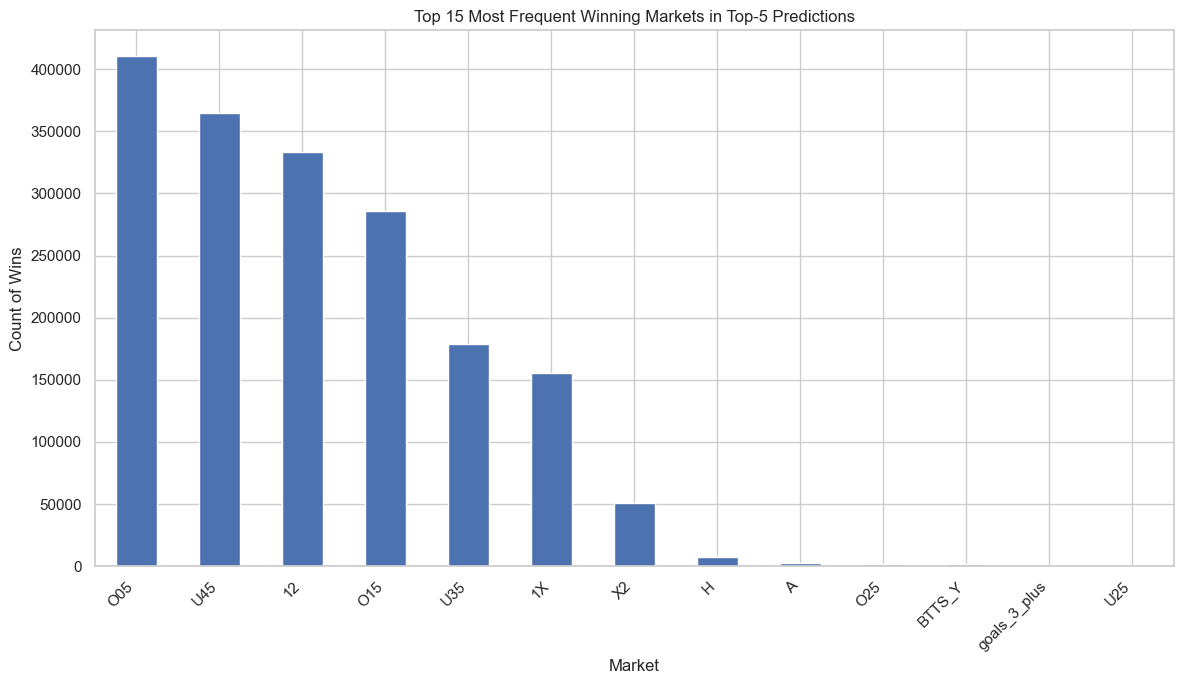


Top 15 Markets with Highest Win Rate (%) in Top N Predictions (min 2207 occurrences):
PredictedMarket
O05       92.993758
U45       85.528095
H         80.004356
A         79.347181
1X        78.544708
O15       76.807837
X2        76.494024
12        75.542621
U35       73.779297
O25       67.628083
BTTS_Y    60.454730


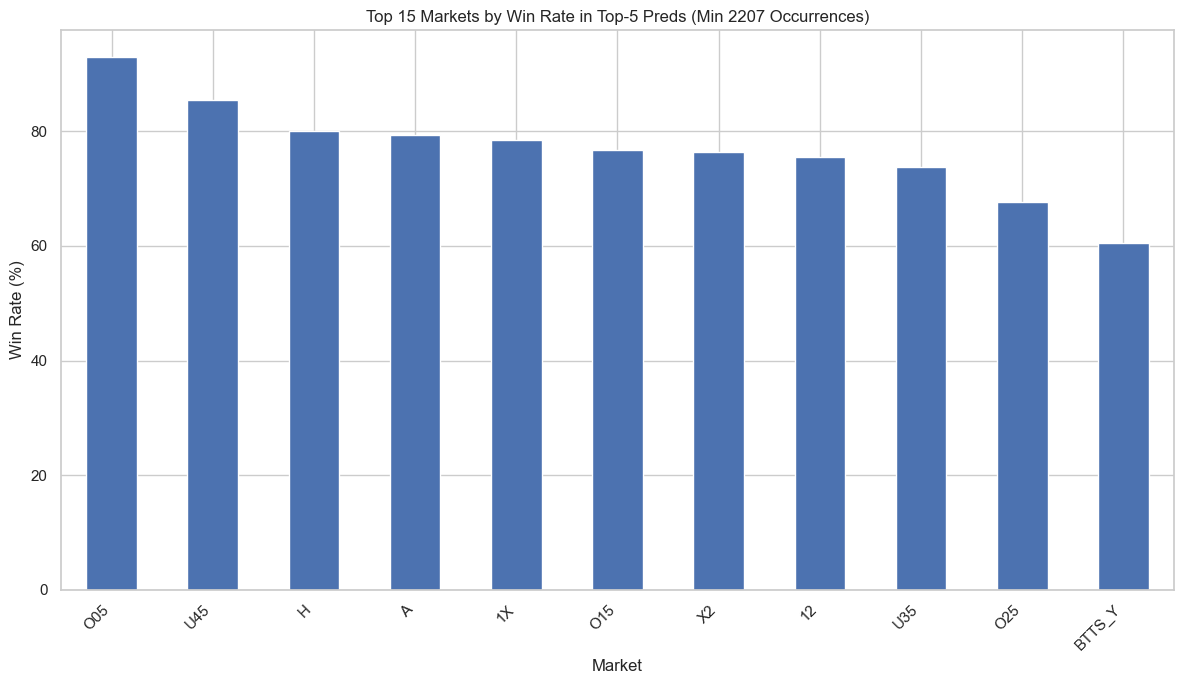

Top N Prediction Performance Analysis section complete.


In [34]:
# ==============================================================================
# --- Section X: Top N Prediction Performance Analysis ---
# ==============================================================================
print("\n--- Section X: Top N Prediction Performance Analysis ---")
print("Purpose: Analyze the win rate of the Top N highest probability predictions per game, per model.")

# --- Configuration for Top N Analysis ---
N_TOP_PREDS = 5 # Analyze top 5 predictions
MIN_PROB_THRESHOLD = 0.01 # Optional: Ignore predictions below this threshold

# Define all unique market suffixes
all_market_suffixes = sorted(list(set([key.replace('prob_', '') for key in CORE_PROBABILITY_KEYS])))
print(f"Analyzing across {len(all_market_suffixes)} unique market suffixes for Top-N predictions.")

top_n_results_list = [] # Initialize list to store results

# Check if df_errors exists from previous sections
if 'df_errors' not in locals() or df_errors.empty:
    print("ERROR: df_errors DataFrame not found or is empty. Please ensure previous sections (0-6) have been run.")
    # You might want to stop execution here if df_errors is critical and missing
    raise NameError("df_errors is not defined. Halting Top N analysis.")
else:
    print(f"Using df_errors with shape: {df_errors.shape} for Top N analysis.")

for model_name in model_keys:
    print(f"\nProcessing Top-{N_TOP_PREDS} predictions for model: {model_name}")
    
    for match_id, game_row in df_errors.iterrows():
        game_predictions_for_model = []
        
        for market_suffix in all_market_suffixes:
            pred_col = f"{model_name}_prob_{market_suffix}"
            actual_col = f"Actual_{market_suffix}"
            
            if pred_col in game_row and actual_col in game_row and pd.notna(game_row[pred_col]):
                prob = game_row[pred_col]
                if prob >= MIN_PROB_THRESHOLD:
                    actual = game_row[actual_col]
                    game_predictions_for_model.append({
                        'prob': prob, 
                        'market_suffix': market_suffix, 
                        'actual_outcome': int(actual),
                        'pred_col_name': pred_col,
                        'match_id': match_id 
                    })
        
        if not game_predictions_for_model:
            continue
            
        game_predictions_for_model.sort(key=lambda x: x['prob'], reverse=True)
        top_n_for_this_game = game_predictions_for_model[:N_TOP_PREDS]
        
        for rank, top_pred_data in enumerate(top_n_for_this_game):
            top_n_results_list.append({
                'MatchID': match_id,
                'Model': model_name,
                'PredictedMarket': top_pred_data['market_suffix'],
                'PredictedProb': top_pred_data['prob'],
                'ActualOutcome': top_pred_data['actual_outcome'],
                'IsCorrect': 1 if top_pred_data['actual_outcome'] == 1 else 0,
                'Rank': rank + 1
            })

# Create DataFrame from the results
df_top_n_analysis = pd.DataFrame(top_n_results_list)

if df_top_n_analysis.empty:
    print("WARNING: No Top-N prediction data was generated. Check input data, model predictions, and thresholds.")
else:
    print(f"\n--- Top-{N_TOP_PREDS} Prediction Analysis Summary ---")
    print(f"Total Top-{N_TOP_PREDS} predictions considered: {len(df_top_n_analysis)}")

    # 1. Overall Win Rate by Model
    overall_win_rate_model = df_top_n_analysis.groupby('Model')['IsCorrect'].mean().mul(100).sort_values(ascending=False)
    print("\nOverall Win Rate (%) by Model (for their Top N predictions):")
    print(overall_win_rate_model.to_string())
    if not overall_win_rate_model.empty:
        plt.figure(figsize=(10, 6))
        overall_win_rate_model.plot(kind='bar')
        plt.title(f'Overall Win Rate of Top-{N_TOP_PREDS} Predictions by Model')
        plt.ylabel('Win Rate (%)')
        plt.xlabel('Model')
        plt.xticks(rotation=45, ha="right")
        plt.tight_layout()
        plt.show()

    # 2. Win Rate by Prediction Rank by Model
    win_rate_by_rank_model = df_top_n_analysis.groupby(['Model', 'Rank'])['IsCorrect'].mean().unstack().mul(100)
    print(f"\nWin Rate (%) by Prediction Rank (within Top {N_TOP_PREDS}) by Model:")
    print(win_rate_by_rank_model.to_string())
    if not win_rate_by_rank_model.empty:
        win_rate_by_rank_model.T.plot(kind='line', marker='o', figsize=(12,7))
        plt.title(f'Win Rate by Rank of Top-{N_TOP_PREDS} Prediction')
        plt.ylabel('Win Rate (%)')
        plt.xlabel('Prediction Rank (1=Highest Prob)')
        plt.xticks(ticks=range(1, N_TOP_PREDS + 1))
        plt.legend(title='Model')
        plt.grid(True, which='both', linestyle='--')
        plt.tight_layout()
        plt.show()

    # 3. Most Frequent Winning Markets in Top N
    winning_top_n_markets = df_top_n_analysis[df_top_n_analysis['IsCorrect'] == 1]['PredictedMarket'].value_counts().nlargest(15)
    print("\nTop 15 Most Frequent *Winning* Markets in Top N Predictions (Overall):")
    print(winning_top_n_markets.to_string())
    if not winning_top_n_markets.empty:
        plt.figure(figsize=(12, 7))
        winning_top_n_markets.plot(kind='bar')
        plt.title(f'Top 15 Most Frequent Winning Markets in Top-{N_TOP_PREDS} Predictions')
        plt.ylabel('Count of Wins')
        plt.xlabel('Market')
        plt.xticks(rotation=45, ha="right")
        plt.tight_layout()
        plt.show()
    
    # 4. Markets with Highest Win Rate in Top N (min N occurrences)
    MIN_OCCURRENCES_FOR_WIN_RATE = max(50, int(len(df_top_n_analysis) * 0.001)) # Dynamic threshold
    market_counts_in_top_n = df_top_n_analysis['PredictedMarket'].value_counts()
    markets_to_analyze_for_win_rate = market_counts_in_top_n[market_counts_in_top_n >= MIN_OCCURRENCES_FOR_WIN_RATE].index
    
    if len(markets_to_analyze_for_win_rate) > 0:
        highest_win_rate_markets = df_top_n_analysis[df_top_n_analysis['PredictedMarket'].isin(markets_to_analyze_for_win_rate)]\
                                    .groupby('PredictedMarket')['IsCorrect'].mean().mul(100).sort_values(ascending=False).nlargest(15)
        print(f"\nTop 15 Markets with Highest Win Rate (%) in Top N Predictions (min {MIN_OCCURRENCES_FOR_WIN_RATE} occurrences):")
        print(highest_win_rate_markets.to_string())
        if not highest_win_rate_markets.empty:
            plt.figure(figsize=(12, 7))
            highest_win_rate_markets.plot(kind='bar')
            plt.title(f'Top 15 Markets by Win Rate in Top-{N_TOP_PREDS} Preds (Min {MIN_OCCURRENCES_FOR_WIN_RATE} Occurrences)')
            plt.ylabel('Win Rate (%)')
            plt.xlabel('Market')
            plt.xticks(rotation=45, ha="right")
            plt.tight_layout()
            plt.show()
    else:
        print(f"No markets met the minimum occurrence threshold ({MIN_OCCURRENCES_FOR_WIN_RATE}) for win rate analysis.")

print("Top N Prediction Performance Analysis section complete.")


--- Section Y: Parlay Exploration from Agreed Top Selections (Stricter O/U Filtering & Leg Frequency) ---
Purpose: Explore win rates of simple parlays formed from selections where multiple models agree,
         excluding ALL standalone Over/Under markets as parlay legs,
         and analyze the frequency of markets used in these parlays.
Using df_top_n_analysis (shape: (2207460, 7)) for Parlay Exploration.

Processing parlays: Top-5 preds, Min 2 models agree, Parlay sizes: [2, 3, 4].
Filtering out ALL standalone Over/Under markets from parlay leg consideration.

--- Parlay Analysis Summary (Strict O/U Filter, Agreed Top-5 Selections) ---
Total parlays considered: 88135

  2-Leg Parlays:
    Win Rate: 56.62%
    Count: 82925

  3-Leg Parlays:
    Win Rate: 63.01%
    Count: 5085

  4-Leg Parlays:
    Win Rate: 6.40%
    Count: 125


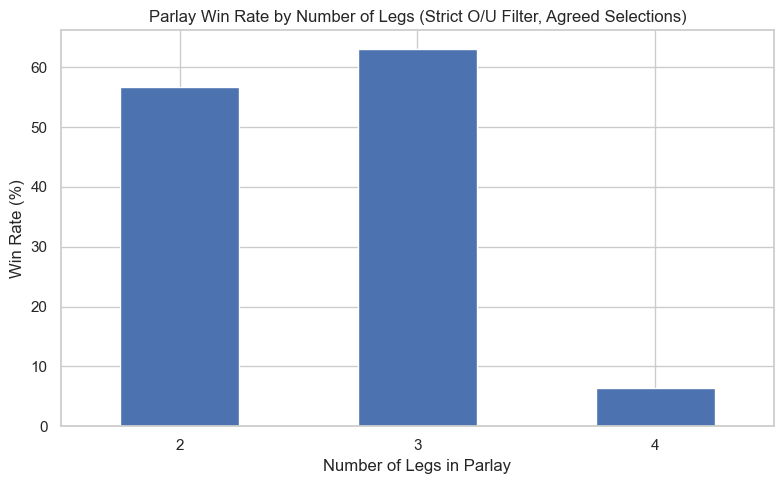


--- Frequency of Individual Markets Used as Parlay Legs (Strict O/U Filter) ---

Top 20 Most Frequently Used Markets as Parlay Legs (Strict O/U Filter):
12              83050
1X              61716
X2              23550
H                8103
A                3922
BTTS_Y           1003
goals_3_plus      261


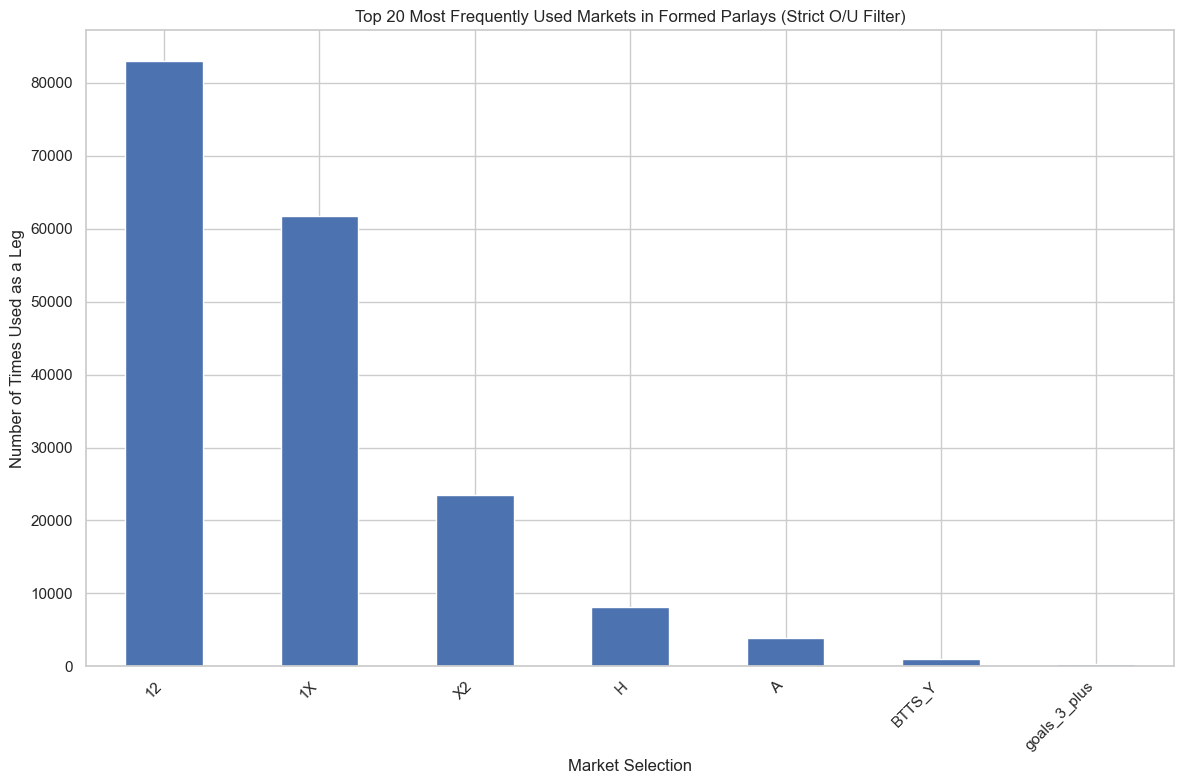

Parlay Exploration section (with strict O/U filtering and leg frequency analysis) complete.


In [39]:
# ==============================================================================
# --- Section Y: Parlay Exploration from Agreed Top Selections (Stricter O/U Filtering & Leg Frequency) ---
# ==============================================================================
print("\n--- Section Y: Parlay Exploration from Agreed Top Selections (Stricter O/U Filtering & Leg Frequency) ---")
print("Purpose: Explore win rates of simple parlays formed from selections where multiple models agree,")
print("         excluding ALL standalone Over/Under markets as parlay legs,")
print("         and analyze the frequency of markets used in these parlays.")

# --- Configuration for Parlay Analysis ---
N_TOP_PREDS_PARLAY = 5   # Consider top N predictions from each model for finding agreement
MIN_MODELS_AGREE = 2     # At least this many models must agree on a selection
PARLAY_SIZES_TO_TEST = [2, 3, 4] # Test 2, 3, and 4-leg parlays

# Import combinations if not already imported
from itertools import combinations 
import re # For pattern matching market names

# Check if df_top_n_analysis exists from the previous section
if 'df_top_n_analysis' not in locals() or df_top_n_analysis.empty:
    print("ERROR: df_top_n_analysis DataFrame not found or is empty. ")
    print("Please ensure 'Section X: Top N Prediction Performance Analysis' has been run successfully before this cell.")
    raise NameError("df_top_n_analysis is not defined. Halting Parlay analysis.")
else:
    print(f"Using df_top_n_analysis (shape: {df_top_n_analysis.shape}) for Parlay Exploration.")
    df_parlay_base = df_top_n_analysis[df_top_n_analysis['Rank'] <= N_TOP_PREDS_PARLAY].copy()
    
    if df_parlay_base.empty:
        print(f"WARNING: df_parlay_base is empty after filtering for Rank <= {N_TOP_PREDS_PARLAY}. No parlays can be formed.")
        df_parlay_analysis = pd.DataFrame() 
    else:
        parlay_results_list = []
        print(f"\nProcessing parlays: Top-{N_TOP_PREDS_PARLAY} preds, Min {MIN_MODELS_AGREE} models agree, Parlay sizes: {PARLAY_SIZES_TO_TEST}.")
        print("Filtering out ALL standalone Over/Under markets from parlay leg consideration.")

        # Updated helper function to identify ANY standalone O/U market
        def is_standalone_ou_market_strict(market_suffix: str) -> bool:
            # Matches 'O' or 'U' followed by two digits (e.g., O05, U15, O25, U35, U45)
            # AND ensures it's not part of a combined market (i.e., no '_and_' in the suffix)
            # This pattern assumes market_suffix itself is the simple part, not a combined one.
            # If market_suffix can be "O25_and_BTTS_Y", this logic is fine as it won't match.
            pattern = r"^(O|U)\d{2}$" 
            if re.fullmatch(pattern, market_suffix):
                return True
            return False
        
        # Test the helper (optional)
        # print(f"Is 'O25' standalone O/U (strict)? {is_standalone_ou_market_strict('O25')}") # True
        # print(f"Is 'U45' standalone O/U (strict)? {is_standalone_ou_market_strict('U45')}") # True
        # print(f"Is 'H_and_O25' standalone O/U (strict)? {is_standalone_ou_market_strict('H_and_O25')}") # False
        # print(f"Is 'BTTS_Y' standalone O/U (strict)? {is_standalone_ou_market_strict('BTTS_Y')}") # False

        for match_id, game_group in df_parlay_base.groupby('MatchID'):
            # Apply the stricter O/U filter
            eligible_market_rows = game_group[~game_group['PredictedMarket'].apply(is_standalone_ou_market_strict)]
            
            if eligible_market_rows.empty:
                continue

            market_agreement_counts = eligible_market_rows['PredictedMarket'].value_counts()
            agreed_markets_for_game = market_agreement_counts[market_agreement_counts >= MIN_MODELS_AGREE].index.tolist()

            if not agreed_markets_for_game:
                continue

            agreed_selections_details = []
            for market_suffix in agreed_markets_for_game:
                market_rows = eligible_market_rows[eligible_market_rows['PredictedMarket'] == market_suffix]
                if market_rows.empty: continue

                actual_outcome = market_rows['ActualOutcome'].iloc[0] 
                avg_prob = market_rows['PredictedProb'].mean()
                
                agreed_selections_details.append({
                    'match_id': match_id,
                    'market_suffix': market_suffix,
                    'actual_outcome': actual_outcome,
                    'avg_prob_agreement': avg_prob,
                    'num_models_agreed': market_agreement_counts[market_suffix]
                })
            
            if len(agreed_selections_details) < min(PARLAY_SIZES_TO_TEST if PARLAY_SIZES_TO_TEST else [float('inf')]):
                continue

            for parlay_size in PARLAY_SIZES_TO_TEST:
                if len(agreed_selections_details) >= parlay_size:
                    for parlay_legs_tuple in combinations(agreed_selections_details, parlay_size):
                        parlay_legs = list(parlay_legs_tuple)
                        is_parlay_win = all(leg['actual_outcome'] == 1 for leg in parlay_legs)
                        
                        combined_avg_prob = 1.0
                        leg_details_str_list = []
                        for leg in parlay_legs:
                            combined_avg_prob *= leg['avg_prob_agreement']
                            leg_details_str_list.append(f"{leg['market_suffix']}(Act:{leg['actual_outcome']},AvgP:{leg['avg_prob_agreement']:.2f})")
                        
                        parlay_results_list.append({
                            'MatchID': match_id,
                            'ParlaySize': parlay_size,
                            'IsWin': 1 if is_parlay_win else 0,
                            'Legs': " | ".join(leg_details_str_list),
                            'CombinedAvgProb': combined_avg_prob,
                            'NumLegsInParlay': len(parlay_legs)
                        })
        
        df_parlay_analysis = pd.DataFrame(parlay_results_list)

# --- Analysis of Parlay Results ---
if 'df_parlay_analysis' not in locals() or df_parlay_analysis.empty:
    print("\nWARNING: No parlay data was generated based on current agreement criteria or an error occurred earlier.")
    print("Skipping parlay summary and leg frequency analysis.")
else:
    print(f"\n--- Parlay Analysis Summary (Strict O/U Filter, Agreed Top-{N_TOP_PREDS_PARLAY} Selections) ---")
    print(f"Total parlays considered: {len(df_parlay_analysis)}")

    # 1. Parlay Win Rate by Size
    for p_size in PARLAY_SIZES_TO_TEST:
        df_subset = df_parlay_analysis[df_parlay_analysis['ParlaySize'] == p_size]
        if not df_subset.empty:
            win_rate = df_subset['IsWin'].mean() * 100
            count = len(df_subset)
            print(f"\n  {p_size}-Leg Parlays:")
            print(f"    Win Rate: {win_rate:.2f}%")
            print(f"    Count: {count}")
        else:
            print(f"\n  No {p_size}-Leg Parlays generated with current agreement criteria.")
            
    parlay_summary_plot_data = df_parlay_analysis.groupby('ParlaySize')['IsWin'].mean().mul(100)
    if not parlay_summary_plot_data.empty:
        plt.figure(figsize=(8,5))
        parlay_summary_plot_data.plot(kind='bar')
        plt.title(f'Parlay Win Rate by Number of Legs (Strict O/U Filter, Agreed Selections)')
        plt.ylabel('Win Rate (%)')
        plt.xlabel('Number of Legs in Parlay')
        plt.xticks(rotation=0)
        plt.tight_layout()
        plt.show()
    else:
        print("No data to plot for parlay win rate summary by size.")

    # 2. Frequency of Individual Markets Used as Parlay Legs
    print("\n--- Frequency of Individual Markets Used as Parlay Legs (Strict O/U Filter) ---")
    
    all_legs_list = []
    for legs_string in df_parlay_analysis['Legs']:
        individual_leg_strings = legs_string.split(' | ')
        for leg_str in individual_leg_strings:
            market_suffix_match = re.match(r"([^(]+)", leg_str)
            if market_suffix_match:
                all_legs_list.append(market_suffix_match.group(1).strip())
    
    if not all_legs_list:
        print("Could not parse any individual legs from the formed parlays.")
    else:
        leg_counts = pd.Series(all_legs_list).value_counts().nlargest(20)
        
        print("\nTop 20 Most Frequently Used Markets as Parlay Legs (Strict O/U Filter):")
        print(leg_counts.to_string())
        
        if not leg_counts.empty:
            plt.figure(figsize=(12, 8))
            leg_counts.plot(kind='bar')
            plt.title('Top 20 Most Frequently Used Markets in Formed Parlays (Strict O/U Filter)')
            plt.ylabel('Number of Times Used as a Leg')
            plt.xlabel('Market Selection')
            plt.xticks(rotation=45, ha="right")
            plt.tight_layout()
            plt.show()
        else:
            print("No leg count data to plot.")

print("Parlay Exploration section (with strict O/U filtering and leg frequency analysis) complete.")